In [1]:
dt = 60*2
ry = 1000
total_seconds = 248 * ry * 86400
mmax = total_seconds / dt
myear = mmax // ry
mout =  558*2 #int(0.775 * 86400 / dt )
msize = mmax // mout
#mout = int(0.1*86400 / dt)




print(myear, mout, msize,mmax,myear/992)



178560.0 1116 160000.0 178560000.0 180.0


In [2]:
from matplotlib import cm
from netCDF4 import Dataset 
import numpy as np 
import math
import scipy.stats as stats 
import matplotlib.pyplot as plot
from matplotlib.pyplot import MultipleLocator
from scipy import signal
# import seaborn
import seaborn as sns
import datetime
import calendar
from sklearn import preprocessing

In [3]:
#-----------------
# read netCDF files
#-----------------

#filename1 = 'ur60n10hPa.nc'
#filename2 = 'ub60n10hPa.nc'
filename1 = '/scratch/smliu01/1d_model/archive/ur60n10hPa.nc'
filename2 = '/scratch/smliu01/1d_model/archive/ub60n10hPa.nc'

ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
ncin2 = Dataset(filename2, 'r', format='NETCDF4')

uref = ncin1.variables['uref'] 
uref = (np.array(uref))
ubar = ncin2.variables['ubar'] 
ubar = (np.array(ubar))
print(uref.shape)
print(ubar.shape)

i=0
urp = np.zeros((42,992))
ubp = np.zeros((42,992))
days = np.zeros(8)
dddd = np.zeros((42,992))
date = dddd.tolist()

month = [9,10,11,0,1,2,3,4]

time = ['00','06','12','18']
months = ['10','11','12','01','02','03','04','05']
dates = ['01','02','03','04','05','06','07','08','09','10',   \
         '11','12','13','14','15','16','17','18','19',        \
        '20','21','22','23','24','25','26','27','28','29','30','31']

while(i<42):
    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if uref[j,month[m],i]!=0:
                    urp[i,k] = uref[j,month[m],i]
                    date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            else:
                if uref[j,month[m],i+1]!=0:
                    urp[i,k] = uref[j,month[m],i+1]
                    date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #urp[urp==0]=np.nan


    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if ubar[j,month[m],i]!=0:
                    ubp[i,k] = ubar[j,month[m],i]
                    k=k+1
            else:
                if ubar[j,month[m],i+1]!=0:
                    ubp[i,k] = ubar[j,month[m],i+1]
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #ubp[ubp==0]=np.nan

    i=i+1


print(ubp.shape)

#-----------------
# read netCDF files
#-----------------

#filename1 = 'ur60n10hPa.nc'
#filename2 = 'ub60n10hPa.nc'
filename1 = '/scratch/smliu01/1d_model/archive/tr60n10hPa.nc'
filename2 = '/scratch/smliu01/1d_model/archive/tb60n10hPa.nc'

ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
ncin2 = Dataset(filename2, 'r', format='NETCDF4')

tref = ncin1.variables['tref'] 
tref = (np.array(tref))
tbar = ncin2.variables['tbar'] 
tbar = (np.array(tbar))
print(tref.shape)
print(tbar.shape)

i=0
trp = np.zeros((42,992))
tbp = np.zeros((42,992))
days = np.zeros(8)
dddd = np.zeros((42,992))
date = dddd.tolist()

month = [9,10,11,0,1,2,3,4]

time = ['00','06','12','18']
months = ['10','11','12','01','02','03','04','05']
dates = ['01','02','03','04','05','06','07','08','09','10',   \
         '11','12','13','14','15','16','17','18','19',        \
        '20','21','22','23','24','25','26','27','28','29','30','31']

while(i<42):
    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if tref[j,month[m],i]!=0:
                    trp[i,k] = tref[j,month[m],i]
                    date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            else:
                if tref[j,month[m],i+1]!=0:
                    trp[i,k] = tref[j,month[m],i+1]
                    date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #urp[urp==0]=np.nan


    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if tbar[j,month[m],i]!=0:
                    tbp[i,k] = tbar[j,month[m],i]
                    k=k+1
            else:
                if tbar[j,month[m],i+1]!=0:
                    tbp[i,k] = tbar[j,month[m],i+1]
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #ubp[ubp==0]=np.nan

    i=i+1


print(tbp.shape)


dmax = 716

ueast = np.zeros((42,dmax))
ratiosl = np.zeros((42,dmax))

onset = np.zeros((42,dmax))
ronset = np.zeros((42,dmax))

onset_id = np.zeros(200)
ronset_id = np.zeros(210)

end = np.zeros((42,dmax))
rend = np.zeros((42,dmax))

end_id = np.zeros(200)
rend_id = np.zeros(210)

ssw = np.zeros((42,dmax))
rssw = np.zeros((42,dmax))

fponset_id = np.zeros(210)

ratio = 0.3

######################################### find out the onset date #######################################

i = 0
while(i < 42):
    j = 0
    while(j < dmax):
        if ubp[i,j] < 0:
            ueast[i,j] = 1 
        if ubp[i,j]/urp[i,j] < ratio:
            ratiosl[i,j] = 1
        j=j+1
    i=i+1

i = 0
n = 0
nn = 0
m = 0
mm = 0
t = 1
while(i < 42):
    j = 1
    while(j < dmax):
        if ubp[i,j] < 0 and ueast[i,j-1] == 0:
            onset[i,j] = 1
            onset_id[n] = t
            n=n+1
            #print(date[i][j])
        elif ubp[i,j] > 0 and ueast[i,j-1] == 1:
            end[i,j] = 1
            end_id[m] = t
            m=m+1
        elif j == dmax-1:
            if ueast[i,j] == 1:
                end[i,j] = 1
                end_id[m] = t
                m=m+1
        if ubp[i,j]/urp[i,j] < ratio and ratiosl[i,j-1] == 0: 
            ronset[i,j] = 1
            ronset_id[nn] = t
            nn=nn+1
        elif ubp[i,j]/urp[i,j] > ratio and ratiosl[i,j-1] == 1: 
            rend[i,j] = 1
            rend_id[mm] = t
            mm=mm+1
        elif j == dmax-1:
            if ratiosl[i,j] == 1:
                rend[i,j] = 1
                rend_id[mm] = t
                mm=mm+1
        t=t+1
        j=j+1
    i=i+1


######################################### exclude some events #######################################

n = 1
while(n<210):
    if rend_id[n]-ronset_id[n]<2*4:
        ronset_id[n]=0
        rend_id[n]=0        
    n=n+1


#the interval of the start of an event and the end of the last event should be larger than 10 days
n = 1
while(n<200):
    if (onset_id[n]-end_id[n-1])<10*4:
        onset_id[n]=0
        end_id[n]=0
    n=n+1 
n = 2
while(n<200):
    if (onset_id[n]-end_id[n-2])<10*4:
        onset_id[n]=0
        end_id[n]=0
    n=n+1

n = 1
while(n<210):
    if (ronset_id[n]-rend_id[n-1])<10*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1 
n = 2
while(n<210):
    if (ronset_id[n]-rend_id[n-2])<10*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1

#there shouldn't be a new event shorter than 20 days
n = 1
while(n<200):
    if onset_id[n]-onset_id[n-1]<20*4:
        onset_id[n]=0
        end_id[n]=0
    n=n+1

n = 3
while(n<210):
    if ronset_id[n]-ronset_id[n-3]<20*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1

n = 2
while(n<210):
    if ronset_id[n]-ronset_id[n-2]<20*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1
    
n = 1
while(n<210):
    if ronset_id[n]-ronset_id[n-1]<20*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1  

#the event lasts till the end should be excluded
n = 1
while(n<200):
    if end_id[n]%(dmax-1)==0:
        onset_id[n]=0
        end_id[n]=0        
    n=n+1

n = 1
while(n<210):
    if rend_id[n]%(dmax-1)==0:
        ronset_id[n]=0
        rend_id[n]=0        
    n=n+1

#an event should at least be longer than 2 days
n = 1
while(n<200):
    if end_id[n]-onset_id[n]<2*4:
        onset_id[n]=0
        end_id[n]=0        
    n=n+1


#exclude 3 events
n = 1
while(n<200):
    if onset_id[n]==6380 or onset_id[n]==18525 or onset_id[n]==22145:
        onset_id[n]=0
        end_id[n]=0        
    n=n+1

    
fp=0
tp=0
fn=0
fpb=0

######################################### print out the date #######################################

barplot = np.zeros(6)

i = 0
n = 0
c = 0
while(i < 42):
    j = 1
    while(j < dmax):
        if onset[i,j] == 1:      #ubar<0
            if onset_id[n] == 0: #ubar<0 but there's no SSW
                True
            else:                #there is an SSW
                # print(date[i][j])
                
                if date[i][j][5:7] == '11':
                    barplot[0] = barplot[0]+1
                elif date[i][j][5:7] == '12':
                    barplot[1] = barplot[1]+1
                elif date[i][j][5:7] == '01':
                    barplot[2] = barplot[2]+1
                elif date[i][j][5:7] == '02':
                    barplot[3] = barplot[3]+1                    
                elif date[i][j][5:7] == '03':
                    barplot[4] = barplot[4]+1                     
                elif date[i][j][5:7] == '04':
                    barplot[5] = barplot[5]+1                     
                
                if ubp[i,j-2]/urp[i,j-2] < ratio: #find out true positive
                    tp=tp+1
#                if ubp[i,j]/urp[i,j] > ratio: #find out false negative
#                    fn=fn+1                
                c=c+1            #how many SSWs
            n=n+1                #the size of onset_id        
        j=j+1
    i=i+1

print('####################################')

i = 0
nn = 0
cc = 0
while(i < 42):
    j = 1
    while(j < dmax): 
        if ronset[i,j] == 1:      #ubar/uref<0.3
            if ronset_id[nn] == 0: #ubar/uref<0.3 but there's no SSW
                True
            else:
                #print(date[i][j])
                cc=cc+1            #how many rSSWs
            nn=nn+1                #the size of onset_id       
        j=j+1
    i=i+1


    
######################################### mark each day of ssw #######################################
i = 0
n = 0
nn = 0
t = 1
while(i < 42):
    j = 1
    while(j < dmax):       
        if t>=onset_id[n] and t<=end_id[n]:
            ssw[i,j] = 1
        if end[i,j]==1:
            n=n+1                #the size of onset_id   
        if t>=ronset_id[nn] and t<=rend_id[nn]:
            rssw[i,j] = 1
        if rend[i,j]==1:
            nn=nn+1                #the size of onset_id  
        t=t+1
        j=j+1
    i=i+1
    
print('####################################')
######################################### find out false positive #######################################
nn = 0
fponset_id=ronset_id
while(nn < 210):
    n = 0
    while(n < 200):
        if onset_id[n]>ronset_id[nn] and onset_id[n]<rend_id[nn]: #exclude onset happen between <0.3 start and end
            fponset_id[nn]=0
        elif abs(onset_id[n]-ronset_id[nn])<40: #exclude 0.3 and onset too far way
            fponset_id[nn]=0
        n=n+1
    nn=nn+1

i = 0
n = 0
nn = 0
t = 1
while(i < 42):
    j = 1
    while(j < dmax): 
        if ronset[i,j] == 1: 
            if fponset_id[nn] != 0:      #ubar/uref<0.3
                fp=fp+1
                if ubp[i,j+5]<ubp[i,j]:
                    fpb=fpb+1
            nn=nn+1
        j=j+1
    i=i+1


print('true positive:'+str(tp))
print('total ssws amount:'+str(c))
print('false positive:'+str(fp))
print('false positive but vortex decreasing:'+str(fpb))




height = np.zeros(97)
plev = np.zeros(97)
h1d = np.zeros(381)
dz = 500.
hh = 7000.
dz1d = 100
for k in range(97):
    height[k] = k*dz
    plev[k] = 1000*np.exp(-height[k]/hh)
for k in range(381):
    h1d[k] = dz1d*k+10000.

print(height[96])
print(h1d[0])

filename1 = '/nas/winds-home/smliu01/3.era-5,ssw_1.2022/ana60n.nc'
ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
epz = ncin1.variables['epz'] 
epz = (np.array(epz))
fawa = ncin1.variables['fawa'] 
fawa = (np.array(fawa))
ubar = ncin1.variables['ubar'] 
ubar = (np.array(ubar))
uref = ncin1.variables['uref'] 
uref = (np.array(uref))


filename1 = '/nas/winds-home/smliu01/3.era-5,ssw_1.2022/tran60n.nc'
ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
epz_tran = ncin1.variables['epz'] 
epz_tran = (np.array(epz_tran))
fawa_tran = ncin1.variables['fawa'] 
fawa_tran = (np.array(fawa_tran))
ubar_tran = ncin1.variables['ubar'] 
ubar_tran = (np.array(ubar_tran))
uref_tran = ncin1.variables['uref'] 
uref_tran = (np.array(uref_tran))
print(epz.shape)

file = '/nas/winds-home/smliu01/3.era-5,ssw_1.2022/sea60n.nc'
ncin1 = Dataset(file, 'r', format='NETCDF4') 
fawa_sea = ncin1.variables['fawa'] 
fawa_sea = (np.array(fawa_sea))
ubar_sea = ncin1.variables['ubar'] 
ubar_sea = (np.array(ubar_sea))
uref_sea = ncin1.variables['uref']
uref_sea = (np.array(uref_sea))
epz_sea = ncin1.variables['epz'] 
epz_sea = (np.array(epz_sea))
print(fawa_sea.shape)

fawa_sea_n = np.zeros((97, 124, 12, 43))
ubar_sea_n = np.zeros((97, 124, 12, 43))
uref_sea_n = np.zeros((97, 124, 12, 43))
epz_sea_n = np.zeros((97, 124, 12, 43))

for i in range(43):
    fawa_sea_n[:,:,:,i] = fawa_sea[:,:,:]
    ubar_sea_n[:,:,:,i] = ubar_sea[:,:,:]
    uref_sea_n[:,:,:,i] = uref_sea[:,:,:]
    epz_sea_n[:,:,:,i] = epz_sea[:,:,:]


def Oct_to_May(vv):

    i=0
    vbar = np.zeros((97,42,992))
    days = np.zeros(8)
    dddd = np.zeros((42,992))
    date = dddd.tolist()

    month = [9,10,11,0,1,2,3,4]

    time = ['00','06','12','18']
    months = ['10','11','12','01','02','03','04','05']
    dates = ['01','02','03','04','05','06','07','08','09','10',   \
             '11','12','13','14','15','16','17','18','19',        \
            '20','21','22','23','24','25','26','27','28','29','30','31']

    for z in range(97):
        i=0
        while(i<42):
            m=0
            k=0
            while(m<8):
                j=0
                while(j<124):
                    if m<3:
                        if vv[z,j,month[m],i]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i]
                            date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    else:
                        if vv[z,j,month[m],i+1]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i+1]
                            date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    j=j+1
                days[m]=k
                m=m+1
            vbar[vbar==0]=np.nan

            i=i+1

    return vbar

def Nov_to_Mar(vv):

    i=0
    vbar = np.zeros((97,42,604))
    days = np.zeros(5)
    dddd = np.zeros((42,604))
    date = dddd.tolist()

    month = [10,11,0,1,2]

    time = ['00','06','12','18']
    months = ['11','12','01','02','03']
    dates = ['01','02','03','04','05','06','07','08','09','10',   \
             '11','12','13','14','15','16','17','18','19',        \
            '20','21','22','23','24','25','26','27','28','29','30','31']

    for z in range(97):
        i=0
        while(i<42):
            m=0
            k=0
            while(m<5):
                j=0
                while(j<124):
                    if m<2:
                        if vv[z,j,month[m],i]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i]
                            date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    else:
                        if vv[z,j,month[m],i+1]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i+1]
                            date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    j=j+1
                days[m]=k
                m=m+1
            vbar[vbar==0]=np.nan

            i=i+1

    return vbar

def sixty_to_sixty(onset_id,dmax,vbar):

    yy=0

    vb = np.zeros((97,22,121*4))

    i=0
    while(i<42):
        for n in range(onset_id.shape[0]):
            if onset_id[n]!=0:
                if int((onset_id[n]+(dmax-1))/(dmax-1))-1==i:
                    kk = onset_id[n]-(dmax-1)*i
                    #print(n,kk)
                    for k in range(int(kk-60*4),int(kk+61*4)):
                        z=0
                        while(z<97):
                            x = int(abs(k-kk+60*4))
                            #print(x)
                            vb[z,yy,x] = vbar[z,i,k]  #################################
                            z=z+1
                    yy = yy+1
        i=i+1
        
    return vb

uref_eachyr = Oct_to_May(uref)
ubar_eachyr = Oct_to_May(ubar)
fawa_eachyr = Oct_to_May(fawa)
epz_eachyr = Oct_to_May(epz)


print('done')




(124, 12, 43)
(124, 12, 43)
(42, 992)
(124, 12, 43)
(124, 12, 43)
(42, 992)
####################################
####################################
true positive:22
total ssws amount:22
false positive:44
false positive but vortex decreasing:39
48000.0
10000.0
(97, 124, 12, 43)
(97, 124, 12)


done


/tmp/ipykernel_3248528/246794205.py:20: RuntimeWarning: Mean of empty slice
  ubar_era_full = np.nanmean(ubar_eachyr, axis=1)[:, era_t_start:era_t_end]
/tmp/ipykernel_3248528/246794205.py:21: RuntimeWarning: Mean of empty slice
  uref_era_full = np.nanmean(uref_eachyr, axis=1)[:, era_t_start:era_t_end]
/tmp/ipykernel_3248528/246794205.py:22: RuntimeWarning: Mean of empty slice
  a_era_full    = np.nanmean(fawa_eachyr, axis=1)[:, era_t_start:era_t_end]


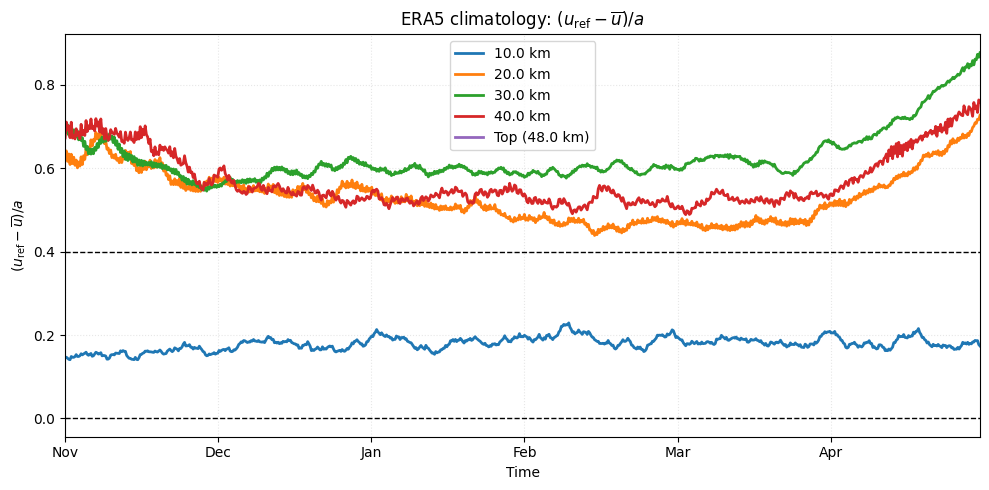

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. time axis (same as your ERA setting: Nov-Apr)
# ============================================================
era_t_start = 1 * 124   # Nov start
era_t_end   = 7 * 124   # Apr end
t_era_raw = np.arange(era_t_start, era_t_end)
t_era = np.linspace(40, 279, t_era_raw.size)   # match your model-style x axis

xticks = [40, 80, 120, 160, 200, 240]
xticklabels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']

# ============================================================
# 2. full-height ERA climatology (DO NOT mask heights yet)
# ============================================================
z_era_km_full = height / 1000.0

ubar_era_full = np.nanmean(ubar_eachyr, axis=1)[:, era_t_start:era_t_end]
uref_era_full = np.nanmean(uref_eachyr, axis=1)[:, era_t_start:era_t_end]
a_era_full    = np.nanmean(fawa_eachyr, axis=1)[:, era_t_start:era_t_end]

# ============================================================
# 3. compute ratio (uref - ubar) / a
# ============================================================
eps = 1e-6
a_safe = np.where(np.abs(a_era_full) < eps, np.nan, a_era_full)

ratio_era = (uref_era_full - ubar_era_full) / a_safe

# ============================================================
# 4. choose target levels
# ============================================================
target_levels = [10.0, 20.0, 30.0, 40.0]
level_indices = [np.argmin(np.abs(z_era_km_full - z0)) for z0 in target_levels]

# top level
ktop = len(z_era_km_full) - 1
level_indices.append(ktop)

level_labels = [f'{z_era_km_full[k]:.1f} km' for k in level_indices[:-1]] + [f'Top ({z_era_km_full[ktop]:.1f} km)']

# ============================================================
# 5. plot
# ============================================================
plt.figure(figsize=(10, 5))

for k, lab in zip(level_indices, level_labels):
    plt.plot(t_era, ratio_era[k, :], linewidth=2, label=lab)

plt.axhline(0, color='k', linewidth=1, linestyle='--')
plt.xlim(t_era[0], t_era[-1])
plt.xticks(xticks, xticklabels)
plt.xlabel('Time')
plt.ylabel(r'$(u_{\rm ref}-\overline{u})/a$')
plt.title(r'ERA5 climatology: $(u_{\rm ref}-\overline{u})/a$')
plt.axhline(0.4, color='k', linewidth=1, linestyle='--')
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

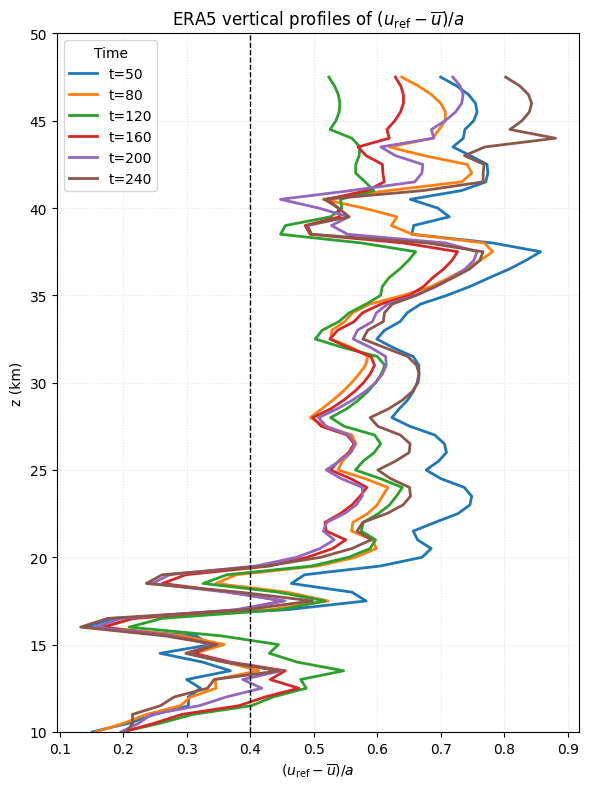

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 
# z_era_km_full = height / 1000.0
# ratio_era = (uref_era_full - ubar_era_full) / a_safe
# t_era = ...
# ============================================================

# ------------------------------------------------------------
# 1. 
#     t_era  model 
# ------------------------------------------------------------
t_pick = [50, 80, 120, 160, 200, 240]   # 

#  ERA index
time_idx = [np.argmin(np.abs(t_era - tt)) for tt in t_pick]

# ------------------------------------------------------------
# 2.  mask
# ------------------------------------------------------------
zmin, zmax = 10.0, 50.0
zmask = (z_era_km_full >= zmin) & (z_era_km_full <= zmax)

z_plot = z_era_km_full[zmask]
ratio_plot = ratio_era[zmask, :]

# ------------------------------------------------------------
# 3.  ERA5 
# ------------------------------------------------------------
plt.figure(figsize=(6, 8))

for idx in time_idx:
    plt.plot(ratio_plot[:, idx], z_plot, linewidth=2, label=f't={t_era[idx]:.0f}')

plt.axvline(0.4, color='k', linewidth=1, linestyle='--')
plt.ylim(zmin, zmax)
plt.xlabel(r'$(u_{\rm ref}-\overline{u})/a$')
plt.ylabel('z (km)')
plt.title(r'ERA5 vertical profiles of $(u_{\rm ref}-\overline{u})/a$')
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend(title='Time')
plt.tight_layout()
plt.show()

# start here

In [6]:
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/data/uout_real_urad_b0p238_s0p509.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/uout_real_urad_b0p238_s0p509.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/uout_b0p24s0p5_d5u10f15.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/uout_b0p79s2p0_d4u12f18.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/uout_b0p80s1p5_d4u9f14.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/uout_b0p20s0p5_d5_u9p0f16p0_a0p50_c2p200E-03_p3p0_ep250.nc'
#file = '/nas/smliu01/graybox/uout_b0p20s0p5_d5_u9p0f16p0.nc'
file = '/nas/winds-home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/uout_b0p23s0p5_d5_u7p0f16p0_a0p50_c2p200E-03_p4p0_ep300.nc'
#file = '/nas/winds-home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/uout_b0p23s0p5_d5_u7p0f16p0_a0p50_c2p200E-03_p4p0_ep300_early.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/uout_b0p81s1p5_d4u10f15.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/uout_real_urad_b0p200_s1p000.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/uout_real_urad_b0p554_s0p980.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/uout_real_urad_b0p238_s0p509_uth10p0_fx20p0_wT1p0_sk36p0_cn1p5.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
ubar = ncin.variables['ubar']
ubar = np.array(ubar)
ncin.close()
print(ubar.shape)

#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/data/aout_real_urad_b0p238_s0p509.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/aout_real_urad_b0p238_s0p509.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/aout_b0p24s0p5_d5u10f15.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/aout_b0p79s2p0_d4u12f18.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/aout_b0p80s1p5_d4u9f14.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/aout_b0p20s0p5_d5_u9p0f16p0_a0p50_c2p200E-03_p3p0_ep250.nc'
#file = '/nas/smliu01/graybox/aout_b0p20s0p5_d5_u9p0f16p0.nc'
file = '/nas/winds-home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/aout_b0p23s0p5_d5_u7p0f16p0_a0p50_c2p200E-03_p4p0_ep300.nc'
#file = '/nas/winds-home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/aout_b0p23s0p5_d5_u7p0f16p0_a0p50_c2p200E-03_p4p0_ep300_early.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/aout_b0p81s1p5_d4u10f15.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/aout_real_urad_b0p200_s1p000.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/aout_real_urad_b0p554_s0p980.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/aout_real_urad_b0p238_s0p509_uth10p0_fx20p0_wT1p0_sk36p0_cn1p5.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
fawa = ncin.variables['fawa']
fawa = np.array(fawa)
ncin.close()
print(fawa.shape)

#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/data/urout_real_urad_b0p238_s0p509.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urout_real_urad_b0p238_s0p509.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urout_b0p24s0p5_d5u10f15.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urout_b0p79s2p0_d4u12f18.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urout_b0p80s1p5_d4u9f14.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/urout_b0p20s0p5_d5_u9p0f16p0_a0p50_c2p200E-03_p3p0_ep250.nc'
#file = '/nas/smliu01/graybox/urout_b0p20s0p5_d5_u9p0f16p0.nc'
#file = '/nas/winds-home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/urout_b0p23s0p5_d5_u7p0f16p0_a0p50_c2p200E-03_p4p0_ep300.nc'
file = '/nas/winds-home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/urout_b0p23s0p5_d5_u7p0f16p0_a0p50_c2p200E-03_p4p0_ep300_early.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urout_b0p81s1p5_d4u10f15.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urout_real_urad_b0p200_s1p000.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urout_real_urad_b0p554_s0p980.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urout_real_urad_b0p238_s0p509_uth10p0_fx20p0_wT1p0_sk36p0_cn1p5.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
uref = ncin.variables['uref']
uref = np.array(uref)
ncin.close()
print(uref.shape)

#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/data/fzout_real_urad_b0p238_s0p509.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/fzout_real_urad_b0p238_s0p509.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/fzout_b0p24s0p5_d5u10f15.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/fzout_b0p79s2p0_d4u12f18.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/fzout_b0p80s1p5_d4u9f14.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/fzout_b0p20s0p5_d5_u9p0f16p0_a0p50_c2p200E-03_p3p0_ep250.nc'
#file = '/nas/smliu01/graybox/fzout_b0p20s0p5_d5_u9p0f16p0.nc'
file = '/nas/winds-home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/fzout_b0p23s0p5_d5_u7p0f16p0_a0p50_c2p200E-03_p4p0_ep300.nc'
#file = '/nas/winds-home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/fzout_b0p23s0p5_d5_u7p0f16p0_a0p50_c2p200E-03_p4p0_ep300_early.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/fzout_b0p81s1p5_d4u10f15.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/fzout_real_urad_b0p200_s1p000.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/fzout_real_urad_b0p554_s0p980.nc'
#file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/fzout_real_urad_b0p238_s0p509_uth10p0_fx20p0_wT1p0_sk36p0_cn1p5.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
fz = ncin.variables['fz']
fz = np.array(fz)
ncin.close()
print(fz.shape)

zdim = 501

height = np.zeros(97)
plev = np.zeros(97)
h1d = np.zeros(zdim)
dz = 500.
hh = 7000.
dz1d = 100000/(zdim-1)
for k in range(97):
    height[k] = k*dz
    plev[k] = 1000*np.exp(-height[k]/hh)
for k in range(zdim):
    h1d[k] = dz1d*k+10000.

print(height[96])
print(h1d[0])

hhh = np.arange(0,zdim,1)*(100/zdim)+10.

yr = 42    # 42 for 42 years, 10 for 10 years

# Reshape ubar, fawa, uref to (1001, 42, 320)
ubar_eachyear = ubar.reshape((zdim, yr, 320))
fawa_eachyear = fawa.reshape((zdim, yr, 320))
uref_eachyear = uref.reshape((zdim, yr, 320))
fz_eachyear = fz.reshape((zdim, yr, 320))

for i in range(zdim):
    fz_eachyear[i,:,:] = fz_eachyear[i,:,:]#/np.exp(-hhh[i]*1000/hh)


(501, 13440)
(501, 13440)
(501, 13440)
(501, 13440)
48000.0
10000.0


In [7]:
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0. read model budget files
# ============================================================
file_ub = '/nas/winds-home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/ubudget_single_A1.nc'
file_ab = '/nas/winds-home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/abudget_single_A1.nc'

with Dataset(file_ub, 'r') as nc:
    uterm1_mod = np.array(nc.variables['uterm1_epfd'])   # (time, z)
    uterm2_mod = np.array(nc.variables['uterm2_rad'])
    uterm4_mod = np.array(nc.variables['uterm4_mix'])
    utot_mod   = np.array(nc.variables['utot'])
    dudt_mod   = np.array(nc.variables['dudt'])

with Dataset(file_ab, 'r') as nc:
    aterm1_mod = np.array(nc.variables['aterm1_fluxdiv'])  # (time, z)
    aterm3_mod = np.array(nc.variables['aterm3_damp'])
    aterm4_mod = np.array(nc.variables['aterm4_mix'])
    atot_mod   = np.array(nc.variables['atot'])
    dadt_mod   = np.array(nc.variables['dadt'])

print("uterm1_mod:", uterm1_mod.shape)
print("aterm1_mod:", aterm1_mod.shape)

uterm1_mod: (501, 13440)
aterm1_mod: (501, 13440)


In [8]:
# ============================================================
# 1. reshape model budget: (time,z) -> (z, year, 320)
# ============================================================
yr = 42
nt_mod = 320

def reshape_model_budget(v_tz, zdim=470, yr=42, nt_mod=320):
    """
    input  : v_tz shape = (time, z)
    output : shape = (z, yr, nt_mod)
    """
    v_zt = np.array(v_tz).T
    return v_zt.reshape((zdim, yr, nt_mod))

uterm1_mod_zyt = reshape_model_budget(uterm1_mod, zdim, yr, nt_mod)
uterm2_mod_zyt = reshape_model_budget(uterm2_mod, zdim, yr, nt_mod)
uterm4_mod_zyt = reshape_model_budget(uterm4_mod, zdim, yr, nt_mod)
utot_mod_zyt   = reshape_model_budget(utot_mod,   zdim, yr, nt_mod)
dudt_mod_zyt   = reshape_model_budget(dudt_mod,   zdim, yr, nt_mod)

aterm1_mod_zyt = reshape_model_budget(aterm1_mod, zdim, yr, nt_mod)
aterm3_mod_zyt = reshape_model_budget(aterm3_mod, zdim, yr, nt_mod)
aterm4_mod_zyt = reshape_model_budget(aterm4_mod, zdim, yr, nt_mod)
atot_mod_zyt   = reshape_model_budget(atot_mod,   zdim, yr, nt_mod)
dadt_mod_zyt   = reshape_model_budget(dadt_mod,   zdim, yr, nt_mod)

In [9]:
# ============================================================
# 2. helper functions
# ============================================================
def compress_time_to_target_mean(v_zyt, target_len=320):
    v_zyt = np.asarray(v_zyt, dtype=float)
    nz, ny, nt_src = v_zyt.shape
    out = np.full((nz, ny, target_len), np.nan, dtype=float)

    t_src = (np.arange(nt_src) + 0.5) / nt_src
    edges = np.linspace(0.0, 1.0, target_len + 1)

    for j in range(target_len):
        mask = (t_src >= edges[j]) & (t_src < edges[j + 1])
        if j == target_len - 1:
            mask = (t_src >= edges[j]) & (t_src <= edges[j + 1])
        if np.any(mask):
            out[:, :, j] = np.nanmean(v_zyt[:, :, mask], axis=2)

    return out

def clim_on_320(field3d, zmask, t_slice):
    f_clim = np.nanmean(field3d, axis=1)   # (z, 320)
    return f_clim[zmask, t_slice]

def interp_vertical_2d(field_zt, z_src, z_tgt):
    field_zt = np.asarray(field_zt, dtype=float)
    out = np.full((len(z_tgt), field_zt.shape[1]), np.nan)
    for it in range(field_zt.shape[1]):
        out[:, it] = np.interp(z_tgt, z_src, field_zt[:, it])
    return out

def vertical_derivative(field_zyt, z_m):
    return np.gradient(field_zyt, z_m, axis=0)

def time_tendency(field_zyt, dt_seconds):
    return np.gradient(field_zyt, dt_seconds, axis=2)

In [10]:
# ============================================================
# 3. ERA5 tendency terms
# ============================================================
dt_era = 6 * 3600.0

dudt_era_eachyr = time_tendency(ubar_eachyr, dt_era)
dadt_era_eachyr = time_tendency(fawa_eachyr, dt_era)

z_era_m = height.copy()   # meters
epzdiv_era_eachyr = vertical_derivative(epz_eachyr, z_era_m)   # dFz/dz


dudt_era_320   = compress_time_to_target_mean(dudt_era_eachyr, target_len=320)
dadt_era_320   = compress_time_to_target_mean(dadt_era_eachyr, target_len=320)
epzdiv_era_320 = compress_time_to_target_mean(epzdiv_era_eachyr, target_len=320)

/tmp/ipykernel_3248528/781185548.py:17: RuntimeWarning: Mean of empty slice
  out[:, :, j] = np.nanmean(v_zyt[:, :, mask], axis=2)


In [11]:
# ============================================================
# 4. plotting window
# ============================================================
xx_320 = np.arange(320)
t_slice = slice(40, 280)
t_plot = xx_320[t_slice]

z_era_km = height / 1000.0
z_mod_km = hhh

zmin, zmax = 16.0, 48.0
era_z_mask = (z_era_km >= zmin) & (z_era_km <= zmax)
mod_z_mask = (z_mod_km >= zmin) & (z_mod_km <= zmax)

z_era_plot = z_era_km[era_z_mask]
z_mod_plot = z_mod_km[mod_z_mask]

In [12]:
# model ubar budget
uterm1_mod_2d = clim_on_320(uterm1_mod_zyt, mod_z_mask, t_slice)
uterm2_mod_2d = clim_on_320(uterm2_mod_zyt, mod_z_mask, t_slice)
uterm4_mod_2d = clim_on_320(uterm4_mod_zyt, mod_z_mask, t_slice)
utot_mod_2d   = clim_on_320(utot_mod_zyt,   mod_z_mask, t_slice)
dudt_mod_2d   = clim_on_320(dudt_mod_zyt,   mod_z_mask, t_slice)

# model A budget
aterm1_mod_2d = clim_on_320(aterm1_mod_zyt, mod_z_mask, t_slice)
aterm3_mod_2d = clim_on_320(aterm3_mod_zyt, mod_z_mask, t_slice)
aterm4_mod_2d = clim_on_320(aterm4_mod_zyt, mod_z_mask, t_slice)
atot_mod_2d   = clim_on_320(atot_mod_zyt,   mod_z_mask, t_slice)
dadt_mod_2d   = clim_on_320(dadt_mod_zyt,   mod_z_mask, t_slice)

In [13]:
# ERA5 tendency
dudt_era_2d = clim_on_320(dudt_era_320, era_z_mask, t_slice)
dadt_era_2d = clim_on_320(dadt_era_320, era_z_mask, t_slice)

# ERA5 EP flux divergence
epzdiv_era_2d = clim_on_320(epzdiv_era_320, era_z_mask, t_slice)

# ---- placeholders: replace with your exact theoretical prefactors ----
ubar_epfd_era_2d = -epzdiv_era_2d
a_fluxdiv_era_2d = -epzdiv_era_2d

# residuals
ubar_res_era_2d = dudt_era_2d - ubar_epfd_era_2d
a_res_era_2d    = dadt_era_2d - a_fluxdiv_era_2d

/tmp/ipykernel_3248528/781185548.py:22: RuntimeWarning: Mean of empty slice
  f_clim = np.nanmean(field3d, axis=1)   # (z, 320)


In [14]:
# ============================================================
# 5. interpolate ERA5 budget to model z-grid
# ============================================================
dudt_era_on_modz   = interp_vertical_2d(dudt_era_2d,      z_era_plot, z_mod_plot)
ubar_epfd_on_modz  = interp_vertical_2d(ubar_epfd_era_2d, z_era_plot, z_mod_plot)
ubar_res_on_modz   = interp_vertical_2d(ubar_res_era_2d,  z_era_plot, z_mod_plot)

dadt_era_on_modz   = interp_vertical_2d(dadt_era_2d,      z_era_plot, z_mod_plot)
a_fluxdiv_on_modz  = interp_vertical_2d(a_fluxdiv_era_2d, z_era_plot, z_mod_plot)
a_res_on_modz      = interp_vertical_2d(a_res_era_2d,     z_era_plot, z_mod_plot)

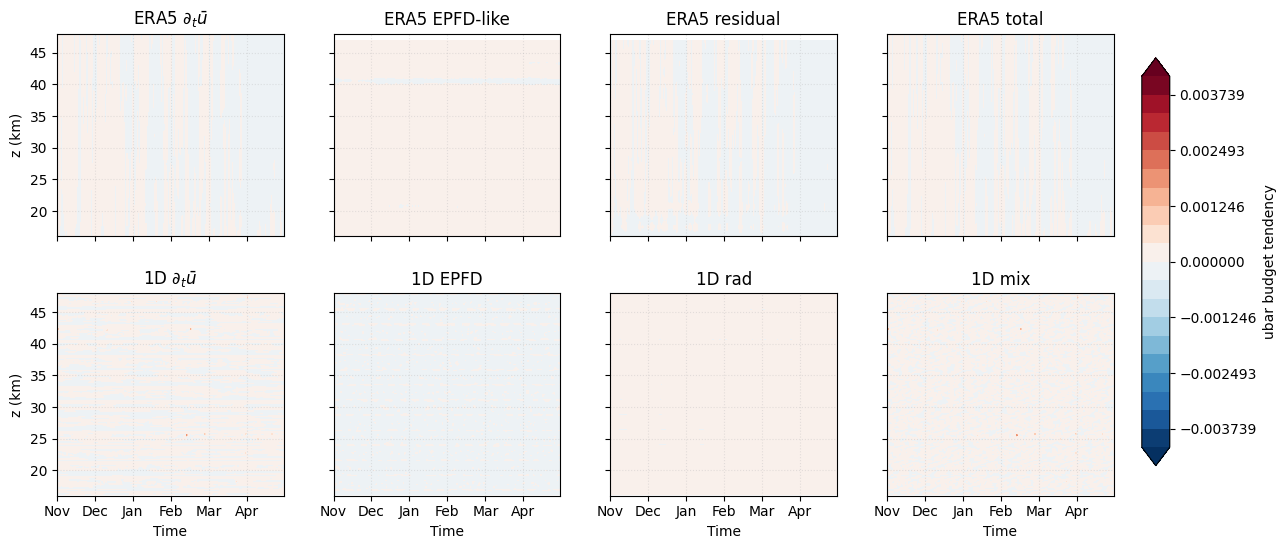

In [15]:
# ============================================================
# 6. plot ubar budget comparison
# ============================================================
Tm, Zm = np.meshgrid(t_plot, z_mod_plot)

xticks = [40, 80, 120, 160, 200, 240]
xticklabels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']

vabs_u = np.nanmax(np.abs([
    dudt_era_on_modz, ubar_epfd_on_modz, ubar_res_on_modz,
    dudt_mod_2d, uterm1_mod_2d, uterm2_mod_2d, uterm4_mod_2d
]))
vabs_u = float(vabs_u)
levels_u = np.linspace(-vabs_u, vabs_u, 21)

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=True)
fig.subplots_adjust(right=0.88, wspace=0.22, hspace=0.28)

# ---- ERA5 row ----
fields_top = [
    dudt_era_on_modz,
    ubar_epfd_on_modz,
    ubar_res_on_modz,
    dudt_era_on_modz
]
titles_top = [
    r'ERA5 $\partial_t \bar{u}$',
    r'ERA5 EPFD-like',
    r'ERA5 residual',
    r'ERA5 total'
]

for j in range(4):
    cf = axes[0, j].contourf(Tm, Zm, fields_top[j], levels=levels_u, cmap='RdBu_r', extend='both')
    axes[0, j].set_title(titles_top[j])
    axes[0, j].set_ylim(zmin, zmax)
    axes[0, j].grid(True, linestyle=':', alpha=0.3)

# ---- model row ----
fields_bot = [
    dudt_mod_2d,
    uterm1_mod_2d,
    uterm2_mod_2d,
    uterm4_mod_2d
]
titles_bot = [
    r'1D $\partial_t \bar{u}$',
    r'1D EPFD',
    r'1D rad',
    r'1D mix'
]

for j in range(4):
    cf = axes[1, j].contourf(Tm, Zm, fields_bot[j], levels=levels_u, cmap='RdBu_r', extend='both')
    axes[1, j].set_title(titles_bot[j])
    axes[1, j].set_ylim(zmin, zmax)
    axes[1, j].set_xticks(xticks)
    axes[1, j].set_xticklabels(xticklabels)
    axes[1, j].grid(True, linestyle=':', alpha=0.3)
    axes[1, j].set_xlabel('Time')

axes[0, 0].set_ylabel('z (km)')
axes[1, 0].set_ylabel('z (km)')

cax = fig.add_axes([0.90, 0.16, 0.02, 0.68])
cbar = fig.colorbar(cf, cax=cax)
cbar.set_label(r'ubar budget tendency')

plt.show()

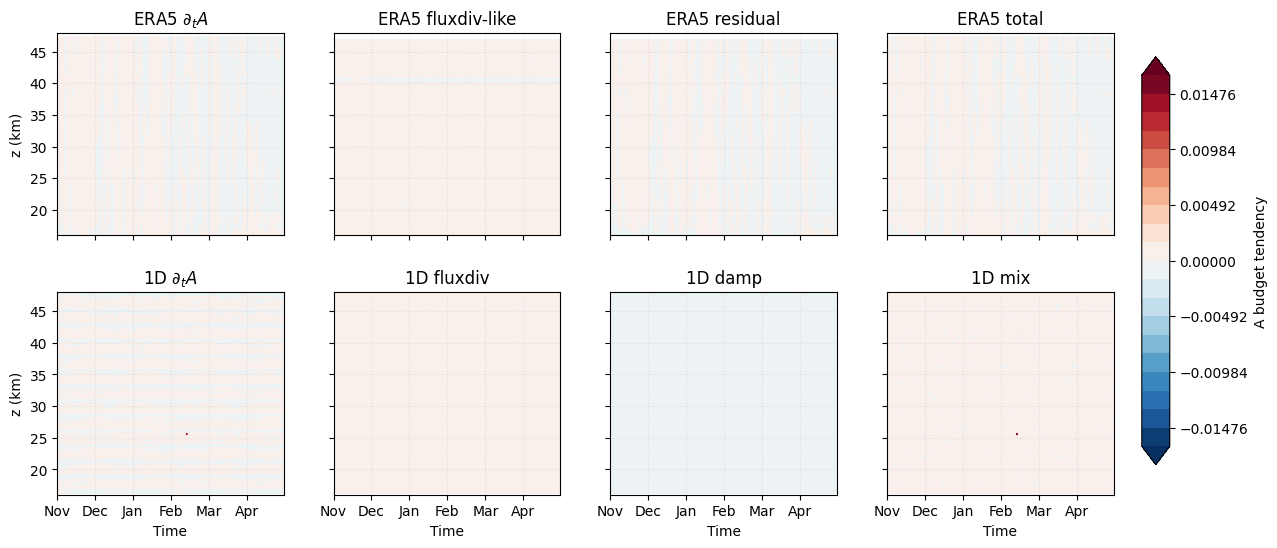

In [16]:
# ============================================================
# 7. plot A budget comparison
# ============================================================
vabs_a = np.nanmax(np.abs([
    dadt_era_on_modz, a_fluxdiv_on_modz, a_res_on_modz,
    dadt_mod_2d, aterm1_mod_2d, aterm3_mod_2d, aterm4_mod_2d
]))
vabs_a = float(vabs_a)
levels_a = np.linspace(-vabs_a, vabs_a, 21)

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=True)
fig.subplots_adjust(right=0.88, wspace=0.22, hspace=0.28)

# ---- ERA5 row ----
fields_top = [
    dadt_era_on_modz,
    a_fluxdiv_on_modz,
    a_res_on_modz,
    dadt_era_on_modz
]
titles_top = [
    r'ERA5 $\partial_t A$',
    r'ERA5 fluxdiv-like',
    r'ERA5 residual',
    r'ERA5 total'
]

for j in range(4):
    cf = axes[0, j].contourf(Tm, Zm, fields_top[j], levels=levels_a, cmap='RdBu_r', extend='both')
    axes[0, j].set_title(titles_top[j])
    axes[0, j].set_ylim(zmin, zmax)
    axes[0, j].grid(True, linestyle=':', alpha=0.3)

# ---- model row ----
fields_bot = [
    dadt_mod_2d,
    aterm1_mod_2d,
    aterm3_mod_2d,
    aterm4_mod_2d
]
titles_bot = [
    r'1D $\partial_t A$',
    r'1D fluxdiv',
    r'1D damp',
    r'1D mix'
]

for j in range(4):
    cf = axes[1, j].contourf(Tm, Zm, fields_bot[j], levels=levels_a, cmap='RdBu_r', extend='both')
    axes[1, j].set_title(titles_bot[j])
    axes[1, j].set_ylim(zmin, zmax)
    axes[1, j].set_xticks(xticks)
    axes[1, j].set_xticklabels(xticklabels)
    axes[1, j].grid(True, linestyle=':', alpha=0.3)
    axes[1, j].set_xlabel('Time')

axes[0, 0].set_ylabel('z (km)')
axes[1, 0].set_ylabel('z (km)')

cax = fig.add_axes([0.90, 0.16, 0.02, 0.68])
cbar = fig.colorbar(cf, cax=cax)
cbar.set_label(r'A budget tendency')

plt.show()

In [17]:
# model budget closure check
ubar_close_mod = dudt_mod_2d - (uterm1_mod_2d + uterm2_mod_2d + uterm4_mod_2d)
a_close_mod    = dadt_mod_2d - (aterm1_mod_2d + aterm3_mod_2d + aterm4_mod_2d)

print(np.mean(ubar_close_mod))
print(np.mean(a_close_mod))

-1.3375369e-11
-1.3286749e-11


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# common setup
# ============================================================
xx_320 = np.arange(320)

# Nov-Apr
t_slice = slice(40, 280)
t_plot = xx_320[t_slice]

xticks = [40, 80, 120, 160, 200, 240]
xticklabels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']

z_mod_km = hhh
zmin, zmax = 16.0, 48.0
mod_z_mask = (z_mod_km >= zmin) & (z_mod_km <= zmax)
z_mod_plot = z_mod_km[mod_z_mask]

def clim_on_320(field3d, zmask, t_slice=slice(40, 280)):
    """
    field3d shape = (z, year, 320)
    return shape = (z_selected, time_selected)
    """
    f_clim = np.nanmean(field3d, axis=1)   # (z, 320)
    return f_clim[zmask, t_slice]

Tm, Zm = np.meshgrid(t_plot, z_mod_plot)

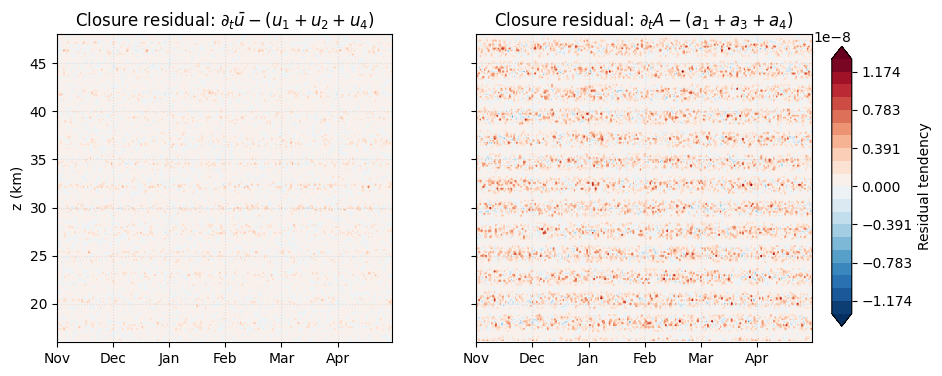

In [19]:
# ============================================================
# GROUP 1: closure check
# ============================================================
ubar_res_mod_zyt = dudt_mod_zyt - (uterm1_mod_zyt + uterm2_mod_zyt + uterm4_mod_zyt)
a_res_mod_zyt    = dadt_mod_zyt - (aterm1_mod_zyt + aterm3_mod_zyt + aterm4_mod_zyt)

ubar_res_mod_2d = clim_on_320(ubar_res_mod_zyt, mod_z_mask, t_slice)
a_res_mod_2d    = clim_on_320(a_res_mod_zyt,    mod_z_mask, t_slice)

vabs_res = np.nanmax(np.abs([ubar_res_mod_2d, a_res_mod_2d]))
levels_res = np.linspace(-vabs_res, vabs_res, 21)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
fig.subplots_adjust(right=0.88, wspace=0.25)

cf0 = axes[0].contourf(
    Tm, Zm, ubar_res_mod_2d,
    levels=levels_res, cmap='RdBu_r', extend='both'
)
axes[0].set_title(r'Closure residual: $\partial_t \bar{u} - (u_1+u_2+u_4)$')
axes[0].set_ylabel('z (km)')
axes[0].set_ylim(zmin, zmax)
axes[0].set_xticks(xticks)
axes[0].set_xticklabels(xticklabels)
axes[0].grid(True, linestyle=':', alpha=0.3)

cf1 = axes[1].contourf(
    Tm, Zm, a_res_mod_2d,
    levels=levels_res, cmap='RdBu_r', extend='both'
)
axes[1].set_title(r'Closure residual: $\partial_t A - (a_1+a_3+a_4)$')
axes[1].set_ylim(zmin, zmax)
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(xticklabels)
axes[1].grid(True, linestyle=':', alpha=0.3)

cax = fig.add_axes([0.90, 0.15, 0.02, 0.70])
cbar = fig.colorbar(cf1, cax=cax)
cbar.set_label('Residual tendency')

plt.show()

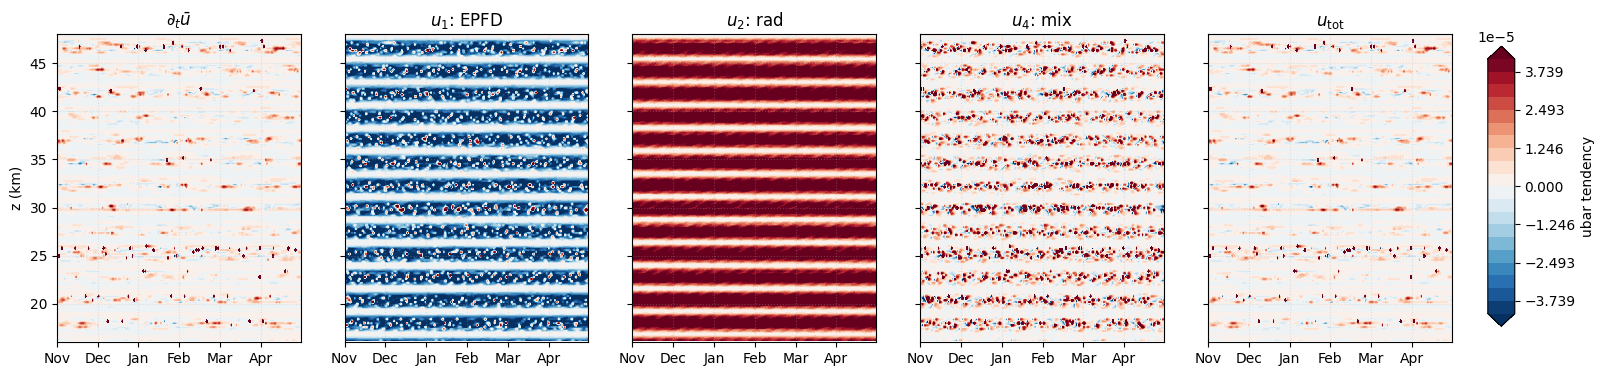

In [20]:
# ============================================================
# GROUP 2A: ubar budget 2D climatology
# ============================================================
dudt_mod_2d   = clim_on_320(dudt_mod_zyt,   mod_z_mask, t_slice)
uterm1_mod_2d = clim_on_320(uterm1_mod_zyt, mod_z_mask, t_slice)
uterm2_mod_2d = clim_on_320(uterm2_mod_zyt, mod_z_mask, t_slice)
uterm4_mod_2d = clim_on_320(uterm4_mod_zyt, mod_z_mask, t_slice)
utot_mod_2d   = clim_on_320(utot_mod_zyt,   mod_z_mask, t_slice)

fields_u = [dudt_mod_2d, uterm1_mod_2d, uterm2_mod_2d, uterm4_mod_2d, utot_mod_2d]
titles_u = [
    r'$\partial_t \bar{u}$',
    r'$u_1$: EPFD',
    r'$u_2$: rad',
    r'$u_4$: mix',
    r'$u_{\mathrm{tot}}$'
]

vabs_u = np.nanmax(np.abs(fields_u))
levels_u = np.linspace(-vabs_u, vabs_u, 21)/100

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharex=True, sharey=True)
fig.subplots_adjust(right=0.90, wspace=0.18)

for ax, fld, ttl in zip(axes, fields_u, titles_u):
    cf = ax.contourf(
        Tm, Zm, fld,
        levels=levels_u, cmap='RdBu_r', extend='both'
    )
    ax.set_title(ttl)
    ax.set_ylim(zmin, zmax)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.grid(True, linestyle=':', alpha=0.3)

axes[0].set_ylabel('z (km)')

cax = fig.add_axes([0.92, 0.15, 0.015, 0.70])
cbar = fig.colorbar(cf, cax=cax)
cbar.set_label(r'ubar tendency')

plt.show()

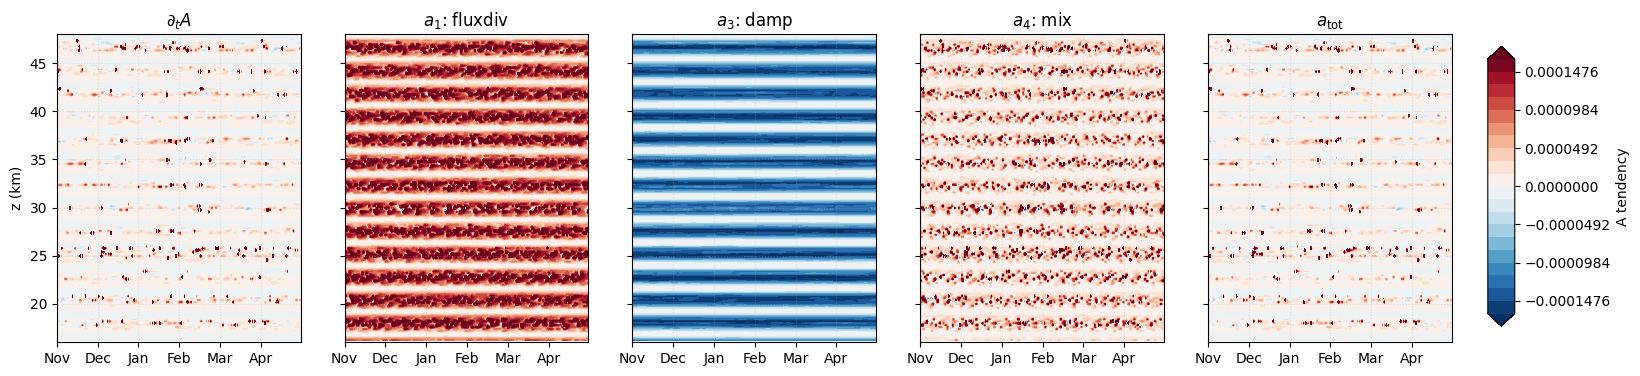

In [21]:
# ============================================================
# GROUP 2B: A budget 2D climatology
# ============================================================
dadt_mod_2d   = clim_on_320(dadt_mod_zyt,   mod_z_mask, t_slice)
aterm1_mod_2d = clim_on_320(aterm1_mod_zyt, mod_z_mask, t_slice)
aterm3_mod_2d = clim_on_320(aterm3_mod_zyt, mod_z_mask, t_slice)
aterm4_mod_2d = clim_on_320(aterm4_mod_zyt, mod_z_mask, t_slice)
atot_mod_2d   = clim_on_320(atot_mod_zyt,   mod_z_mask, t_slice)

fields_a = [dadt_mod_2d, aterm1_mod_2d, aterm3_mod_2d, aterm4_mod_2d, atot_mod_2d]
titles_a = [
    r'$\partial_t A$',
    r'$a_1$: fluxdiv',
    r'$a_3$: damp',
    r'$a_4$: mix',
    r'$a_{\mathrm{tot}}$'
]

vabs_a = np.nanmax(np.abs(fields_a))
levels_a = np.linspace(-vabs_a, vabs_a, 21)/100

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharex=True, sharey=True)
fig.subplots_adjust(right=0.90, wspace=0.18)

for ax, fld, ttl in zip(axes, fields_a, titles_a):
    cf = ax.contourf(
        Tm, Zm, fld,
        levels=levels_a, cmap='RdBu_r', extend='both'
    )
    ax.set_title(ttl)
    ax.set_ylim(zmin, zmax)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.grid(True, linestyle=':', alpha=0.3)

axes[0].set_ylabel('z (km)')

cax = fig.add_axes([0.92, 0.15, 0.015, 0.70])
cbar = fig.colorbar(cf, cax=cax)
cbar.set_label(r'A tendency')

plt.show()

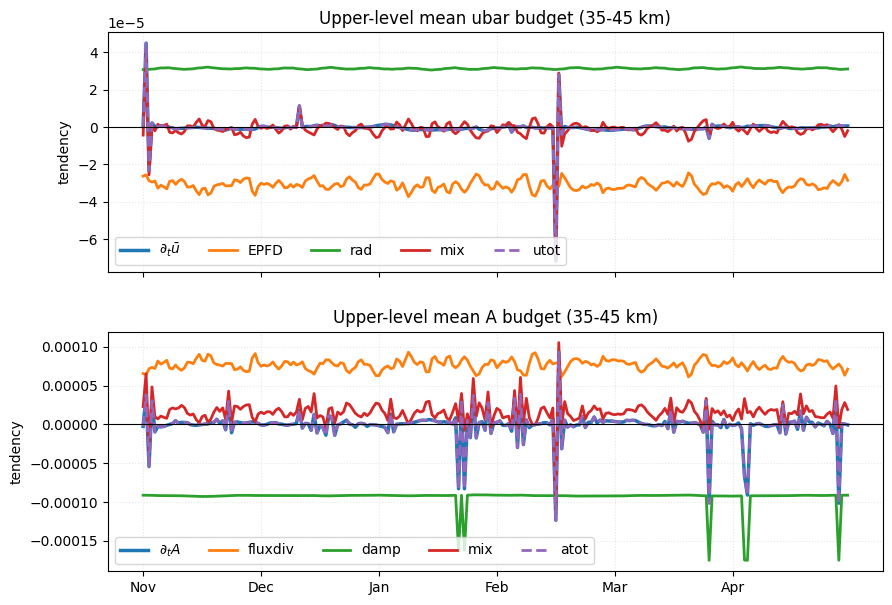

In [22]:
# ============================================================
# GROUP 3: upper-level mean time series
# ============================================================
z1, z2 = 35.0, 45.0
upper_mask = (z_mod_km >= z1) & (z_mod_km <= z2)

def upper_mean_ts(field3d, zmask_upper, t_slice=slice(40, 280)):
    """
    field3d shape = (z, year, 320)
    return climatological time series shape = (time_selected,)
    """
    f_clim = np.nanmean(field3d, axis=1)   # (z, 320)
    return np.nanmean(f_clim[zmask_upper, t_slice], axis=0)

# ubar budget time series
dudt_u_ts   = upper_mean_ts(dudt_mod_zyt,   upper_mask, t_slice)
uterm1_u_ts = upper_mean_ts(uterm1_mod_zyt, upper_mask, t_slice)
uterm2_u_ts = upper_mean_ts(uterm2_mod_zyt, upper_mask, t_slice)
uterm4_u_ts = upper_mean_ts(uterm4_mod_zyt, upper_mask, t_slice)
utot_u_ts   = upper_mean_ts(utot_mod_zyt,   upper_mask, t_slice)

# A budget time series
dadt_a_ts   = upper_mean_ts(dadt_mod_zyt,   upper_mask, t_slice)
aterm1_a_ts = upper_mean_ts(aterm1_mod_zyt, upper_mask, t_slice)
aterm3_a_ts = upper_mean_ts(aterm3_mod_zyt, upper_mask, t_slice)
aterm4_a_ts = upper_mean_ts(aterm4_mod_zyt, upper_mask, t_slice)
atot_a_ts   = upper_mean_ts(atot_mod_zyt,   upper_mask, t_slice)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.subplots_adjust(hspace=0.25)

# ---- ubar ----
axes[0].plot(t_plot, dudt_u_ts,   lw=2.5, label=r'$\partial_t \bar{u}$')
axes[0].plot(t_plot, uterm1_u_ts, lw=2.0, label='EPFD')
axes[0].plot(t_plot, uterm2_u_ts, lw=2.0, label='rad')
axes[0].plot(t_plot, uterm4_u_ts, lw=2.0, label='mix')
axes[0].plot(t_plot, utot_u_ts,   lw=2.0, ls='--', label='utot')
axes[0].axhline(0.0, color='k', lw=0.8)
axes[0].set_title(f'Upper-level mean ubar budget ({z1:.0f}-{z2:.0f} km)')
axes[0].set_ylabel('tendency')
axes[0].grid(True, linestyle=':', alpha=0.3)
axes[0].legend(ncol=5, fontsize=10)

# ---- A ----
axes[1].plot(t_plot, dadt_a_ts,   lw=2.5, label=r'$\partial_t A$')
axes[1].plot(t_plot, aterm1_a_ts, lw=2.0, label='fluxdiv')
axes[1].plot(t_plot, aterm3_a_ts, lw=2.0, label='damp')
axes[1].plot(t_plot, aterm4_a_ts, lw=2.0, label='mix')
axes[1].plot(t_plot, atot_a_ts,   lw=2.0, ls='--', label='atot')
axes[1].axhline(0.0, color='k', lw=0.8)
axes[1].set_title(f'Upper-level mean A budget ({z1:.0f}-{z2:.0f} km)')
axes[1].set_ylabel('tendency')
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(xticklabels)
axes[1].grid(True, linestyle=':', alpha=0.3)
axes[1].legend(ncol=5, fontsize=10)

plt.show()

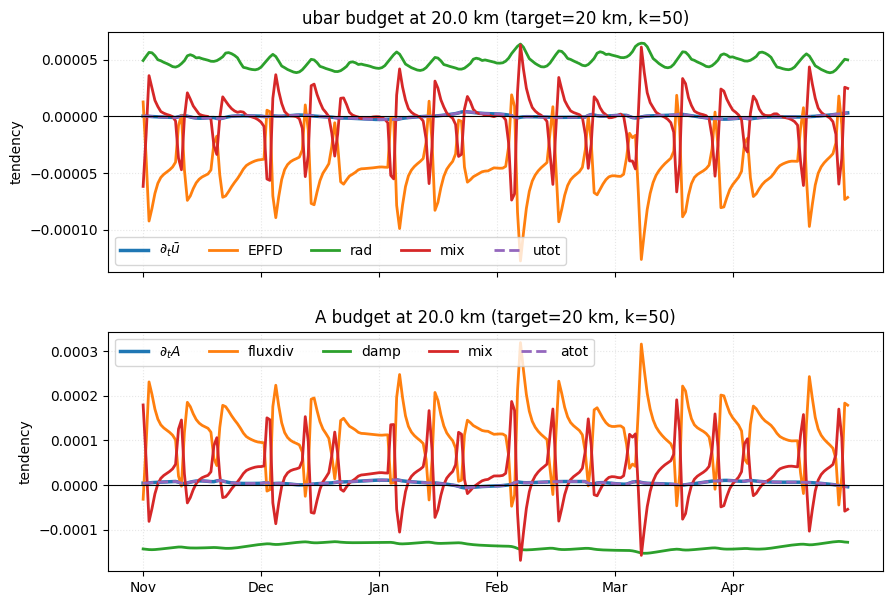

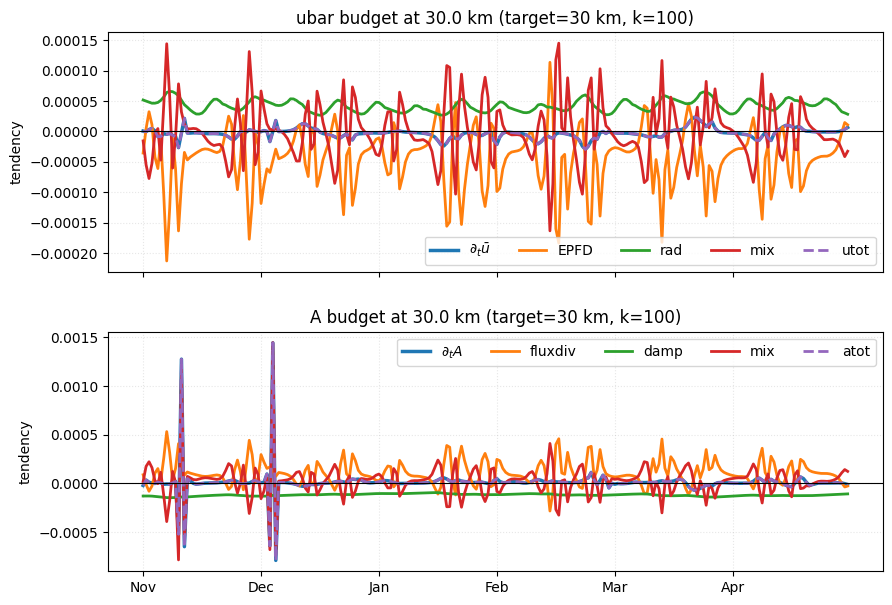

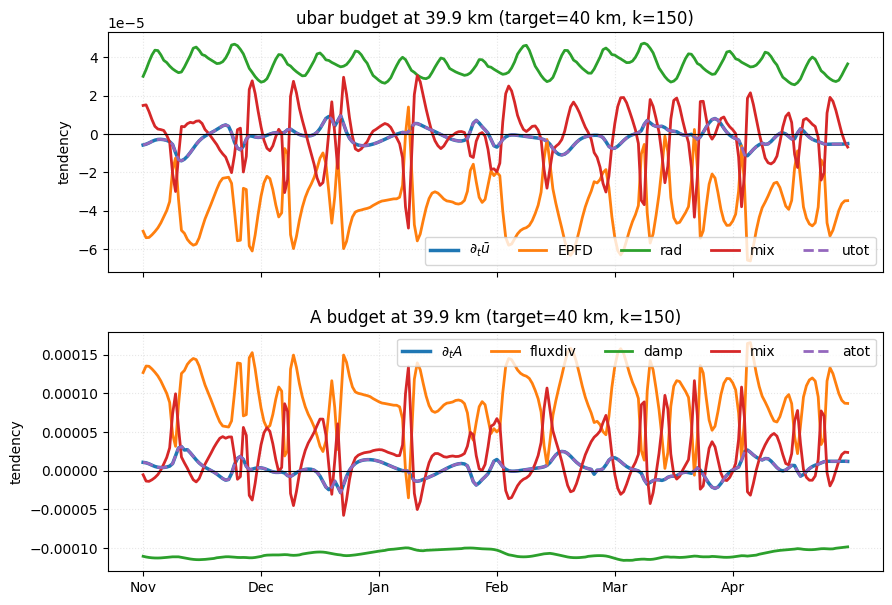

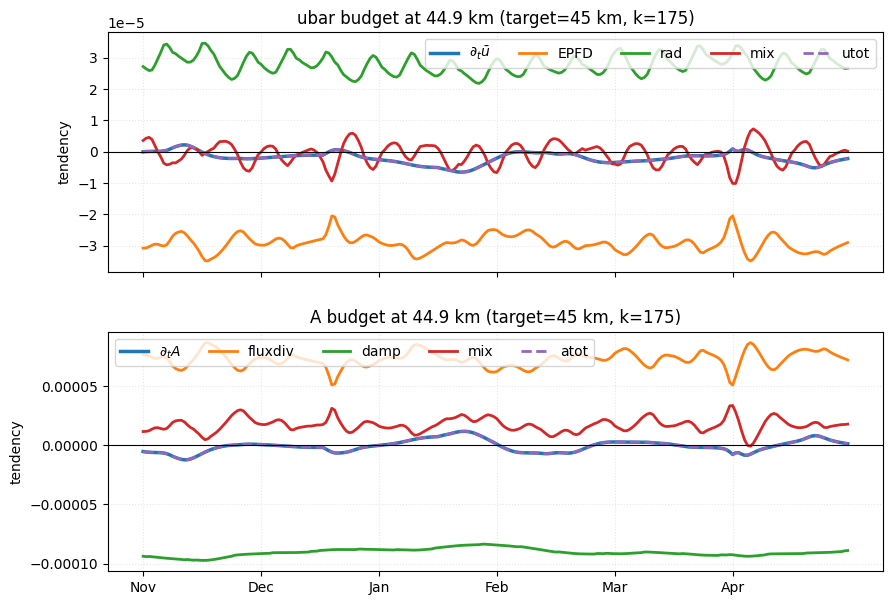

In [23]:
# ============================================================
# GROUP 3b: time series at fixed levels
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

z_targets = [20.0, 30.0, 40.0, 45.0]

def level_ts(field3d, z_coord, z_target, t_slice=slice(40, 280)):
    """
    field3d shape = (z, year, 320)
    return:
      ts      : climatological time series at nearest model level
      k       : nearest vertical index
      z_match : matched model height
    """
    k = np.argmin(np.abs(z_coord - z_target))
    f_clim = np.nanmean(field3d, axis=1)   # (z, 320)
    ts = f_clim[k, t_slice]
    return ts, k, z_coord[k]

for zt in z_targets:
    # ---- ubar budget at one level ----
    dudt_u_ts,   ku, zmatch = level_ts(dudt_mod_zyt,   z_mod_km, zt, t_slice)
    uterm1_u_ts, _, _       = level_ts(uterm1_mod_zyt, z_mod_km, zt, t_slice)
    uterm2_u_ts, _, _       = level_ts(uterm2_mod_zyt, z_mod_km, zt, t_slice)
    uterm4_u_ts, _, _       = level_ts(uterm4_mod_zyt, z_mod_km, zt, t_slice)
    utot_u_ts,   _, _       = level_ts(utot_mod_zyt,   z_mod_km, zt, t_slice)

    # ---- A budget at one level ----
    dadt_a_ts,   ka, _      = level_ts(dadt_mod_zyt,   z_mod_km, zt, t_slice)
    aterm1_a_ts, _, _       = level_ts(aterm1_mod_zyt, z_mod_km, zt, t_slice)
    aterm3_a_ts, _, _       = level_ts(aterm3_mod_zyt, z_mod_km, zt, t_slice)
    aterm4_a_ts, _, _       = level_ts(aterm4_mod_zyt, z_mod_km, zt, t_slice)
    atot_a_ts,   _, _       = level_ts(atot_mod_zyt,   z_mod_km, zt, t_slice)

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    fig.subplots_adjust(hspace=0.25)

    # ---- ubar ----
    axes[0].plot(t_plot, dudt_u_ts,   lw=2.5, label=r'$\partial_t \bar{u}$')
    axes[0].plot(t_plot, uterm1_u_ts, lw=2.0, label='EPFD')
    axes[0].plot(t_plot, uterm2_u_ts, lw=2.0, label='rad')
    axes[0].plot(t_plot, uterm4_u_ts, lw=2.0, label='mix')
    axes[0].plot(t_plot, utot_u_ts,   lw=2.0, ls='--', label='utot')
    axes[0].axhline(0.0, color='k', lw=0.8)
    axes[0].set_title(f'ubar budget at {zmatch:.1f} km (target={zt:.0f} km, k={ku})')
    axes[0].set_ylabel('tendency')
    axes[0].grid(True, linestyle=':', alpha=0.3)
    axes[0].legend(ncol=5, fontsize=10)

    # ---- A ----
    axes[1].plot(t_plot, dadt_a_ts,   lw=2.5, label=r'$\partial_t A$')
    axes[1].plot(t_plot, aterm1_a_ts, lw=2.0, label='fluxdiv')
    axes[1].plot(t_plot, aterm3_a_ts, lw=2.0, label='damp')
    axes[1].plot(t_plot, aterm4_a_ts, lw=2.0, label='mix')
    axes[1].plot(t_plot, atot_a_ts,   lw=2.0, ls='--', label='atot')
    axes[1].axhline(0.0, color='k', lw=0.8)
    axes[1].set_title(f'A budget at {zmatch:.1f} km (target={zt:.0f} km, k={ka})')
    axes[1].set_ylabel('tendency')
    axes[1].set_xticks(xticks)
    axes[1].set_xticklabels(xticklabels)
    axes[1].grid(True, linestyle=':', alpha=0.3)
    axes[1].legend(ncol=5, fontsize=10)

    plt.show()

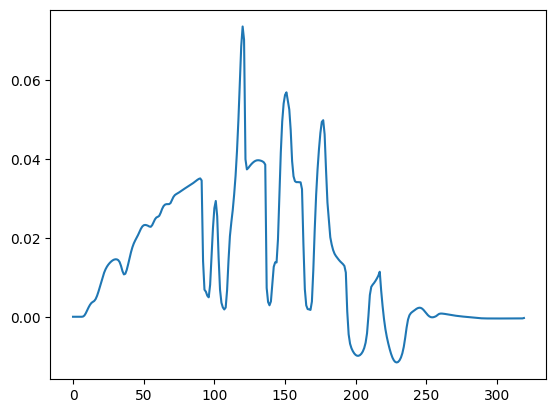

In [24]:
z = 110
plot.plot(3e-3*fawa_eachyear[z,0,:]*ubar_eachyear[z,0,:]*np.exp(-h1d[z]/hh))

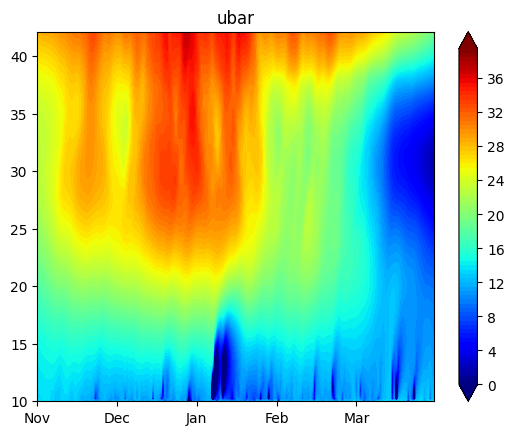

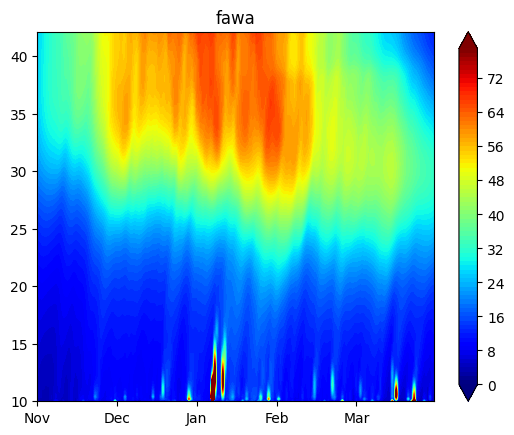

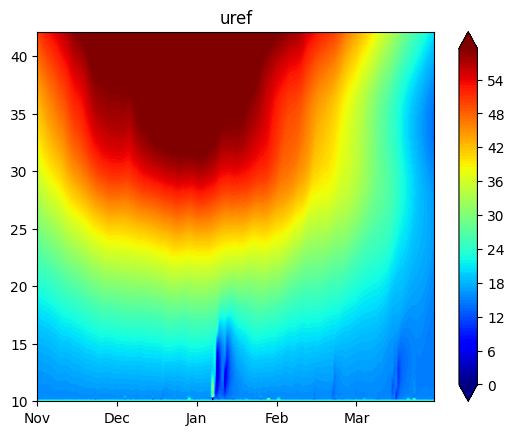

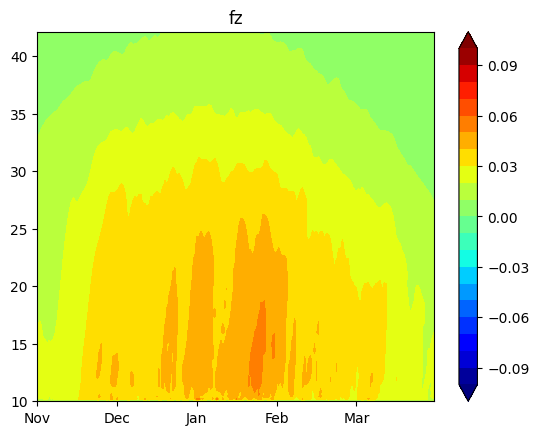

In [25]:
xx = np.arange(0,320,1) #*int(992/320)/4
zz = hhh

fig, ax = plot.subplots()
cf = ax.contourf(xx[40:240], zz[0:162], np.mean(ubar_eachyear[0:162,:,40:240], axis=1), levels=np.arange(0, 40, 0.5), extend='both', cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('ubar')
plot.colorbar(cf, ax=ax)
plot.show()

fig, ax = plot.subplots()   
cf = ax.contourf(xx[40:240],zz[0:162],np.mean(fawa_eachyear[0:162,:,40:240],axis=1), levels=np.arange(0, 80, 1), extend='both',cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('fawa')
plot.colorbar(cf, ax=ax)
plot.show()

fig, ax = plot.subplots()
cf = ax.contourf(xx[40:240],zz[0:162],np.mean(uref_eachyear[0:162,:,40:240],axis=1), levels=np.arange(0, 60, 0.5), extend='both', cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('uref')
plot.colorbar(cf, ax=ax)
plot.show()

fig, ax = plot.subplots()
cf = ax.contourf(xx[40:240],zz[0:162],np.mean(fz_eachyear[0:162,:,40:240],axis=1), levels=np.arange(-0.1, 0.11, 0.01),extend= 'both', cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('fz')
plot.colorbar(cf, ax=ax)
plot.show()


/tmp/ipykernel_3248528/478316630.py:31: RuntimeWarning: Mean of empty slice
  f_clim = np.nanmean(field3d, axis=1)


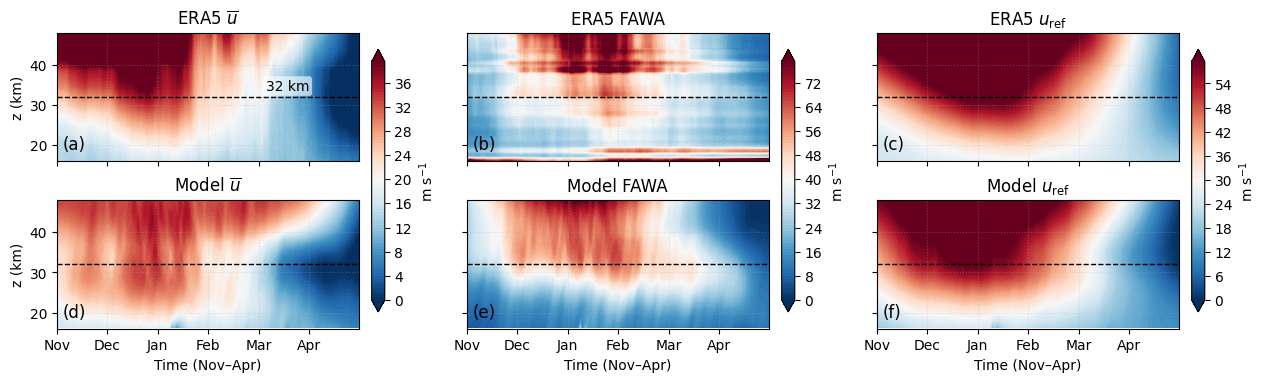

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# ========= 1.  =========
xx_mod = np.arange(0, 320)
t_mod_slice = slice(40, 280)  # 248april(31: Nov=40, Dec=71, Jan=102, Feb=133, Mar=164, Apr=195, May=226)
t_mod = xx_mod[t_mod_slice]

era_t_start = 1 * 124   # 124
era_t_end   = 7 * 124   # 868  6*124=744  Mar, 7*124=868  Apr
t_era_raw = np.arange(era_t_start, era_t_end)   #  744 

t_era = np.linspace(t_mod[0], t_mod[-1], t_era_raw.size)

z_era_km = height / 1000.0
z_mod_km = hhh

zmin, zmax = 16.0, 48 # 100
era_z_mask = (z_era_km >= zmin) & (z_era_km <= zmax)
mod_z_mask = (z_mod_km >= zmin) & (z_mod_km <= zmax)

z_era_plot = z_era_km[era_z_mask]
z_mod_plot = z_mod_km[mod_z_mask]

def clim_model(field3d):
    f_clim = np.nanmean(field3d, axis=1)
    f_season = f_clim[:, t_mod_slice]
    return f_season[mod_z_mask, :]

def clim_era(field3d):
    f_clim = np.nanmean(field3d, axis=1)
    f_season = f_clim[:, era_t_start:era_t_end]
    return f_season[era_z_mask, :]

ubar_mod_2d = clim_model(ubar_eachyear)
fawa_mod_2d = clim_model(fawa_eachyear)
uref_mod_2d = clim_model(uref_eachyear)
fz_mod_2d   = clim_model(fz_eachyear)

ubar_era_2d = clim_era(ubar_eachyr)
fawa_era_2d = clim_era(fawa_eachyr)
uref_era_2d = clim_era(uref_eachyr)
epz_era_2d  = clim_era(epz_eachyr)

# ========= 3. 32colorbar =========
# eramodel

fig, axes = plt.subplots(2, 3, figsize=(14, 4), sharex='col', sharey='row')

Tm, Zm = np.meshgrid(t_mod, z_mod_plot)
Te, Ze = np.meshgrid(t_era, z_era_plot)

xticks = [40, 80, 120, 160, 200, 240]
xticklabels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']

levels_ubar = np.arange(0, 40, 0.5)
levels_fawa = np.arange(0, 80, 1)
levels_uref = np.arange(0, 60, 0.5)

# a...(f
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# era  (0), model  (1)
cf0 = axes[0,0].contourf(Te, Ze, ubar_era_2d, levels=levels_ubar, extend='both', cmap='RdBu_r')
axes[0,0].set_title('ERA5 $\overline{u}$')

cf1 = axes[0,1].contourf(Te, Ze, fawa_era_2d, levels=levels_fawa, extend='both', cmap='RdBu_r')
axes[0,1].set_title('ERA5 FAWA')

cf2 = axes[0,2].contourf(Te, Ze, uref_era_2d, levels=levels_uref, extend='both', cmap='RdBu_r')
axes[0,2].set_title('ERA5 $u_{\\rm ref}$')

cf3 = axes[1,0].contourf(Tm, Zm, ubar_mod_2d, levels=levels_ubar, extend='both', cmap='RdBu_r')
axes[1,0].set_title('Model $\overline{u}$')

cf4 = axes[1,1].contourf(Tm, Zm, fawa_mod_2d, levels=levels_fawa, extend='both', cmap='RdBu_r')
axes[1,1].set_title('Model FAWA')

cf5 = axes[1,2].contourf(Tm, Zm, uref_mod_2d, levels=levels_uref, extend='both', cmap='RdBu_r')
axes[1,2].set_title('Model $u_{\\rm ref}$')

# 32km & 
z_line = 32.0
for i in range(2):
    for j in range(3):
        axes[i, j].set_ylim(zmin, zmax)
        axes[i, j].set_xticks(xticks)
        axes[i, j].set_xticklabels(xticklabels)
        axes[i, j].grid(True, linestyle=':', alpha=0.3)
        # 32km
        axes[i, j].axhline(z_line, color='k', linestyle='--', linewidth=1)
        # labellabel
        if j == 0 and i == 0:
            axes[i, j].text(
                xticks[-1], z_line+1, '32 km', color='k', va='bottom', ha='right', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.6)
            )
        # ab...
        axes[i, j].text(
            0.02, 0.2, panel_labels[i*3+j],
            transform=axes[i, j].transAxes,
            fontsize=12, 
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.15',ec='none', alpha=0),
            zorder=10
        )
for j in range(3):
    axes[1, j].set_xlabel('Time (Nov–Apr)')
axes[0, 0].set_ylabel('z (km)')
axes[1, 0].set_ylabel('z (km)')


# =====  =====
fig.subplots_adjust(
    left=0.06,   # 
    right=0.88,  #  0.88 12%  colorbar
    bottom=0.18,
    top=0.92,
    wspace=0.25,  # 
    hspace=0.30   # 
)

# =====  colorbar =====
colorbar_labels = [r'm s$^{-1}$', r'm s$^{-1}$', r'm s$^{-1}$']
cf_list = [cf0, cf1, cf2]

for j, (cf, label) in enumerate(zip(cf_list, colorbar_labels)):
    cb = fig.colorbar(
        cf,
        ax=[axes[0, j], axes[1, j]],  #  j 
        location='right',
        fraction=0.04,   # colorbar 
        pad=0.04,        # 
        shrink=0.9       # 
    )
    cb.set_label(label)

plt.savefig('output/era_ssw_zt.png', dpi=600, bbox_inches='tight')
plt.show()


40 hPa target pseudoheight = 43.50 km
Model nearest level: z = 43.53 km
ERA5 nearest level:  z = 43.50 km


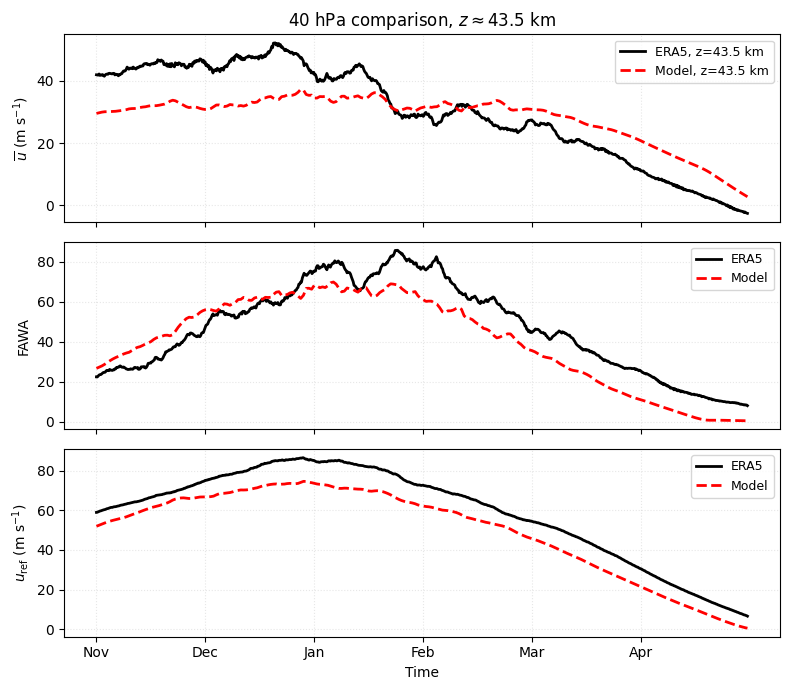

In [27]:
# =========================================================
# 4. 40 hPa time series comparison
# =========================================================

# 40 hPa  pressure pseudoheight
p_target = 2.0      # hPa
p0 = 1000.0          # hPa
H_km = 7.0           # scale height, km; 10 hPa -> about 32 km

z_target = H_km * np.log(p0 / p_target)

#  mask  z  40 hPa 
i_mod_40 = int(np.argmin(np.abs(z_mod_plot - z_target)))
i_era_40 = int(np.argmin(np.abs(z_era_plot - z_target)))

z_mod_40 = z_mod_plot[i_mod_40]
z_era_40 = z_era_plot[i_era_40]

print(f"40 hPa target pseudoheight = {z_target:.2f} km")
print(f"Model nearest level: z = {z_mod_40:.2f} km")
print(f"ERA5 nearest level:  z = {z_era_40:.2f} km")

#  40 hPa 
ubar_mod_40 = ubar_mod_2d[i_mod_40, :]
fawa_mod_40 = fawa_mod_2d[i_mod_40, :]
uref_mod_40 = uref_mod_2d[i_mod_40, :]

ubar_era_40 = ubar_era_2d[i_era_40, :]
fawa_era_40 = fawa_era_2d[i_era_40, :]
uref_era_40 = uref_era_2d[i_era_40, :]

# =========================================================
# plot
# =========================================================
fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

# ---- ubar ----
axes[0].plot(
    t_era, ubar_era_40,
    color='k', lw=2.0,
    label=f'ERA5, z={z_era_40:.1f} km'
)
axes[0].plot(
    t_mod, ubar_mod_40,
    color='red', lw=2.0, ls='--',
    label=f'Model, z={z_mod_40:.1f} km'
)
axes[0].set_ylabel(r'$\overline{u}$ (m s$^{-1}$)')
axes[0].set_title(rf'40 hPa comparison, $z \approx {z_target:.1f}$ km')
axes[0].grid(True, linestyle=':', alpha=0.3)
axes[0].legend(fontsize=9)

# ---- FAWA ----
axes[1].plot(
    t_era, fawa_era_40,
    color='k', lw=2.0,
    label='ERA5'
)
axes[1].plot(
    t_mod, fawa_mod_40,
    color='red', lw=2.0, ls='--',
    label='Model'
)
axes[1].set_ylabel('FAWA')
axes[1].grid(True, linestyle=':', alpha=0.3)
axes[1].legend(fontsize=9)

# ---- uref ----
axes[2].plot(
    t_era, uref_era_40,
    color='k', lw=2.0,
    label='ERA5'
)
axes[2].plot(
    t_mod, uref_mod_40,
    color='red', lw=2.0, ls='--',
    label='Model'
)
axes[2].set_ylabel(r'$u_{\rm ref}$ (m s$^{-1}$)')
axes[2].set_xlabel('Time')
axes[2].grid(True, linestyle=':', alpha=0.3)
axes[2].legend(fontsize=9)

axes[2].set_xticks(xticks)
axes[2].set_xticklabels(xticklabels)

plt.tight_layout()
plt.savefig('output/era_model_40hpa_timeseries.png', dpi=600, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3248528/3372918792.py:33: RuntimeWarning: Mean of empty slice
  f_clim = np.nanmean(field3d, axis=1)


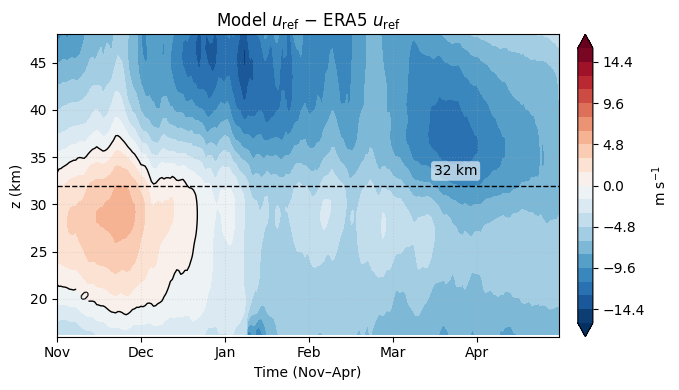

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# ========= 1.  =========
xx_mod = np.arange(0, 320)
t_mod_slice = slice(40, 280)   # Nov-Apr
t_mod = xx_mod[t_mod_slice]

era_t_start = 1 * 124   # 124
era_t_end   = 7 * 124   # 868
t_era_raw = np.arange(era_t_start, era_t_end)   # length 744
t_era = np.linspace(t_mod[0], t_mod[-1], t_era_raw.size)

z_era_km = height / 1000.0
z_mod_km = hhh

zmin, zmax = 16.0, 48.0
era_z_mask = (z_era_km >= zmin) & (z_era_km <= zmax)
mod_z_mask = (z_mod_km >= zmin) & (z_mod_km <= zmax)

z_era_plot = z_era_km[era_z_mask]
z_mod_plot = z_mod_km[mod_z_mask]

# ========= 2. climatology =========
def clim_model(field3d):
    # field3d: (z, year, time)
    f_clim = np.nanmean(field3d, axis=1)
    f_season = f_clim[:, t_mod_slice]
    return f_season[mod_z_mask, :]

def clim_era(field3d):
    # field3d: (z, year, time)
    f_clim = np.nanmean(field3d, axis=1)
    f_season = f_clim[:, era_t_start:era_t_end]
    return f_season[era_z_mask, :]

uref_mod_2d = clim_model(uref_eachyear)   # shape: (nz_mod, nt_mod)
uref_era_2d = clim_era(uref_eachyr)       # shape: (nz_era, nt_era)

# ========= 3.  ERA5  model  =========
uref_era_time_interp = np.empty((uref_era_2d.shape[0], len(t_mod)))

for k in range(uref_era_2d.shape[0]):
    uref_era_time_interp[k, :] = np.interp(
        t_mod, t_era, uref_era_2d[k, :]
    )

# ========= 4.  ERA5  model  =========
uref_era_on_mod = np.empty((len(z_mod_plot), len(t_mod)))

for it in range(len(t_mod)):
    uref_era_on_mod[:, it] = np.interp(
        z_mod_plot, z_era_plot, uref_era_time_interp[:, it]
    )

# ========= 5.  =========
uref_diff = uref_mod_2d - uref_era_on_mod
#  ERA5 - model
# uref_diff = uref_era_on_mod - uref_mod_2d

# ========= 6.  =========
fig, ax = plt.subplots(figsize=(7, 4))

Tm, Zm = np.meshgrid(t_mod, z_mod_plot)

xticks = [40, 80, 120, 160, 200, 240]
xticklabels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']

# 
vmax = np.nanmax(np.abs(uref_diff))
vmax = np.ceil(vmax / 2) * 2   # 
levels_diff = np.linspace(-vmax, vmax, 21)

cf = ax.contourf(
    Tm, Zm, uref_diff,
    levels=levels_diff,
    cmap='RdBu_r',
    extend='both'
)

# 0
cs = ax.contour(
    Tm, Zm, uref_diff,
    levels=[0],
    colors='k',
    linewidths=1.0
)
ax.clabel(cs, fmt='%d', fontsize=9)

z_line = 32.0
ax.axhline(z_line, color='k', linestyle='--', linewidth=1)
ax.text(
    xticks[-1], z_line + 0.8, '32 km',
    color='k', va='bottom', ha='right', fontsize=10,
    bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
              edgecolor='none', alpha=0.6)
)

ax.set_ylim(zmin, zmax)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time (Nov–Apr)')
ax.set_ylabel('z (km)')
ax.set_title(r'Model $u_{\rm ref}$ $-$ ERA5 $u_{\rm ref}$')
ax.grid(True, linestyle=':', alpha=0.3)

cb = fig.colorbar(cf, ax=ax, pad=0.03)
cb.set_label(r'm s$^{-1}$')

plt.tight_layout()
plt.show()

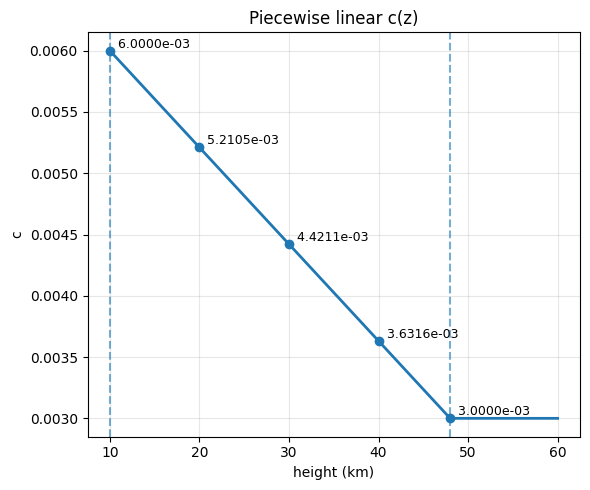

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# settings
# ============================================================
const1 = 3e-3   #  const1
z1 = 10.0       # km
z2 = 48.0       # km
c1_bot_fac = 2.0
c1_top_fac = 1.0

# ============================================================
# define c(z)
# ============================================================
def c1_eff_func(z_km, const1=3e-3, z1=10.0, z2=48.0,
                c1_bot_fac=2.0, c1_top_fac=1.0):
    z_km = np.asarray(z_km, dtype=float)
    c = np.empty_like(z_km)

    mask1 = z_km <= z1
    mask2 = z_km >= z2
    maskm = (~mask1) & (~mask2)

    c[mask1] = c1_bot_fac * const1
    c[mask2] = c1_top_fac * const1
    c[maskm] = (
        c1_bot_fac
        + (c1_top_fac - c1_bot_fac) * (z_km[maskm] - z1) / (z2 - z1)
    ) * const1

    return c

# ============================================================
# plot on a fine z grid
# ============================================================
z_plot = np.linspace(10, 60, 500)
c_plot = c1_eff_func(z_plot, const1, z1, z2, c1_bot_fac, c1_top_fac)

plt.figure(figsize=(6, 5))
plt.plot(z_plot, c_plot, lw=2)

plt.axvline(10, ls='--', alpha=0.6)
plt.axvline(48, ls='--', alpha=0.6)

plt.scatter([10, 20, 30, 40, 48],
            c1_eff_func(np.array([10, 20, 30, 40, 48]),
                        const1, z1, z2, c1_bot_fac, c1_top_fac),
            zorder=5)

for zz in [10, 20, 30, 40, 48]:
    cc = c1_eff_func(np.array([zz]), const1, z1, z2, c1_bot_fac, c1_top_fac)[0]
    plt.text(zz, cc, f'  {cc:.4e}', fontsize=9, va='bottom')

plt.xlabel('height (km)')
plt.ylabel('c')
plt.title('Piecewise linear c(z)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

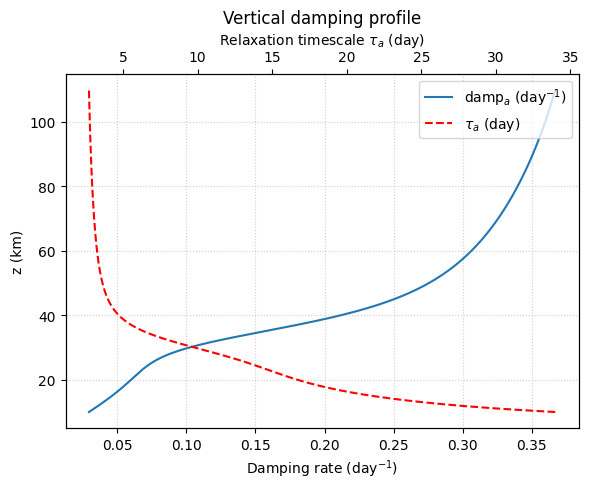

In [30]:
import numpy as np
import matplotlib.pyplot as plt

#  Fortran 
dz = 200.0            #  (m)
kmin, kmax = 1, zdim   # Python0fortran1:501
damp2_a = 1.0 / 30.0  # damping

z0 = 32.0    # km, 
w0 = 8.0     # km, gate sigmoid
Hdamp = 12.0 # km, 
Aexp = 0.18  # 

karr = np.arange(kmin, kmax + 1)  # 1–501  # For every integer k in [1,501]
z = dz * (karr.astype(float) - 1) + 10000.0  # m
zkm = z / 1000.0                             # km

damp_lin = (karr.astype(float) - 1) / 1200.0 + damp2_a
gate = 0.5 * (1.0 + np.tanh((zkm - z0) / w0))
damp_raw = damp_lin + gate * Aexp * (1.0 - np.exp(-(zkm - z0) / Hdamp))
damp_cap = 1.0 / 2.5

damp_a = damp_cap * np.tanh(damp_raw / damp_cap)

tau_a = 3600.0 * 24.0 / damp_a  # 

fig, ax1 = plt.subplots(figsize=(6,5))
ax1.plot(damp_a, zkm, label=r"$\mathrm{damp}_a$ (day$^{-1}$)")
ax1.set_xlabel(r"Damping rate (day$^{-1}$)")
ax1.set_ylabel("z (km)")
ax1.set_title("Vertical damping profile")

ax2 = ax1.twiny()
ax2.plot(tau_a/86400.0, zkm, 'r--', label=r"$\tau_a$ (day)")
ax2.set_xlabel(r"Relaxation timescale $\tau_a$ (day)")
ax1.grid(True, linestyle=":", alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper right")

plt.tight_layout()
plt.show()

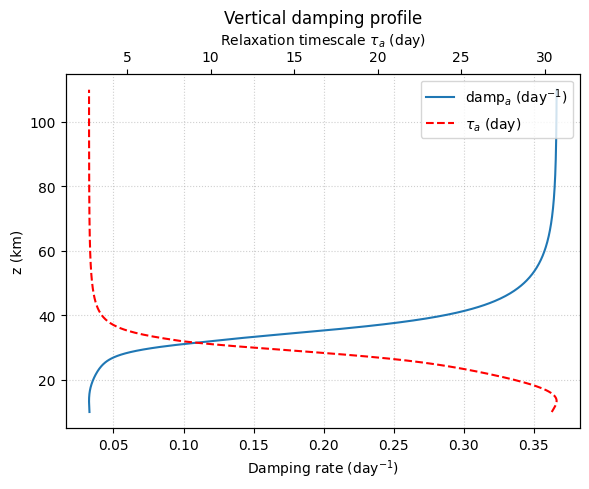

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# parameters
# =========================
zdim = 501
dz = 200.0
kmin, kmax = 1, zdim

damp2_a = 1.0 / 30.0   # low-level baseline damping (day^-1)

zbot = 10.0   # km
z0   = 32.0   # km

# lower part: convex below 32 km
ppow = 3

# upper part: concave / saturating above 32 km
Hdamp = 12.0
Aexp  = 0.5
w0    = 5.0

# smooth cap
damp_cap = 1.0 / 2.5

# =========================
# grid
# =========================
karr = np.arange(kmin, kmax + 1)
z = dz * (karr.astype(float) - 1.0) + 10000.0   # m
zkm = z / 1000.0                                # km

# =========================
# damping profile
# =========================
# value at 32 km, matched to your old linear profile
damp32 = ((z0 - zbot) / (dz / 1000.0)) / 1200.0 + damp2_a

# lower branch: convex
xlow = (zkm - zbot) / (z0 - zbot)
xlow = np.clip(xlow, 0.0, 1.0)
damp_low = damp2_a + (damp32 - damp2_a) * xlow**ppow

# upper branch: concave / saturating
damp_high = damp32 + Aexp * (1.0 - np.exp(-(zkm - z0) / Hdamp))

# smooth transition around 32 km
gate = 0.5 * (1.0 + np.tanh((zkm - z0) / w0))

# blend low/high
damp_raw = (1.0 - gate) * damp_low + gate * damp_high

# smooth cap
damp_a = damp_cap * np.tanh(damp_raw / damp_cap)

# relaxation timescale
tau_a = 1.0 / damp_a   # day

# =========================
# plot
# =========================
fig, ax1 = plt.subplots(figsize=(6, 5))

ax1.plot(damp_a, zkm, label=r"$\mathrm{damp}_a$ (day$^{-1}$)")
ax1.set_xlabel(r"Damping rate (day$^{-1}$)")
ax1.set_ylabel("z (km)")
ax1.set_title("Vertical damping profile")

ax2 = ax1.twiny()
ax2.plot(tau_a, zkm, 'r--', label=r"$\tau_a$ (day)")
ax2.set_xlabel(r"Relaxation timescale $\tau_a$ (day)")

ax1.grid(True, linestyle=":", alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

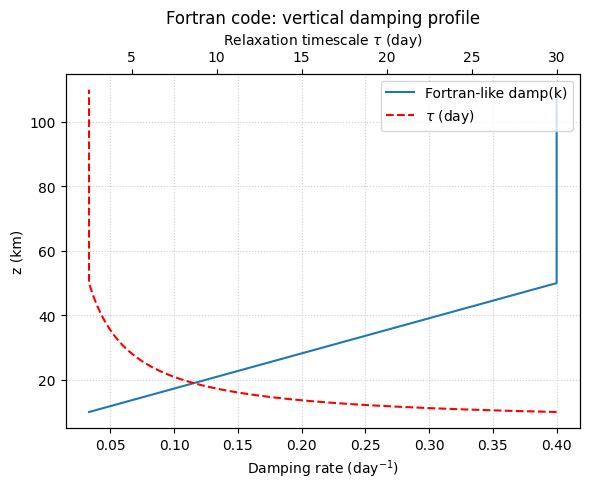

In [32]:
#  Fortran(290-301)damp(k)
# x cell 32  damping  tau x

damp1_days = 2.5  # damp_cap2.5
damp1 = 1.0 / damp1_days
damp2 = 1.0 / 30.0
kmax_fortran = zdim
karr_f = np.arange(1, kmax_fortran + 1)
k40 = int((kmax_fortran - 1) * 0.4) + 1
damp_f = np.zeros_like(karr_f, dtype=float)

for i, k in enumerate(karr_f):
    if k <= k40:
        damp_f[i] = damp2 + (k - 1) * (damp1 - damp2) / (k40 - 1)
    else:
        damp_f[i] = damp1

tau_f = 3600.0 * 24.0 / damp_f  # 
tau_f_day = tau_f / 86400.0     # 

z_f = dz * (karr_f.astype(float) - 1) / 1000.0 + 10.0  # km+10km

fig, ax1 = plt.subplots(figsize=(6,5))
ax1.plot(damp_f, z_f, label="Fortran-like damp(k)")
ax1.set_xlabel(r"Damping rate (day$^{-1}$)")
ax1.set_ylabel("z (km)")
ax1.set_title("Fortran code: vertical damping profile")

ax2 = ax1.twiny()
ax2.plot(tau_f_day, z_f, 'r--', label=r"$\tau$ (day)")
ax2.set_xlabel(r"Relaxation timescale $\tau$ (day)")
ax1.grid(True, linestyle=":", alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

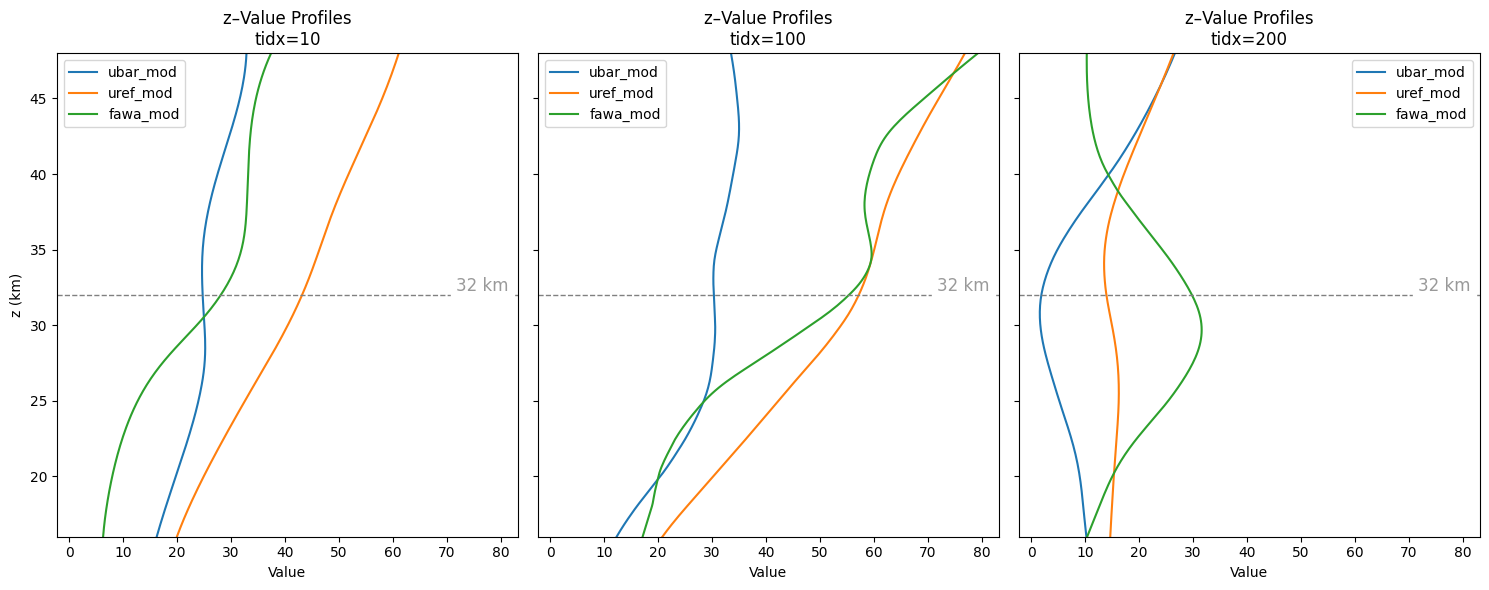

In [33]:
zmin, zmax = 16.0, 48.0  # z
z_levels = np.linspace(zmin, zmax, ubar_mod_2d.shape[0])  # z
tidx_list = [10, 100, 200]  # 

# tidx
all_values = np.concatenate([
    ubar_mod_2d[:, tidx].ravel() for tidx in tidx_list
] + [
    uref_mod_2d[:, tidx].ravel() for tidx in tidx_list
] + [
    fawa_mod_2d[:, tidx].ravel() for tidx in tidx_list
])
x_min, x_max = np.nanmin(all_values), np.nanmax(all_values)
# 
x_pad = 0.05 * (x_max - x_min)
x_lim = (x_min - x_pad, x_max + x_pad)

fig, axes = plt.subplots(1, len(tidx_list), figsize=(5 * len(tidx_list), 6), sharey=True)
if len(tidx_list) == 1:
    axes = [axes]  #  axes 

for i, tidx in enumerate(tidx_list):
    ax = axes[i]
    ax.plot(ubar_mod_2d[:, tidx], z_levels, label='ubar_mod')
    ax.plot(uref_mod_2d[:, tidx], z_levels, label='uref_mod')
    ax.plot(fawa_mod_2d[:, tidx], z_levels, label='fawa_mod')
    ax.set_xlabel('Value')
    ax.set_title(f'z–Value Profiles\ntidx={tidx}')
    # 
    ax.set_xlim(x_lim)
    # 32km
    ax.axhline(32, color='gray', linestyle='--', linewidth=1)
    ax.text(0.98, 32, "32 km", va='bottom', ha='right', fontsize=12, color='gray', 
            backgroundcolor="white", alpha=0.8, transform=ax.get_yaxis_transform())
    #  era5_dates[tidx] 
    if ('era5_dates' in locals() or 'era5_dates' in globals()) and len(era5_dates) > tidx:
        date_str = era5_dates[tidx]
        ax.text(0.98, 0.02, date_str, transform=ax.transAxes, ha='right', va='bottom', fontsize=12,
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    if i == 0:
        ax.set_ylabel('z (km)')
    ax.set_ylim([zmin, zmax])
    ax.legend()

plt.tight_layout()
plt.show()


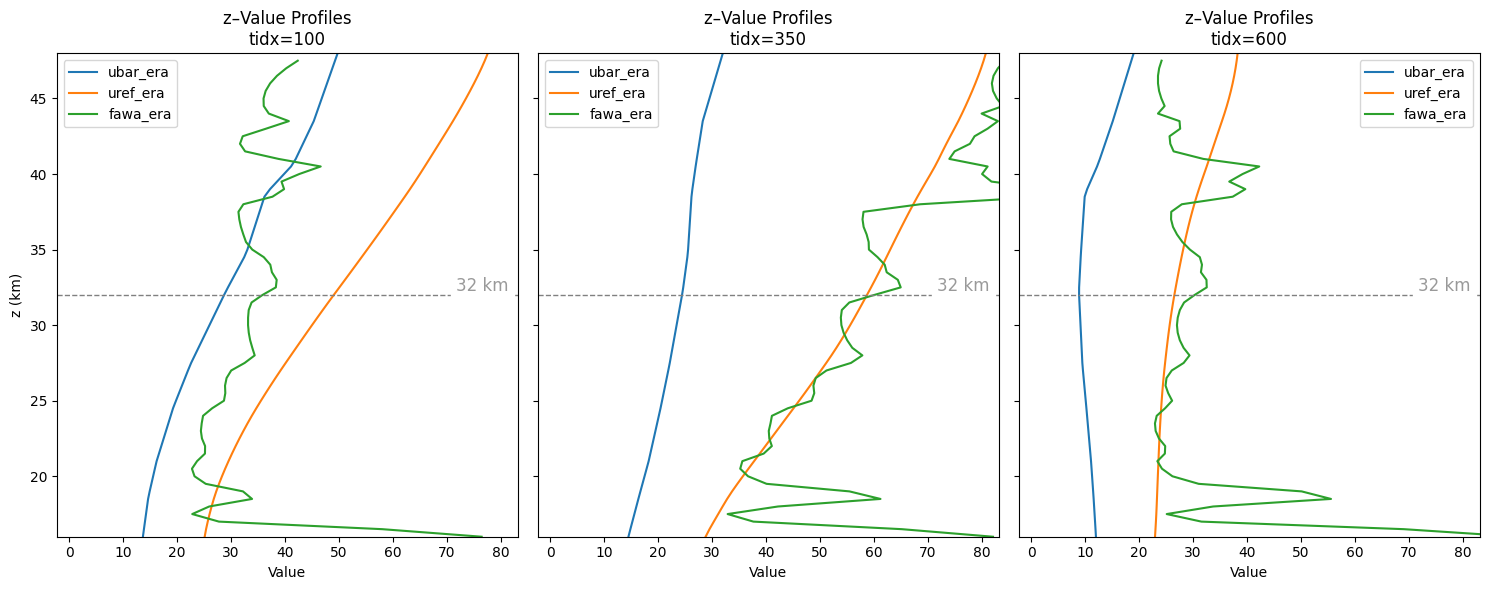

In [34]:
zmin, zmax = 16.0, 48.0  # z
z_levels = np.linspace(zmin, zmax, ubar_era_2d.shape[0])  # z16-48km
tidx_list = [100, 350, 600]  # 

# x
all_era_values = np.concatenate([
    ubar_era_2d[:, tidx].ravel() for tidx in tidx_list
] + [
    uref_era_2d[:, tidx].ravel() for tidx in tidx_list
] + [
    fawa_era_2d[:, tidx].ravel() for tidx in tidx_list
])
# x_min, x_max = np.nanmin(all_era_values), np.nanmax(all_era_values)
x_pad = 0.05 * (x_max - x_min)
x_lim = (x_min - x_pad, x_max + x_pad)

fig, axes = plt.subplots(1, len(tidx_list), figsize=(5 * len(tidx_list), 6), sharey=True)
if len(tidx_list) == 1:
    axes = [axes]  #  axes 

for i, tidx in enumerate(tidx_list):
    ax = axes[i]
    ax.plot(ubar_era_2d[:, tidx], z_levels, label='ubar_era')
    ax.plot(uref_era_2d[:, tidx], z_levels, label='uref_era')
    ax.plot(fawa_era_2d[:, tidx], z_levels, label='fawa_era')
    ax.set_xlabel('Value')
    ax.set_title(f'z–Value Profiles\ntidx={tidx}')
    # 32km
    ax.axhline(32, color='gray', linestyle='--', linewidth=1)
    ax.text(0.98, 32, "32 km", va='bottom', ha='right', fontsize=12, color='gray',
            backgroundcolor="white", alpha=0.8, transform=ax.get_yaxis_transform())
    #  era5_dates[tidx] 
    if ('era5_dates' in locals() or 'era5_dates' in globals()) and len(era5_dates) > tidx:
        date_str = era5_dates[tidx]
        ax.text(0.98, 0.02, date_str, transform=ax.transAxes, ha='right', va='bottom', fontsize=12,
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    if i == 0:
        ax.set_ylabel('z (km)')
    ax.set_ylim([zmin, zmax])
    ax.set_xlim(x_lim)  # 
    ax.legend()

plt.tight_layout()
plt.show()


In [35]:
fawa_mod_2d.shape

(160, 240)

In [36]:
import numpy as np

def model_ubar_to_era5_like_inputs(
    ubar_model,          # shape = (nz, years*steps_per_year)  (501, 13440)
    level_index=110,     # 100 hPa  z 
    years=42,
    steps_per_year=320,  #  10–5 
    start_year=1979      #  ERA5  1979-10 
):
    """
    
      ubp:  shape = (years, 992)  6-hourly Oct–May 
      date: list[list[str]]'YYYY/MM/DD/HH' ubp 
    
      -  992 = 8  × 31  × 4 /
      - ['10','11','12','01','02','03','04','05']
         31 2  31 
         31×4=124  0 
      -  SSW 
    """
    nz, nt = ubar_model.shape
    assert nt == years * steps_per_year, " years*steps_per_year "

    #  100 hPa  reshape  (years, steps_per_year)
    u = np.array(ubar_model[level_index, :], dtype=float).reshape(years, steps_per_year)

    #  6-hourly  992 8  × 31  ×  4 
    tgt_len = 992
    src_x = np.arange(steps_per_year, dtype=float)
    tgt_x = np.linspace(0, steps_per_year - 1, tgt_len)

    ubp = np.empty((years, tgt_len), dtype=float)
    for y in range(years):
        #  1D 
        ubp[y] = np.interp(tgt_x, src_x, u[y])

    #  date list of list
    time4 = ['00', '06', '12', '18']
    months = ['10', '11', '12', '01', '02', '03', '04', '05']
    days31 = [f"{d:02d}" for d in range(1, 32)]  #  31 
    #  8  × 31  × 4 / = 992
    date = [[None]*tgt_len for _ in range(years)]
    for y in range(years):
        k = 0
        for mi, mm in enumerate(months):
            # 10/11/12  start_year+y01–05  start_year+y+1
            year_label = (start_year + y) if mi < 3 else (start_year + y + 1)
            for dd in days31:
                for hh in time4:
                    #  'YYYY/MM/DD/HH'
                    date[y][k] = f"{year_label}/{mm}/{dd}/{hh}"
                    k += 1
        assert k == tgt_len

    return ubp, date

# =====  =====
ubp_model, date_model = model_ubar_to_era5_like_inputs(ubar, level_index=110, years=42, steps_per_year=320, start_year=1979)
#  ubp_model  ubp shape=(42,992)date_model 
#  uref urp_model


In [37]:
ubar.shape

(501, 13440)

In [38]:
import numpy as np

def count_ssw_events_from_ubar_legacy(
    u_all_flat,
    n_per_year,
    years,
    dmax_ref=716,
    min_gap_days=10.0,
    min_gap_onset_days=20.0,
    min_duration_days=2.0,
    use_djf_only=False,
    exclude_onset_indices=None,
    #  date 
    date_2d=None,
    #  3  10  onset 
    enforce_march10_cutoff=False,
    return_debug=False,
):
    """
     10 hPa u<0  SSW 

    
    -  enforce_march10_cutoff=True  date_2d
       onset  3  10 
    """

    u_all_flat = np.asarray(u_all_flat, dtype=float)
    assert u_all_flat.size == years * n_per_year, \
        f"u_all_flat ={u_all_flat.size},  years*n_per_year={years*n_per_year}"

    u_2d = u_all_flat.reshape(years, n_per_year)

    # =====  →  =====
    scale = n_per_year / float(dmax_ref)
    steps_per_day = 4.0 * scale

    min_gap_steps       = max(1, int(round(min_gap_days * steps_per_day)))
    min_gap_onset_steps = max(1, int(round(min_gap_onset_days * steps_per_day)))
    min_duration_steps  = max(1, int(round(min_duration_days * steps_per_day)))

    djf_start = None
    djf_end   = None

    # ===== DJF only  =====
    if use_djf_only:
        djf_start_frac = 2.0 / 7.0
        djf_end_frac   = 5.0 / 7.0

        djf_start = int(round(djf_start_frac * n_per_year))
        djf_end   = int(round(djf_end_frac   * n_per_year))

        djf_mask = np.zeros_like(u_2d, dtype=bool)
        djf_mask[:, djf_start:djf_end] = True

        neg_2d   = (u_2d < 0.0) & djf_mask
        neg_flat = neg_2d.ravel()
    else:
        neg_flat = (u_2d < 0.0).ravel()

    T = neg_flat.size
    if T == 0:
        debug = dict(
            steps_per_day=steps_per_day,
            min_gap_steps=min_gap_steps,
            min_gap_onset_steps=min_gap_onset_steps,
            min_duration_steps=min_duration_steps,
            djf_start=djf_start,
            djf_end=djf_end,
        )
        return (0, [], debug) if return_debug else (0, [])

    # ===== 1.  u<0  =====
    onsets = []
    ends   = []

    if neg_flat[0]:
        onsets.append(0)

    for t in range(1, T):
        if neg_flat[t] and not neg_flat[t-1]:
            onsets.append(t)
        if (not neg_flat[t]) and neg_flat[t-1]:
            ends.append(t-1)

    if neg_flat[-1]:
        ends.append(T-1)

    m = min(len(onsets), len(ends))
    onsets = onsets[:m]
    ends   = ends[:m]

    raw_events = [(s, e) for s, e in zip(onsets, ends) if e > s]

    # ===== 2.  >= 2  &  =====
    filtered = []
    for (s, e) in raw_events:
        duration = e - s + 1
        if duration < min_duration_steps:
            continue
        if ((e + 1) % n_per_year) == 0:
            continue
        filtered.append((s, e))

    # ===== 3. / end  10  & onset-onset  20  =====
    final_events = []
    for (s, e) in filtered:
        if not final_events:
            final_events.append((s, e))
            continue

        s_prev, e_prev = final_events[-1]
        ok_gap_prev_end    = (s - e_prev) >= min_gap_steps
        ok_gap_prev_onset  = (s - s_prev) >= min_gap_onset_steps

        ok_gap_prev2_end = True
        if len(final_events) >= 2:
            s_prev2, e_prev2 = final_events[-2]
            ok_gap_prev2_end = (s - e_prev2) >= min_gap_steps

        if ok_gap_prev_end and ok_gap_prev2_end and ok_gap_prev_onset:
            final_events.append((s, e))
        else:
            pass  #  onset_id[n]=0, end_id[n]=0

    # ===== 4.  onset 6380, 18525, 22145  =====
    if exclude_onset_indices is not None and len(exclude_onset_indices) > 0:
        exclude_set_1based = set(int(x) for x in exclude_onset_indices)
        kept = []
        for (s, e) in final_events:
            t1 = s + 1  #  t  1 
            if t1 in exclude_set_1based:
                continue
            kept.append((s, e))
        final_events = kept

    # ===== 5. onset  3  10  =====
    if enforce_march10_cutoff and (date_2d is not None):
        date_2d = np.asarray(date_2d)
        assert date_2d.shape == (years, n_per_year), \
            f"date_2d  ({years},{n_per_year}) {date_2d.shape}"

        kept = []
        for (s, e) in final_events:
            iy = s // n_per_year
            jy = s %  n_per_year
            dstr = str(date_2d[iy, jy])   #  'YYYY-MM-DD...' 
            mm = int(dstr[5:7])
            dd = int(dstr[8:10])

            #  3  10  month>3  (month==3  day>10)
            if (mm == 3 and dd > 10) or (mm == 4) or (mm == 5) or (mm == 11):
                continue

            kept.append((s, e))

        final_events = kept

    n_ssw = len(final_events)

    debug = dict(
        steps_per_day=steps_per_day,
        min_gap_steps=min_gap_steps,
        min_gap_onset_steps=min_gap_onset_steps,
        min_duration_steps=min_duration_steps,
        djf_start=djf_start,
        djf_end=djf_end,
        raw_events=raw_events,
        filtered_events=filtered,
        final_events=final_events,
    )

    return (n_ssw, final_events, debug) if return_debug else (n_ssw, final_events)


import numpy as np

# ===== 0.  =====
dmax  = 992         #  dmax
years = 42          #  42 
n_per_year = dmax   # 

# ubp: shape (42, dmax)  10 hPa ubar
# date: shape (42, dmax) 

# ===== 1.  ubar  1D =====
u_all_flat = ubp_model.reshape(-1)   #  flatten 0  1 ...

#  3 
#  exclude_onset_indices=None
exclude_list = [6380, 18525, 22145]

n_ssw_mod, events_mod, debug = count_ssw_events_from_ubar_legacy(
    u_all_flat,
    n_per_year=dmax,
    years=years,
    dmax_ref=dmax,
    min_gap_days=10.0,
    min_gap_onset_days=20.0,
    min_duration_days=2.0,
    use_djf_only=False,
    exclude_onset_indices= None,  # 
    date_2d=date,                 # 
    enforce_march10_cutoff=True,  #  3  10 
    return_debug=True,
)

print("total ssws amount:", n_ssw_mod)

# ===== 2.  =====

#  2D 
ueast = np.zeros((years, dmax))   # 
onset = np.zeros((years, dmax))
end   = np.zeros((years, dmax))
ssw   = np.zeros((years, dmax))

# 
onset_id = np.zeros(200)   #  200
end_id   = np.zeros(200)

#  barplot 11,12,01,02,03,04
barplot = np.zeros(6)

#  events (0-based  (start_idx, end_idx))  onset/onset_id/ssw 
for k, (s, e) in enumerate(events_mod):
    # s,e  flatten 0..years*n_per_year-1
    #  (, )
    i_s = s // dmax   #  index
    j_s = s %  dmax   # 
    i_e = e // dmax
    j_e = e %  dmax

    # 
    onset[i_s, j_s] = 1
    end[i_e, j_e]   = 1

    #  1-based  onset_id / end_id
    #  while  t=1,2,... 
    if k+1 < onset_id.size:
        onset_id[k+1] = s + 1   # 1-based
    if k+1 < end_id.size:
        end_id[k+1]   = e + 1

    # =====  date[i][j]  barplot  =====
    cur_date = date[i_s][j_s]   # onset 
    mm = cur_date[5:7]          # 'YYYY-MM-DD' → 'MM'
    if   mm == '11':
        barplot[0] += 1
    elif mm == '12':
        barplot[1] += 1
    elif mm == '01':
        barplot[2] += 1
    elif mm == '02':
        barplot[3] += 1
    elif mm == '03':
        barplot[4] += 1
    elif mm == '04':
        barplot[5] += 1

    # =====  ssw[i,j] =====
    for tt in range(s, e+1):
        ii = tt // dmax
        jj = tt %  dmax
        ssw[ii, jj] = 1

# ===== 3.  =====

print('####################################')
#  onset 
for (s, e) in events_mod:
    i_s = s // dmax
    j_s = s %  dmax
    print(date[i_s][j_s])

print('####################################')
print('barplot (11,12,01,02,03,04):', barplot)
print('total ssws amount:', n_ssw_mod)


total ssws amount: 24
####################################
1980/02/29/00
1981/01/30/18
1981/03/09/18
1983/01/30/00
1983/03/08/00
1984/02/22/00
1988/03/01/00
1989/02/14/18
1990/02/12/18
1993/02/06/06
1993/03/08/00
1998/12/09/06
1999/02/19/00
2000/03/08/00
2005/02/28/00
2007/02/28/06
2008/02/23/12
2009/01/24/12
2010/01/31/12
2010/12/27/00
2011/03/02/12
2014/02/05/18
2015/01/04/18
2016/03/02/18
####################################
barplot (11,12,01,02,03,04): [ 0.  2.  5. 10.  7.  0.]
total ssws amount: 24


In [39]:
# import numpy as np

# def count_ssw_events_from_ubar_legacy(
#     u_all_flat,
#     n_per_year,
#     years,
#     dmax_ref=992,
#     min_gap_days=10.0,
#     min_gap_onset_days=20.0,
#     min_duration_days=2.0,
#     use_djf_only=False,
#     exclude_onset_indices=None,
#     date_2d=None,
#     enforce_march10_cutoff=False,
#     return_debug=False,
# ):
#     """
#      10 hPa u<0  SSW 
#      count_ssw_events_from_u10 

#     
#     ----
#     u_all_flat : 1D array
#          10 hPa ubar,  years * n_per_year
#     n_per_year : int
#         
#     years : int
#         
#     dmax_ref : int
#         
#     min_gap_days : float
#          end-to-start gap, 
#     min_gap_onset_days : float
#          onset-to-onset gap, 
#     min_duration_days : float
#         , 
#     use_djf_only : bool
#          DJF onset
#     exclude_onset_indices : list or None
#          onset  0-based 
#     date_2d : array-like or None
#          (years, n_per_year) 'YYYY-MM-DD'
#     enforce_march10_cutoff : bool
#          True onset  03-10 
#     return_debug : bool
#          debug 
#     """

#     u_all_flat = np.asarray(u_all_flat, dtype=float).ravel()
#     total_len = years * n_per_year

#     if len(u_all_flat) != total_len:
#         raise ValueError(
#             f"len(u_all_flat)={len(u_all_flat)} != years*n_per_year={total_len}"
#         )

#     scale_model = n_per_year / float(dmax_ref)
#     steps_per_day = 4.0 * scale_model

#     min_gap_steps = int(round(min_gap_days * steps_per_day))
#     min_gap_onset_steps = int(round(min_gap_onset_days * steps_per_day))
#     min_duration_steps = max(1, int(round(min_duration_days * steps_per_day)))

#     # ===== 1.  u<0  =====
#     raw_events = []
#     in_event = False
#     start_idx = None

#     for i, u in enumerate(u_all_flat):
#         if (u < 0.0) and (not in_event):
#             in_event = True
#             start_idx = i
#         elif (u >= 0.0) and in_event:
#             end_idx = i - 1
#             raw_events.append((start_idx, end_idx))
#             in_event = False
#             start_idx = None

#     if in_event:
#         raw_events.append((start_idx, len(u_all_flat) - 1))

#     # ===== 2.  =====
#     filtered = []
#     for s, e in raw_events:
#         if (e - s + 1) >= min_duration_steps:
#             filtered.append((s, e))

#     # ===== 3. DJF only  =====
#     djf_start = None
#     djf_end = None
#     filtered2 = []

#     if use_djf_only:
#         djf_start = int(round(61 * steps_per_day))   # roughly Dec 1
#         djf_end   = int(round(151 * steps_per_day))  # roughly Mar 1

#     for s, e in filtered:
#         step_in_year = s % n_per_year

#         if use_djf_only:
#             if not (djf_start <= step_in_year <= djf_end):
#                 continue

#         if enforce_march10_cutoff and (date_2d is not None):
#             date_2d = np.asarray(date_2d)
#             if date_2d.shape != (years, n_per_year):
#                 raise ValueError(
#                     f"date_2d shape should be ({years},{n_per_year}), got {date_2d.shape}"
#                 )

#             iy = s // n_per_year
#             jj = s % n_per_year
#             md = str(date_2d[iy, jj])[5:]   # 'MM-DD'
#             if md > "03-10":
#                 continue

#         filtered2.append((s, e))

#     # ===== 4.  onset =====
#     if exclude_onset_indices is not None:
#         exclude_set = set(int(x) for x in exclude_onset_indices)
#         filtered2 = [(s, e) for (s, e) in filtered2 if s not in exclude_set]

#     # ===== 5. gap  =====
#     final_events = []
#     prev_onset = None
#     prev_end = None

#     for s, e in filtered2:
#         ok = True

#         if prev_end is not None:
#             if (s - prev_end) < min_gap_steps:
#                 ok = False

#         if prev_onset is not None:
#             if (s - prev_onset) < min_gap_onset_steps:
#                 ok = False

#         if ok:
#             final_events.append((s, e))
#             prev_onset = s
#             prev_end = e

#     n_ssw = len(final_events)

#     debug = {
#         "steps_per_day": steps_per_day,
#         "min_gap_steps": min_gap_steps,
#         "min_gap_onset_steps": min_gap_onset_steps,
#         "min_duration_steps": min_duration_steps,
#         "djf_start": djf_start if use_djf_only else None,
#         "djf_end": djf_end if use_djf_only else None,
#         "raw_events": raw_events,
#         "filtered_events": filtered,
#         "final_events": final_events,
#     }

#     return (n_ssw, final_events, debug) if return_debug else (n_ssw, final_events)

# n_ssw_mod, events_mod, debug = count_ssw_events_from_ubar_legacy(
#     u_all_flat,
#     n_per_year=dmax,
#     years=years,
#     dmax_ref=dmax,
#     min_gap_days=10.0,
#     min_gap_onset_days=20.0,
#     min_duration_days=2.0,
#     use_djf_only=False,
#     exclude_onset_indices=None,
#     date_2d=date,
#     enforce_march10_cutoff=True,
#     return_debug=True,
# )

# print("total ssws amount:", n_ssw_mod)

# # ===== 2.  =====

# #  2D 
# ueast = np.zeros((years, dmax))   # 
# onset = np.zeros((years, dmax))
# end   = np.zeros((years, dmax))
# ssw   = np.zeros((years, dmax))

# # 
# onset_id = np.zeros(200)   #  200
# end_id   = np.zeros(200)

# #  barplot 11,12,01,02,03,04
# barplot = np.zeros(6)

# #  events (0-based  (start_idx, end_idx))  onset/onset_id/ssw 
# for k, (s, e) in enumerate(events_mod):
#     # s,e  flatten 0..years*n_per_year-1
#     #  (, )
#     i_s = s // dmax   #  index
#     j_s = s %  dmax   # 
#     i_e = e // dmax
#     j_e = e %  dmax

#     # 
#     onset[i_s, j_s] = 1
#     end[i_e, j_e]   = 1

#     #  1-based  onset_id / end_id
#     #  while  t=1,2,... 
#     if k+1 < onset_id.size:
#         onset_id[k+1] = s + 1   # 1-based
#     if k+1 < end_id.size:
#         end_id[k+1]   = e + 1

#     # =====  date[i][j]  barplot  =====
#     cur_date = date[i_s][j_s]   # onset 
#     mm = cur_date[5:7]          # 'YYYY-MM-DD' → 'MM'
#     if   mm == '11':
#         barplot[0] += 1
#     elif mm == '12':
#         barplot[1] += 1
#     elif mm == '01':
#         barplot[2] += 1
#     elif mm == '02':
#         barplot[3] += 1
#     elif mm == '03':
#         barplot[4] += 1
#     elif mm == '04':
#         barplot[5] += 1

#     # =====  ssw[i,j] =====
#     for tt in range(s, e+1):
#         ii = tt // dmax
#         jj = tt %  dmax
#         ssw[ii, jj] = 1

# # ===== 3.  =====

# print('####################################')
# #  onset 
# for (s, e) in events_mod:
#     i_s = s // dmax
#     j_s = s %  dmax
#     print(date[i_s][j_s])

# print('####################################')
# print('barplot (11,12,01,02,03,04):', barplot)
# print('total ssws amount:', n_ssw_mod)

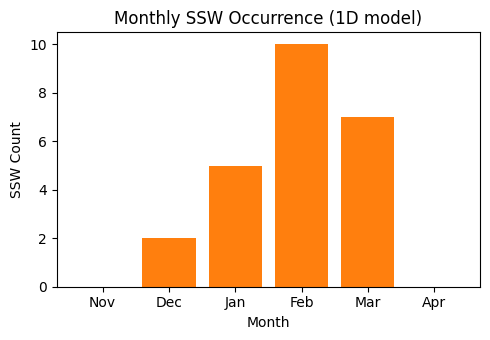

In [40]:
import matplotlib.pyplot as plt
months = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']
plt.figure(figsize=(5,3.5))
plt.bar(months, barplot,color='C1')
plt.xlabel('Month')
plt.ylabel('SSW Count')
plt.title('Monthly SSW Occurrence (1D model)')
plt.tight_layout()
plt.savefig('output/model_ssw.png', dpi=600, bbox_inches='tight')
plt.show()


total ssws amount: 22
####################################
1980/02/29/00
1981/12/04/00
1984/02/23/18
1984/12/31/18
1987/01/22/18
1987/12/08/00
1989/02/21/00
1998/12/15/06
1999/02/25/18
2001/02/11/06
2001/12/30/12
2004/01/04/18
2006/01/21/00
2007/02/24/00
2008/02/21/18
2009/01/24/06
2010/02/09/00
2013/01/06/12
2016/03/05/12
2018/02/11/18
2019/01/02/06
2021/01/05/00
####################################
barplot (11,12,01,02,03,04): [0. 5. 7. 9. 1. 0.]
total ssws amount: 22


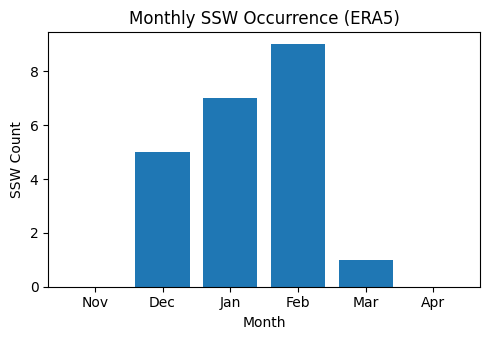

In [41]:
n_ssw_era, events_era, debug = count_ssw_events_from_ubar_legacy(
    ubp,
    n_per_year=dmax,
    years=years,
    dmax_ref=dmax,
    min_gap_days=10.0,
    min_gap_onset_days=20.0,
    min_duration_days=2.0,
    use_djf_only=False,
    exclude_onset_indices= None,  # 
    date_2d=date,                 # 
    enforce_march10_cutoff=True,  #  3  10 
    return_debug=True,
)
print("total ssws amount:", n_ssw_era)

# ===== 2.  =====

#  2D 
ueast = np.zeros((years, dmax))   # 
onset = np.zeros((years, dmax))
end   = np.zeros((years, dmax))
ssw   = np.zeros((years, dmax))

# 
onset_id = np.zeros(200)   #  200
end_id   = np.zeros(200)

#  barplot 11,12,01,02,03,04
barplot_era5 = np.zeros(6)

#  events (0-based  (start_idx, end_idx))  onset/onset_id/ssw 
for k, (s, e) in enumerate(events_era):
    # s,e  flatten 0..years*n_per_year-1
    #  (, )
    i_s = s // dmax   #  index
    j_s = s %  dmax   # 
    i_e = e // dmax
    j_e = e %  dmax

    # 
    onset[i_s, j_s] = 1
    end[i_e, j_e]   = 1

    #  1-based  onset_id / end_id
    #  while  t=1,2,... 
    if k+1 < onset_id.size:
        onset_id[k+1] = s + 1   # 1-based
    if k+1 < end_id.size:
        end_id[k+1]   = e + 1

    # =====  date[i][j]  barplot  =====
    cur_date = date[i_s][j_s]   # onset 
    mm = cur_date[5:7]          # 'YYYY-MM-DD' → 'MM'
    if   mm == '11':
        barplot_era5[0] += 1
    elif mm == '12':
        barplot_era5[1] += 1
    elif mm == '01':
        barplot_era5[2] += 1
    elif mm == '02':
        barplot_era5[3] += 1
    elif mm == '03':
        barplot_era5[4] += 1
    elif mm == '04':
        barplot_era5[5] += 1

    # =====  ssw[i,j] =====
    for tt in range(s, e+1):
        ii = tt // dmax
        jj = tt %  dmax
        ssw[ii, jj] = 1

# ===== 3.  =====

print('####################################')
#  onset 
for (s, e) in events_era:
    i_s = s // dmax
    j_s = s %  dmax
    print(date[i_s][j_s])

print('####################################')
print('barplot (11,12,01,02,03,04):', barplot_era5)
print('total ssws amount:', n_ssw_era)


import matplotlib.pyplot as plt
months = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']
plt.figure(figsize=(5,3.5))
plt.bar(months, barplot_era5)
plt.xlabel('Month')
plt.ylabel('SSW Count')
plt.title('Monthly SSW Occurrence (ERA5)')
plt.tight_layout()
plt.savefig('output/era_ssw.png', dpi=600, bbox_inches='tight')
plt.show()


1D model SSW count: 24
ERA5 SSW count: 22


/tmp/ipykernel_3248528/1430452927.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


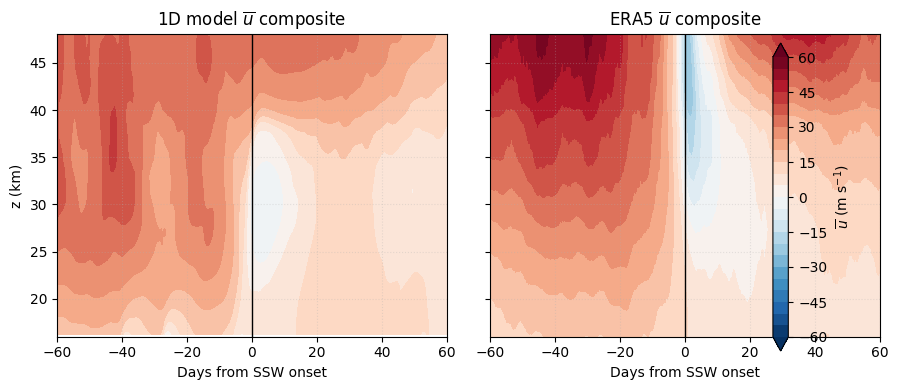

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1.  SSW
# =========================

years = 42
dmax  = 992          #  6-hourly Oct–May 
steps_per_day = 4.0  # 6-hourly

# # ---- 1D model SSW events ----
# n_ssw_mod, events_mod, debug_mod = count_ssw_events_from_ubar_legacy(
#     ubp_model,            # shape (years, dmax)
#     n_per_year=dmax,
#     years=years,
#     dmax_ref=dmax,
#     min_gap_days=10.0,
#     min_gap_onset_days=20.0,
#     min_duration_days=2.0,
#     use_djf_only=False,
#     exclude_onset_indices=None,
#     date_2d=date_model,
#     enforce_march10_cutoff=True,
#     return_debug=True,
# )

# # ---- ERA5 SSW events ----
# n_ssw_era, events_era, debug_era = count_ssw_events_from_ubar_legacy(
#     ubp,                  # shape (years, dmax)
#     n_per_year=dmax,
#     years=years,
#     dmax_ref=dmax,
#     min_gap_days=10.0,
#     min_gap_onset_days=20.0,
#     min_duration_days=2.0,
#     use_djf_only=False,
#     exclude_onset_indices=None,
#     date_2d=date,
#     enforce_march10_cutoff=True,
#     return_debug=True,
# )

print("1D model SSW count:", n_ssw_mod)
print("ERA5 SSW count:", n_ssw_era)

# =========================
# 2.  1D  (z, year, 320)  (z, year, 992)
# =========================

def interp_model_to_6hour(v_zyt, tgt_len=992):
    """
    v_zyt: shape = (nz, years, n_per_year_model)   (501, 42, 320)
    :  shape = (nz, years, tgt_len)           (501, 42, 992)
    """
    v_zyt = np.asarray(v_zyt)
    nz, ny, nt_src = v_zyt.shape

    src_x = np.arange(nt_src, dtype=float)
    tgt_x = np.linspace(0, nt_src - 1, tgt_len)

    v_out = np.empty((nz, ny, tgt_len), dtype=float)

    for iy in range(ny):
        for k in range(nz):
            v_out[k, iy, :] = np.interp(tgt_x, src_x, v_zyt[k, iy, :])

    return v_out

# ERA5:  Oct_to_May  (97, 42, 992)
ubar_era_zyt = ubar_eachyr             # (97, 42, 992)

# 1D model:  reshape
# ubar_eachyear = ubar.reshape((zdim, yr, 320))
ubar_mod_zyt_320 = ubar_eachyear       # (zdim, 42, 320)
ubar_mod_zyt     = interp_model_to_6hour(ubar_mod_zyt_320, tgt_len=dmax)   # (zdim, 42, 992)

# =========================
# 3.  SSW events ±60  composite
# =========================

def build_composite_60day(field_zyt, events, dmax, window_days=60, steps_per_day=4.0):
    """
    field_zyt: shape = (nz, years, dmax)
    events:    list of (start_idx, end_idx) in flattened index [0 .. years*dmax-1]
                start_idx  SSW onset
    :
      comp_mean: shape = (nz, nt_win)  compositent_win = 2*window_days*steps_per_day + 1
    """
    field_zyt = np.asarray(field_zyt)
    nz, years, nsteps = field_zyt.shape
    assert nsteps == dmax

    win = int(window_days * steps_per_day)
    nt  = 2 * win + 1
    n_events = len(events)

    comp = np.full((nz, n_events, nt), np.nan, dtype=float)

    for e_idx, (s, e) in enumerate(events):
        # s: flatten index -> (year_index, step_in_year)
        iy = s // dmax
        jy = s %  dmax

        for dt in range(-win, win+1):
            t_idx = jy + dt
            if t_idx < 0 or t_idx >= dmax:
                continue
            col = dt + win
            comp[:, e_idx, col] = field_zyt[:, iy, t_idx]

    comp_mean = np.nanmean(comp, axis=1)   # over events
    return comp_mean

ubar_mod_comp = build_composite_60day(
    ubar_mod_zyt, events_mod, dmax,
    window_days=60, steps_per_day=steps_per_day
)
ubar_era_comp = build_composite_60day(
    ubar_era_zyt, events_era, dmax,
    window_days=60, steps_per_day=steps_per_day
)

# =========================
# 4.  10–38 km  &  time 
# =========================

# time lag ()
win = int(60 * steps_per_day)
lags_days = np.arange(-win, win+1) / steps_per_day   # shape (nt,)

#  mask &  z
z_era_plot = (height / 1000.0)[era_z_mask]    # km
z_mod_plot = hhh[mod_z_mask]                 # km

ubar_era_comp_z = ubar_era_comp[era_z_mask, :]     # (Nz_era, nt)
ubar_mod_comp_z = ubar_mod_comp[mod_z_mask, :]     # (Nz_mod, nt)

#  colorbar 
vmax = max(np.nanmax(np.abs(ubar_era_comp_z)),
           np.nanmax(np.abs(ubar_mod_comp_z)))
vmax = float(np.ceil(vmax / 2.0) * 2.0)  #  2 m/s 
levels = np.linspace(-vmax, vmax, 25)

Tm_2d, Zm_2d = np.meshgrid(lags_days, z_mod_plot)
Te_2d, Ze_2d = np.meshgrid(lags_days, z_era_plot)

# =========================
# 5. 1D vs ERA5  (time,z) composite
# =========================

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

# ---- 1D model ----
cf0 = axes[0].contourf(Tm_2d, Zm_2d, ubar_mod_comp_z,
                       levels=levels, extend='both', cmap='RdBu_r')
axes[0].set_title('1D model $\overline{u}$ composite')
axes[0].set_xlabel('Days from SSW onset')
axes[0].set_ylabel('z (km)')
axes[0].set_xlim(-60, 60)
axes[0].grid(True, linestyle=':', alpha=0.3)

# ---- ERA5 ----
cf1 = axes[1].contourf(Te_2d, Ze_2d, ubar_era_comp_z,
                       levels=levels, extend='both', cmap='RdBu_r')
axes[1].set_title('ERA5 $\overline{u}$ composite')
axes[1].set_xlabel('Days from SSW onset')
axes[1].set_xlim(-60, 60)
axes[1].grid(True, linestyle=':', alpha=0.3)

#  colorbar
cbar = fig.colorbar(cf1, ax=axes.ravel().tolist(),
                    location='right', fraction=0.046, pad=0.02)
cbar.set_label(r'$\overline{u}$ (m s$^{-1}$)')

#  0 
for ax in axes:
    ax.axvline(0, color='k', linewidth=1)

plt.tight_layout()
plt.show()


/tmp/ipykernel_3248528/24638972.py:40: RuntimeWarning: Mean of empty slice
  comp_mean = np.nanmean(comp, axis=1)


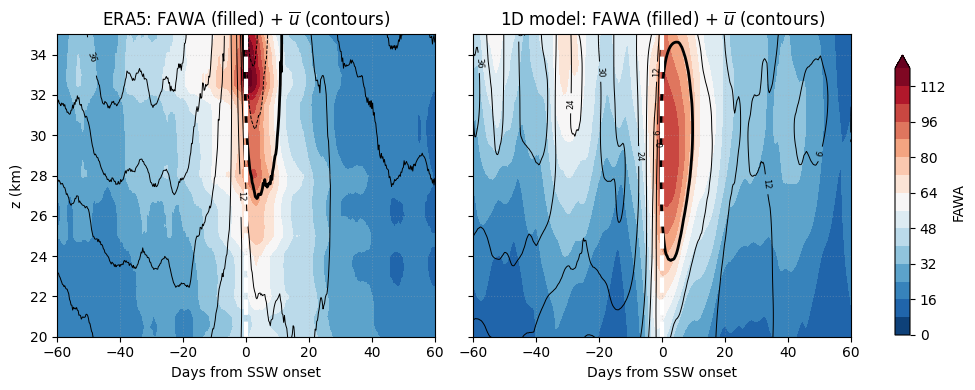

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# ========== 1.  FAWA  6-hourly  ==========
# ERA5Oct_to_May  (97, 42, 992)
fawa_era_zyt = fawa_eachyr   # (97, 42, 992)

# 1D (zdim, 42, 320) -> (zdim, 42, 992)
fawa_mod_zyt_320 = fawa_eachyear   #  reshape 
fawa_mod_zyt     = interp_model_to_6hour(fawa_mod_zyt_320, tgt_len=dmax)


# ========== 2.  ±60  composite a  u  ==========
def build_composite_60day(field_zyt, events, dmax, window_days=60, steps_per_day=4.0):
    """
    field_zyt: (nz, years, dmax)
    events:    list[(start_idx, end_idx)]flatten  index
    : comp_mean (nz, nt)nt = 2*window_days*steps_per_day + 1
    """
    field_zyt = np.asarray(field_zyt)
    nz, years, nsteps = field_zyt.shape
    assert nsteps == dmax

    win = int(window_days * steps_per_day)
    nt  = 2 * win + 1
    n_events = len(events)

    comp = np.full((nz, n_events, nt), np.nan)

    for e_idx, (s, e) in enumerate(events):
        iy = s // dmax
        jy = s %  dmax
        for dt in range(-win, win+1):
            t_idx = jy + dt
            if t_idx < 0 or t_idx >= dmax:
                continue
            col = dt + win
            comp[:, e_idx, col] = field_zyt[:, iy, t_idx]

    comp_mean = np.nanmean(comp, axis=1)
    return comp_mean

# ========== 3.  u  a  composite ==========
# ubar  ubar_mod_zyt / ubar_era_zyt build_composite_60day 
ubar_mod_comp = build_composite_60day(
    ubar_mod_zyt, events_mod, dmax,
    window_days=60, steps_per_day=steps_per_day
)
ubar_era_comp = build_composite_60day(
    ubar_era_zyt, events_era, dmax,
    window_days=60, steps_per_day=steps_per_day
)

fawa_mod_comp = build_composite_60day(
    fawa_mod_zyt, events_mod, dmax,
    window_days=60, steps_per_day=steps_per_day
)
fawa_era_comp = build_composite_60day(
    fawa_era_zyt, events_era, dmax,
    window_days=60, steps_per_day=steps_per_day
)

# ========== 4.  10–38 km &  ==========
win = int(60 * steps_per_day)
lags_days = np.arange(-win, win+1) / steps_per_day   # -60 ~ +60 

z_era_km = height / 1000.0
z_mod_km = hhh

z_era_plot = z_era_km[era_z_mask]
z_mod_plot = z_mod_km[mod_z_mask]

ubar_era_comp_z  = ubar_era_comp[era_z_mask, :]
ubar_mod_comp_z  = ubar_mod_comp[mod_z_mask, :]
fawa_era_comp_z  = fawa_era_comp[era_z_mask, :]
fawa_mod_comp_z  = fawa_mod_comp[mod_z_mask, :]

Tm_2d, Zm_2d = np.meshgrid(lags_days, z_mod_plot)
Te_2d, Ze_2d = np.meshgrid(lags_days, z_era_plot)

# ========== 5. a  contourfu  contour  ==========
# FAWA  0~max
amax = max(np.nanmax(np.abs(fawa_mod_comp_z)),
           np.nanmax(np.abs(fawa_era_comp_z)))
amax = 120 #float(np.ceil(amax / 5.0) * 5.0)   #  5 
a_levels = np.linspace(0, amax, 16)      #  -amax~amax

# u 
u_max = max(np.nanmax(np.abs(ubar_mod_comp_z)),
            np.nanmax(np.abs(ubar_era_comp_z)))
u_max = float(np.ceil(u_max / 5.0) * 5.0)
u_levels = np.arange(-u_max, u_max+1e-6, 6)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# ----- ERA5 -----
cf0 = axes[0].contourf(Te_2d, Ze_2d, fawa_era_comp_z,
                       levels=a_levels, extend='max', cmap='RdBu_r')
cs0 = axes[0].contour(Te_2d, Ze_2d, ubar_era_comp_z,
                      levels=u_levels, colors='k', linewidths=0.7)
axes[0].contour(Te_2d, Ze_2d, ubar_era_comp_z,
                levels=[0.0], colors='k', linewidths=2)

axes[0].clabel(cs0, fmt='%d', fontsize=6, inline=True)
axes[0].set_title('ERA5: FAWA (filled) + $\overline{u}$ (contours)')
axes[0].set_xlabel('Days from SSW onset')
axes[0].set_ylabel('z (km)')
axes[0].set_xlim(-60, 60)
axes[0].set_ylim(20, 35)
axes[0].grid(True, linestyle=':', alpha=0.3)
axes[0].axvline(0, color='k', linewidth=3,c='white',linestyle='--')

# ----- 1D model -----
cf1 = axes[1].contourf(Tm_2d, Zm_2d, fawa_mod_comp_z,
                       levels=a_levels, extend='max', cmap='RdBu_r')
cs1 = axes[1].contour(Tm_2d, Zm_2d, ubar_mod_comp_z,
                      levels=u_levels, colors='k', linewidths=0.7)
axes[1].contour(Tm_2d, Zm_2d, ubar_mod_comp_z,
                levels=[0.0], colors='k', linewidths=2)

axes[1].clabel(cs1, fmt='%d', fontsize=6, inline=True)
axes[1].set_title('1D model: FAWA (filled) + $\overline{u}$ (contours)')
axes[1].set_xlabel('Days from SSW onset')
axes[1].set_xlim(-60, 60)
axes[1].grid(True, linestyle=':', alpha=0.3)
axes[1].axvline(0, color='k', linewidth=3,c='white',linestyle='--')

# =========  =========
#  10% 
fig.tight_layout(rect=[0, 0, 0.88, 1])

#  colorbar  figure 
cax = fig.add_axes([0.90, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(cf1, cax=cax)
cbar.set_label('FAWA')
# =========  =========

plt.show()


/tmp/ipykernel_3248528/2273474262.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


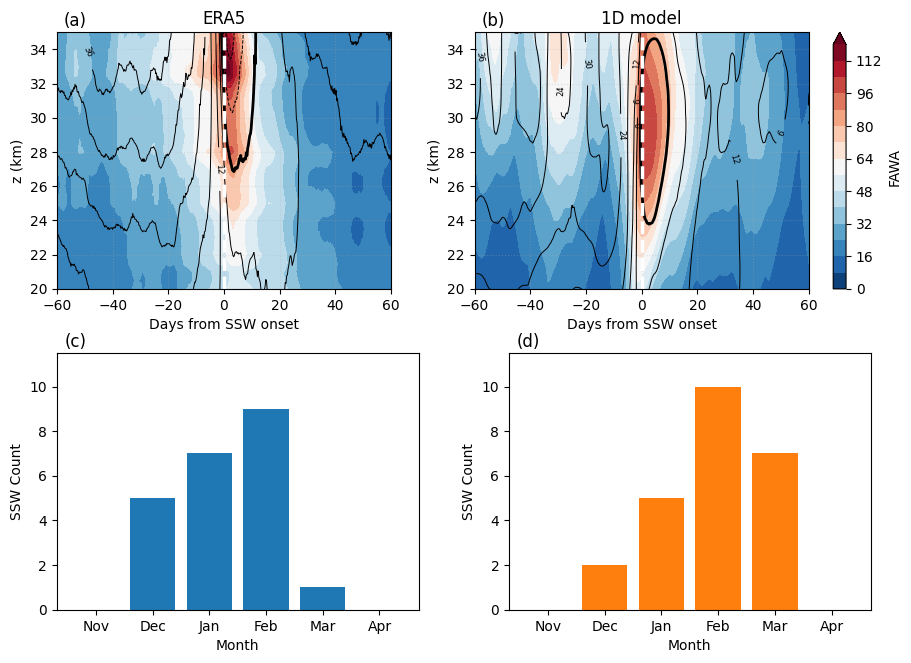

In [44]:
import numpy as np
import matplotlib.pyplot as plt

u_levels = np.arange(-u_max, u_max+1e-6, 6)

# -----------------------------
# 0) Figure layout (2x2)
# -----------------------------
fig, axes = plt.subplots(
    2, 2, figsize=(10.5, 7.5),
    gridspec_kw={"height_ratios": [1.0, 1.0], "hspace": 0.25, "wspace": 0.25}
)

# convenience
ax_cmp_era = axes[0, 0]
ax_cmp_mod = axes[0, 1]
#  c  d 
ax_bar_era = axes[1, 0]
ax_bar_mod = axes[1, 1]

# -----------------------------
# 1) Top row: composites
# -----------------------------
# ----- (a) ERA5 composite -----
cf0 = ax_cmp_era.contourf(
    Te_2d, Ze_2d, fawa_era_comp_z,
    levels=a_levels, extend="max", cmap="RdBu_r"
)
cs0 = ax_cmp_era.contour(
    Te_2d, Ze_2d, ubar_era_comp_z,
    levels=u_levels, colors="k", linewidths=0.7
)
ax_cmp_era.contour(
    Te_2d, Ze_2d, ubar_era_comp_z,
    levels=[0.0], colors="k", linewidths=2
)
ax_cmp_era.clabel(cs0, fmt="%d", fontsize=6, inline=True)
ax_cmp_era.set_title(r"ERA5")
#ax_cmp_era.set_title(r"ERA5: FAWA (filled) + $\overline{u}$ (contours)")
ax_cmp_era.set_xlabel("Days from SSW onset")
ax_cmp_era.set_ylabel("z (km)")
ax_cmp_era.set_xlim(-60, 60)
ax_cmp_era.set_ylim(20, 35)
ax_cmp_era.grid(True, linestyle=":", alpha=0.3)
ax_cmp_era.axvline(0, color="white", linewidth=2.5, linestyle="--")

# ----- (b) 1D model composite -----
cf1 = ax_cmp_mod.contourf(
    Tm_2d, Zm_2d, fawa_mod_comp_z,
    levels=a_levels, extend="max", cmap="RdBu_r"
)
cs1 = ax_cmp_mod.contour(
    Tm_2d, Zm_2d, ubar_mod_comp_z,
    levels=u_levels, colors="k", linewidths=0.7
)
ax_cmp_mod.contour(
    Tm_2d, Zm_2d, ubar_mod_comp_z,
    levels=[0.0], colors="k", linewidths=2
)
ax_cmp_mod.clabel(cs1, fmt="%d", fontsize=6, inline=True)
ax_cmp_mod.set_title(r"1D model")
ax_cmp_mod.set_xlabel("Days from SSW onset")
ax_cmp_mod.set_ylabel("z (km)")  #  y-label
ax_cmp_mod.set_xlim(-60, 60)
ax_cmp_mod.set_ylim(20, 35)
ax_cmp_mod.grid(True, linestyle=":", alpha=0.3)
ax_cmp_mod.axvline(0, color="white", linewidth=2.5, linestyle="--")

# -----------------------------
# 2) Bottom row: monthly bar charts
# -----------------------------
# (c) ERA5 bar
months = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']
ax_bar_era.bar(months, barplot_era5, color="C0")
ax_bar_era.set_xlabel("Month")
ax_bar_era.set_ylabel("SSW Count")
#ax_bar_era.set_title("Monthly SSW Occurrence (ERA5)")

# (d) 1D model bar
ax_bar_mod.bar(months, barplot, color="C1")
ax_bar_mod.set_xlabel("Month")
ax_bar_mod.set_ylabel("SSW Count")
#ax_bar_mod.set_title("Monthly SSW Occurrence (1D model)")

# optional: unify y-limit for fair comparison
ymax = max(np.max(barplot), np.max(barplot_era5))
ax_bar_mod.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)
ax_bar_era.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)

# -----------------------------
# 3) Shared colorbar for top row composites
# -----------------------------
cbar = fig.colorbar(cf1, ax=[ax_cmp_era, ax_cmp_mod], fraction=0.046, pad=0.03)
cbar.set_label("FAWA")

# -----------------------------
# 4) Panel labels (a)(b)(c)(d) — optional but paper-friendly
# -----------------------------
labels = ["(a)", "(b)", "(c)", "(d)"]
# ax_cmp_era, ax_cmp_mod, ax_bar_era, ax_bar_mod
for lab, ax in zip(labels, [ax_cmp_era, ax_cmp_mod, ax_bar_era, ax_bar_mod]):
    ax.text(0.02, 1.08, lab, transform=ax.transAxes,
            ha="left", va="top", fontsize=12)

plt.tight_layout()
plt.show()


/tmp/ipykernel_3248528/2318915885.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


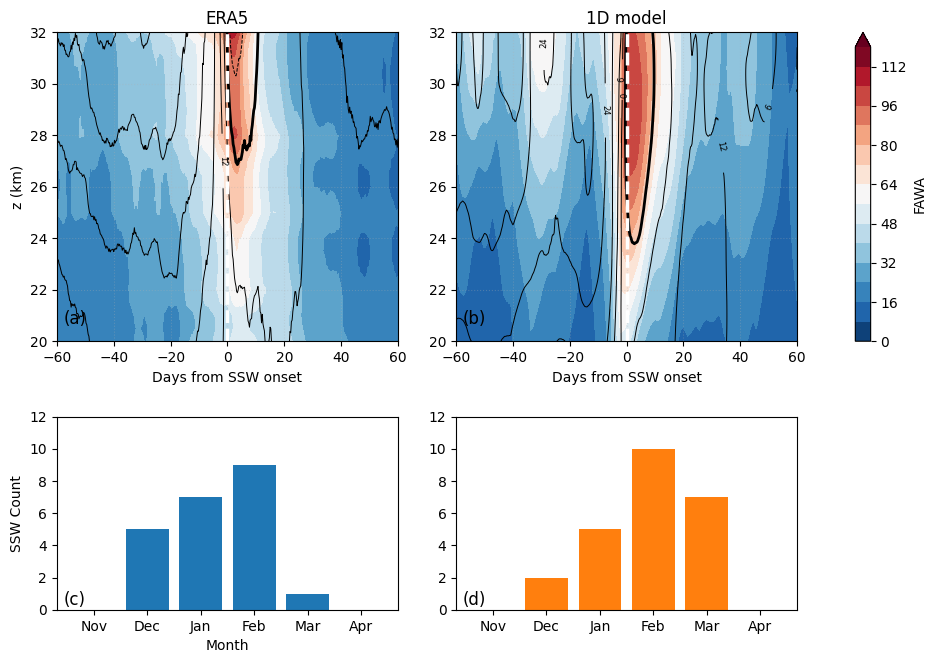

In [45]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10.5, 7.5))
gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, 0.045],   #  colorbar
    height_ratios=[1.6, 1.0],
    wspace=0.25, hspace=0.30
)

# 
ax00 = fig.add_subplot(gs[0, 0])  # ERA5 composite
ax01 = fig.add_subplot(gs[0, 1])  # 1D composite
ax10 = fig.add_subplot(gs[1, 0])  # bar (ERA5)
ax11 = fig.add_subplot(gs[1, 1])  # bar (1D)

# colorbar 
cax  = fig.add_subplot(gs[0, 2])
# 
ax_empty = fig.add_subplot(gs[1, 2])
ax_empty.axis("off")

# ======  ======
# composite axes[0]/axes[1]  ax00/ax01
cf0 = ax00.contourf(Te_2d, Ze_2d, fawa_era_comp_z, levels=a_levels, extend='max', cmap='RdBu_r')
cs0 = ax00.contour (Te_2d, Ze_2d, ubar_era_comp_z, levels=u_levels, colors='k', linewidths=0.7)
# cf0 = ax00.contourf(Te_2d, Ze_2d, ubar_era_comp_z, levels=u_levels, extend='max', cmap='RdBu_r')
# cs0 = ax00.contour (Te_2d, Ze_2d, fawa_era_comp_z, levels=a_levels, colors='k', linewidths=0.7)
ax00.contour(Te_2d, Ze_2d, ubar_era_comp_z, levels=[0.0], colors='k', linewidths=2)
ax00.clabel(cs0, fmt='%d', fontsize=6, inline=True)
ax00.set_title("ERA5")
ax00.set_xlabel("Days from SSW onset")
ax00.set_ylabel("z (km)")
ax00.set_xlim(-60, 60); ax00.set_ylim(20, 32)
ax00.grid(True, linestyle=':', alpha=0.3)
ax00.axvline(0, color='white', linewidth=2.5, linestyle='--')

cf1 = ax01.contourf(Tm_2d, Zm_2d, fawa_mod_comp_z, levels=a_levels, extend='max', cmap='RdBu_r')
cs1 = ax01.contour (Tm_2d, Zm_2d, ubar_mod_comp_z, levels=u_levels, colors='k', linewidths=0.7)
# cf1 = ax01.contourf(Tm_2d, Zm_2d, ubar_mod_comp_z, levels=u_levels, extend='max', cmap='RdBu_r')
# cs1 = ax01.contour (Tm_2d, Zm_2d, fawa_mod_comp_z, levels=a_levels, colors='k', linewidths=0.7)
ax01.contour(Tm_2d, Zm_2d, ubar_mod_comp_z, levels=[0.0], colors='k', linewidths=2)
ax01.clabel(cs1, fmt='%d', fontsize=6, inline=True)
ax01.set_title("1D model")
ax01.set_xlabel("Days from SSW onset")
ax01.set_xlim(-60, 60); ax01.set_ylim(20, 32)
ax01.grid(True, linestyle=':', alpha=0.3)
ax01.axvline(0, color='white', linewidth=2.5, linestyle='--')

# colorbar cf1  cf0 levels 
cbar = fig.colorbar(cf1, cax=cax)
cbar.set_label("FAWA")

# bar axes[0,0]/[0,1]  ax10/ax11
ax10.bar(months, barplot_era5, color='C0')
ax10.set_xlabel("Month"); ax10.set_ylabel("SSW Count")
ax10.set_ylim(0,12)
ax10.set_title("")  # 

ax11.bar(months, barplot, color='C1')
#ax11.set_xlabel("Month"); ax11.set_ylabel("SSW Count")
ax11.set_ylim(0,12)
ax11.set_title("")

#  (a) (b) (c) (d)
labels = ["(a)", "(b)", "(c)", "(d)"]
for lab, ax in zip(labels, [ax00, ax01, ax10, ax11]):
    ax.text(0.02, 0.1, lab, transform=ax.transAxes,
            ha="left", va="top", fontsize=12)

plt.tight_layout()
plot.savefig('output/fig_ssw_composite_era5_mod.png', dpi=600, bbox_inches='tight')
plt.show()


1D level ~32km: 31.956087824351297 km (index 110 )
ERA5 level ~32km: 32.0 km (index 64 )


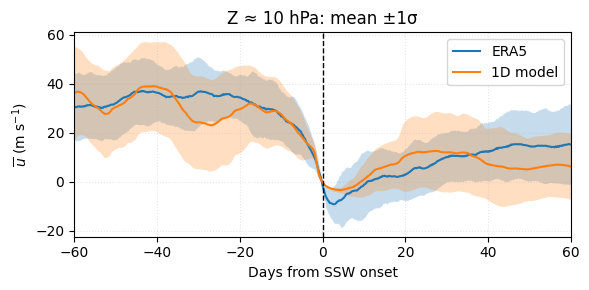

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# ========== 1.  32 km  ==========
z_target = 32.0  # km

z_era_km = height / 1000.0   # ERA5 
z_mod_km = hhh               # 1D  km

k_mod = int(np.argmin(np.abs(z_mod_km - z_target)))   # 1D index
k_era = int(np.argmin(np.abs(z_era_km - z_target)))   # ERA5 index

print("1D level ~32km:", z_mod_km[k_mod], "km (index", k_mod, ")")
print("ERA5 level ~32km:", z_era_km[k_era], "km (index", k_era, ")")

# ========== 2.  ±60  composite ==========
def build_level_composite(field_zyt, level_idx, events,
                          dmax, window_days=60, steps_per_day=4.0):
    """
    field_zyt: (nz, years, dmax)
    level_idx:  index
    events:    list[(start_idx, end_idx)]flatten  index
    :
      mean: (nt,), std: (nt,), nt = 2*window_days*steps_per_day + 1
    """
    field_zyt = np.asarray(field_zyt)
    nz, years, nsteps = field_zyt.shape
    assert nsteps == dmax

    win = int(window_days * steps_per_day)
    nt  = 2 * win + 1
    n_events = len(events)

    comp = np.full((n_events, nt), np.nan)

    for e_idx, (s, e) in enumerate(events):
        iy = s // dmax
        jy = s %  dmax
        for dt in range(-win, win+1):
            t_idx = jy + dt
            if t_idx < 0 or t_idx >= dmax:
                continue
            col = dt + win
            comp[e_idx, col] = field_zyt[level_idx, iy, t_idx]

    mean = np.nanmean(comp, axis=0)
    std  = np.nanstd(comp, axis=0)
    return mean, std

u_mod_mean, u_mod_std = build_level_composite(
    ubar_mod_zyt, k_mod, events_mod,
    dmax=dmax, window_days=60, steps_per_day=steps_per_day
)
u_era_mean, u_era_std = build_level_composite(
    ubar_era_zyt, k_era, events_era,
    dmax=dmax, window_days=60, steps_per_day=steps_per_day
)

# ========== 3. -60 ~ +60  ==========
win = int(60 * steps_per_day)
lags_days = np.arange(-win, win+1) / steps_per_day   # (nt,)

# ========== 4.  line +  error bar ==========
fig, ax = plt.subplots(figsize=(6, 3))

# ERA5
ax.plot(lags_days, u_era_mean, label='ERA5', color='C0')
ax.fill_between(lags_days,
                u_era_mean - u_era_std,
                u_era_mean + u_era_std,
                color='C0', alpha=0.25, linewidth=0)

# 1D model
ax.plot(lags_days, u_mod_mean, label='1D model', color='C1')
ax.fill_between(lags_days,
                u_mod_mean - u_mod_std,
                u_mod_mean + u_mod_std,
                color='C1', alpha=0.25, linewidth=0)

ax.axvline(0, color='k', linestyle='--', linewidth=1)  # SSW onset
ax.set_xlim(-60, 60)

ax.set_xlabel('Days from SSW onset')
ax.set_ylabel(r'$\overline{u}$ (m s$^{-1}$)')
ax.set_title(f'Z ≈ 10 hPa: mean ±1σ')

ax.grid(True, linestyle=':', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


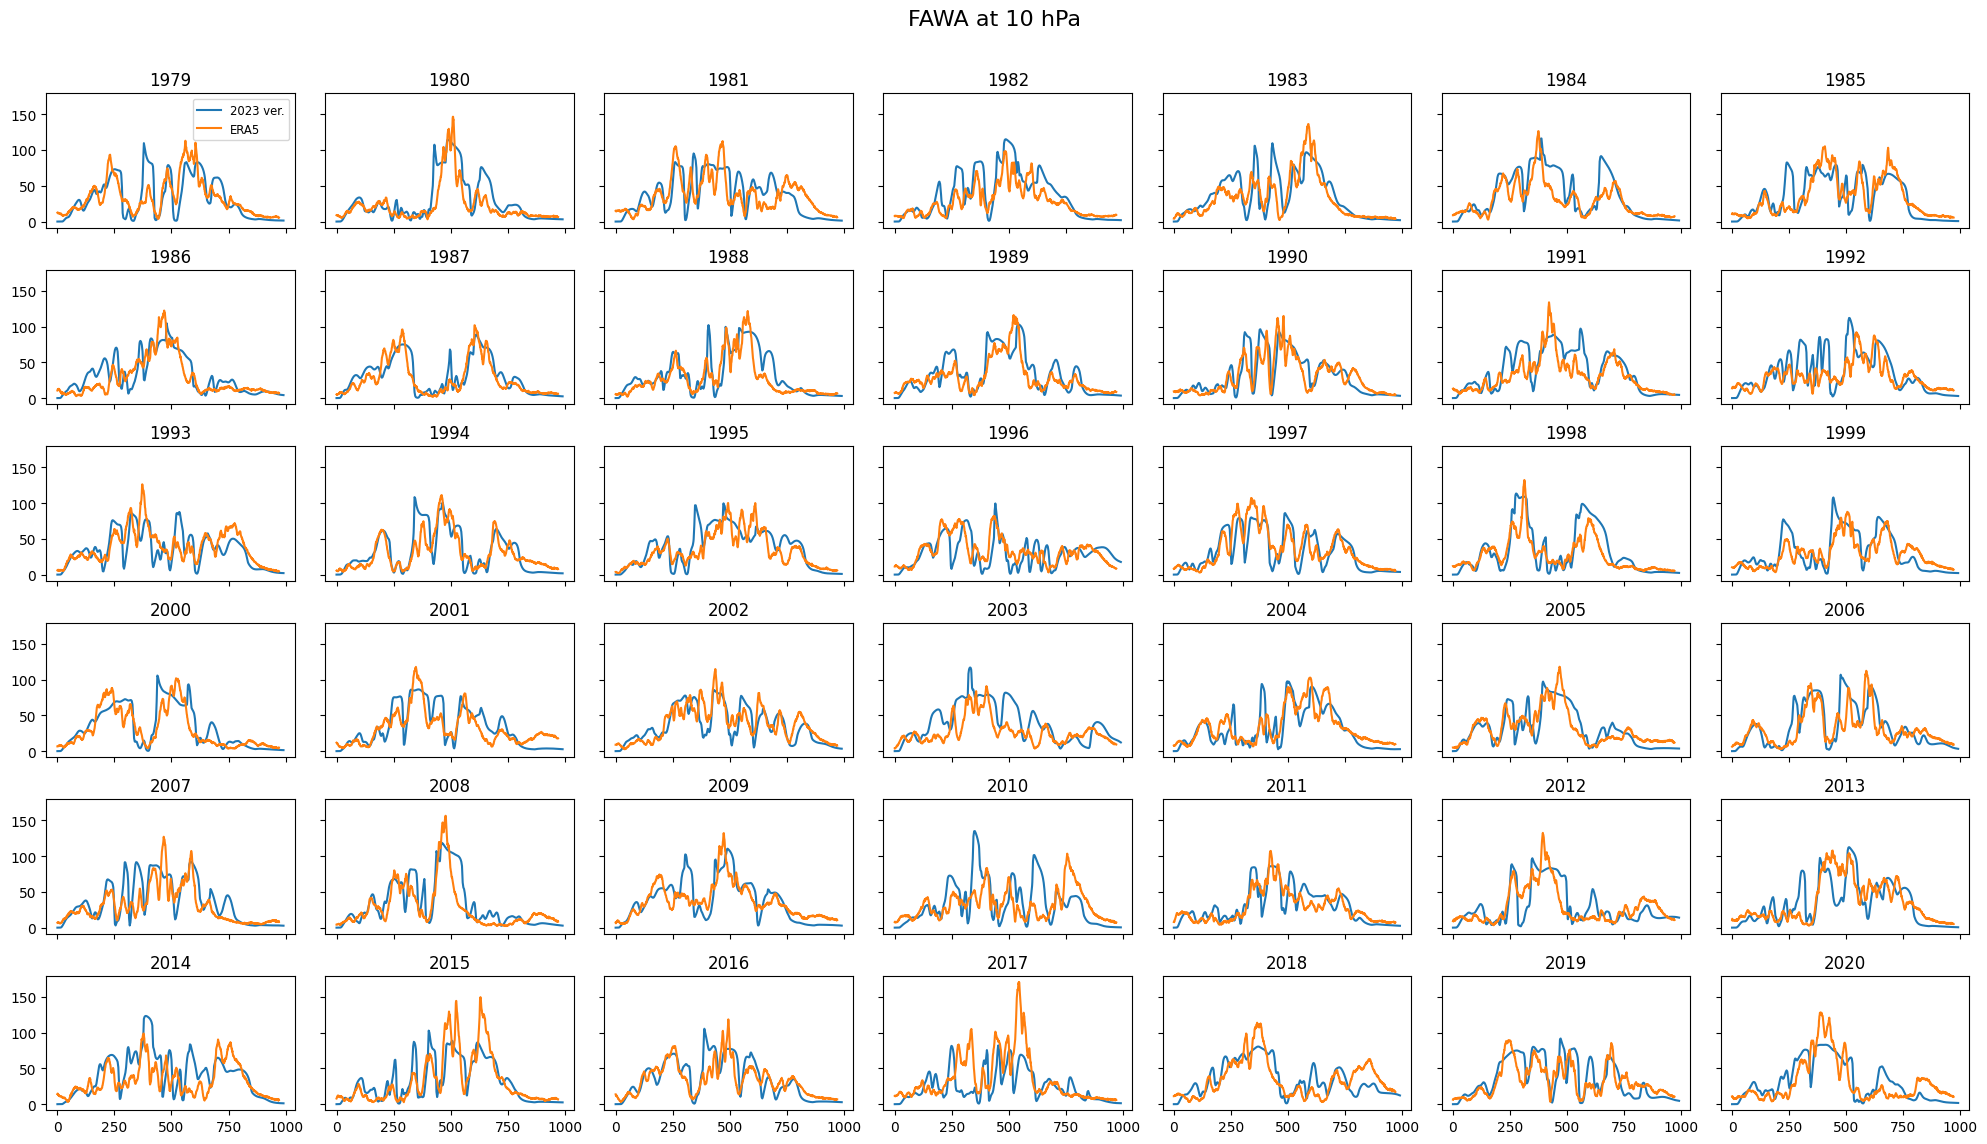

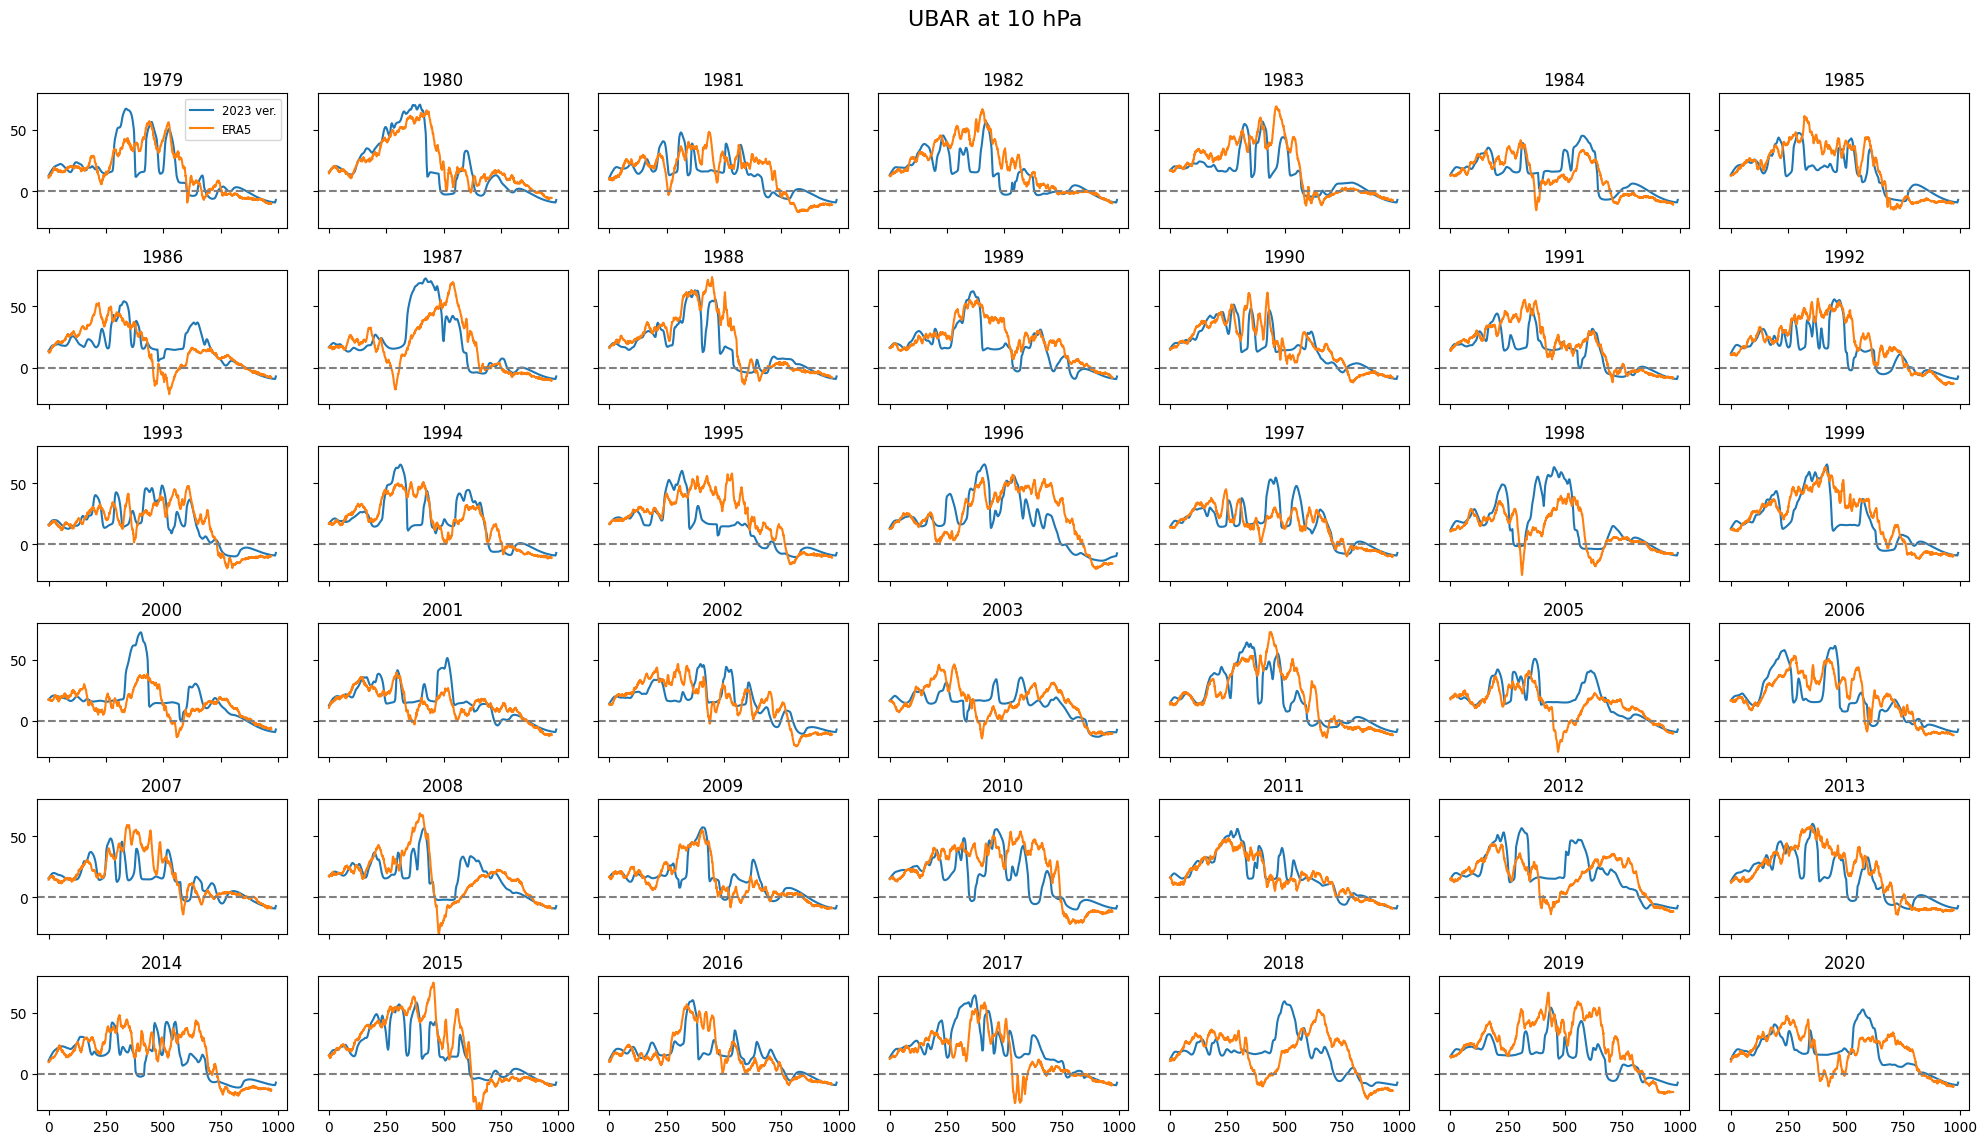

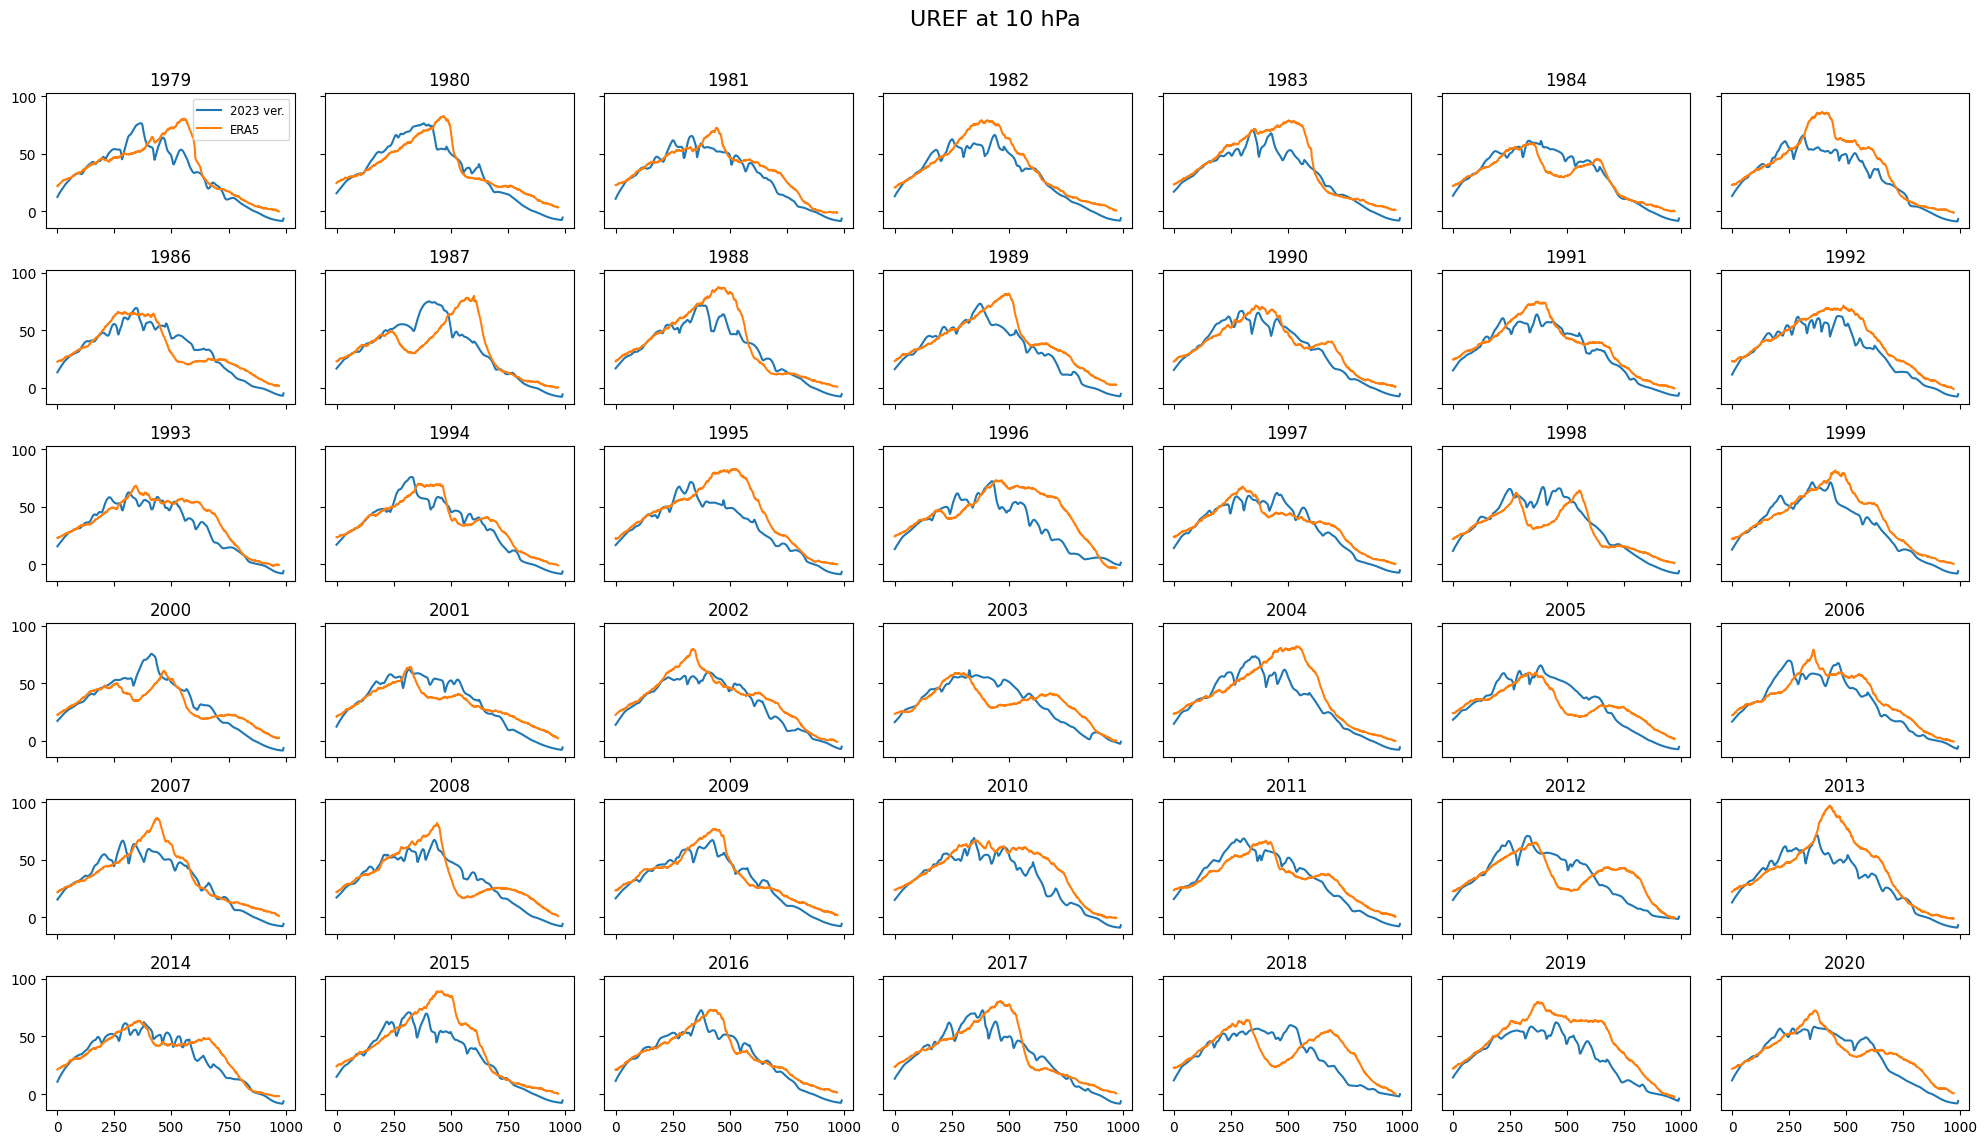

In [47]:
from scipy.interpolate import interp1d

# Assume the last dimension of *_eachyear is the one to interpolate (e.g., 320 -> 992)
target_len = 992

# --- FAWA ---
orig_len_fawa = fawa_eachyear.shape[2]
x_orig_fawa = np.linspace(0, 1, orig_len_fawa)
x_new = np.linspace(0, 1, target_len)

fig, axes = plot.subplots(6, 7, figsize=(20,12), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(yr):
    interp_func = interp1d(x_orig_fawa, fawa_eachyear[110, i, :], kind='linear')
    fawa_interp = interp_func(x_new)
    ax = axes[i]
    ax.plot(fawa_interp, label='2023 ver.')
    ax.plot(fawa_eachyr[64, i, :], label='ERA5')
    ax.set_title(f'{1979+i}')
    if i == 0:
        ax.legend(fontsize='small')
for j in range(yr, len(axes)):
    axes[j].axis('off')
fig.suptitle('FAWA at 10 hPa', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plot.show()

# --- UBAR ---
orig_len_ubar = ubar_eachyear.shape[2]
x_orig_ubar = np.linspace(0, 1, orig_len_ubar)
# x_new is already defined above

fig, axes = plot.subplots(6, 7, figsize=(20,12), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(yr):
    interp_func = interp1d(x_orig_ubar, ubar_eachyear[110, i, :], kind='linear')
    ubar_interp = interp_func(x_new)
    ax = axes[i]
    ax.plot(ubar_interp, label='2023 ver.')
    ax.plot(ubar_eachyr[64, i, :], label='ERA5')
    ax.axhline(0, linestyle='--', color='gray')
    ax.set_ylim(-30, 80)
    ax.set_title(f'{1979+i}')
    if i == 0:
        ax.legend(fontsize='small')
for j in range(yr, len(axes)):
    axes[j].axis('off')
fig.suptitle('UBAR at 10 hPa', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plot.show()

# --- UREF ---
orig_len_uref = uref_eachyear.shape[2]
x_orig_uref = np.linspace(0, 1, orig_len_uref)
# x_new is already defined above

fig, axes = plot.subplots(6, 7, figsize=(20,12), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(yr):
    interp_func = interp1d(x_orig_uref, uref_eachyear[110, i, :], kind='linear')
    uref_interp = interp_func(x_new)
    ax = axes[i]
    ax.plot(uref_interp, label='2023 ver.')
    ax.plot(uref_eachyr[64, i, :], label='ERA5')
    ax.set_title(f'{1979+i}')
    if i == 0:
        ax.legend(fontsize='small')
for j in range(yr, len(axes)):
    axes[j].axis('off')
fig.suptitle('UREF at 10 hPa', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plot.show()

In [48]:
import numpy as np

def events_to_calendar_year_pairs(events, date_2d, dmax=992, which="onset"):
    """
    events: list of (s,e) global 0-based
    date_2d: shape (years, dmax), strings like 'YYYY-MM-DD...'
    which: 'onset' use s, 'end' use e
    return:
      year_to_pairs: {YYYY: [(iy, j), ...]}   # calendar-year grouping
      records: list of dict for debugging
    """
    date_2d = np.asarray(date_2d)
    assert date_2d.shape[1] == dmax, f"date_2d second dim {date_2d.shape[1]} != dmax {dmax}"

    year_to_pairs = {}
    records = []

    for k, (s, e) in enumerate(events):
        s = int(s); e = int(e)
        t = s if which == "onset" else e
        iy, j = divmod(t, dmax)

        dstr = str(date_2d[iy, j])      # 'YYYY-MM-DD...'
        yy   = int(dstr[0:4])           # calendar year
        mm   = int(dstr[5:7])

        year_to_pairs.setdefault(yy, []).append((iy, j))

        records.append({
            "event_id": k,
            "iy": iy, "j": j,
            "date": dstr[:10],
            "year": yy, "month": mm,
            "s": s, "e": e
        })

    for yy in year_to_pairs:
        year_to_pairs[yy] = sorted(year_to_pairs[yy])

    return year_to_pairs, records


dmax = 992

year_to_pairs_era, rec_era = events_to_calendar_year_pairs(events_era, date_2d=date, dmax=dmax, which="onset")
year_to_pairs_mod, rec_mod = events_to_calendar_year_pairs(events_mod, date_2d=date, dmax=dmax, which="onset")

years_to_pick = [1998, 1999, 2009]

print("=== ERA5 (calendar-year) ===")
for y in years_to_pick:
    print(y, year_to_pairs_era.get(y, []))

print("\n=== 1D (calendar-year) ===")
for y in years_to_pick:
    print(y, year_to_pairs_mod.get(y, []))



=== ERA5 (calendar-year) ===
1998 [(19, 301)]
1999 [(19, 591)]
2009 [(29, 461)]

=== 1D (calendar-year) ===
1998 [(19, 277)]
1999 [(19, 564)]
2009 [(29, 462)]


In [49]:
# from scipy.interpolate import interp1d

# # Only plot for 1999 and 2009
# years_to_plot = [1999, 2009]
# indices_to_plot = [y - 1979 for y in years_to_plot]  # 0-based index

# target_len = 992
# x_new = np.linspace(0, 1, target_len)

# # Update these with your SSW event indices (relative to time axis of each year, after interpolation if necessary)
# # These are EXAMPLES, replace with correct day indices:
# # ssw_indices_1d = {1999: [120], 2009: [110]}
# # ssw_indices_era5 = {1999: [128], 2009: [117]}
# ssw_indices_era5 = ssw_era_jan
# ssw_indices_1d   = 393 #ssw_mod_jan


# # --- Plot as 2x2: left: UBAR, right: wave activity (A/FAWA). Row 0=1999, Row 1=2009 ---
# fig, axes = plot.subplots(2, 2, figsize=(12, 10), sharex=True)

# for row, iyr in enumerate(indices_to_plot):
#     year = 1979 + iyr
#     # UBAR
#     orig_len_ubar = ubar_eachyear.shape[2]
#     x_orig_ubar = np.linspace(0, 1, orig_len_ubar)
#     interp_func_ubar = interp1d(x_orig_ubar, ubar_eachyear[110, iyr, :], kind='linear')
#     ubar_interp = interp_func_ubar(x_new)
#     axu = axes[row, 0]
#     axu.plot(ubar_interp, label='1D model')
#     axu.plot(ubar_eachyr[64, iyr, :], label='ERA5')
#     axu.axhline(0, linestyle='--', color='gray')
#     axu.set_ylim(-30, 80)
#     axu.set_title(f'{year} UBAR')
#     # Mark SSW events (1D model in blue, ERA5 in orange/red)
#     for ssw_idx in ssw_indices_1d[year]:
#         axu.axvline(ssw_idx, color='b', linestyle=':', alpha=0.7, label='SSW 1D' if ssw_idx == ssw_indices_1d[year][0] else '')
#     for ssw_idx in ssw_indices_era5[year]:
#         axu.axvline(ssw_idx, color='orange', linestyle=':', alpha=0.7, label='SSW ERA5' if ssw_idx == ssw_indices_era5[year][0] else '')
#     if row == 0:
#         axu.legend(fontsize='small')

#     # Wave activity (FAWA)
#     orig_len_fawa = fawa_eachyear.shape[2]
#     x_orig_fawa = np.linspace(0, 1, orig_len_fawa)
#     interp_func_fawa = interp1d(x_orig_fawa, fawa_eachyear[110, iyr, :], kind='linear')
#     fawa_interp = interp_func_fawa(x_new)
#     axa = axes[row, 1]
#     axa.plot(fawa_interp, label='1D model')
#     axa.plot(fawa_eachyr[64, iyr, :], label='ERA5')
#     axa.set_title(f'{year} Wave Activity')
#     if row == 0:
#         axa.legend(fontsize='small')

# for ax in axes[:, 0]:
#     ax.set_ylabel('UBAR (m/s)')
# for ax in axes[:, 1]:
#     ax.set_ylabel('Wave activity (FAWA units)')
# axes[-1, 0].set_xlabel('Day of season index')
# axes[-1, 1].set_xlabel('Day of season index')

# fig.suptitle('UBAR and Wave Activity at 10 hPa for 1999 and 2009\n(SSW events marked)', fontsize=15)
# fig.tight_layout(rect=[0, 0.03, 1, 0.95])
# plot.show()

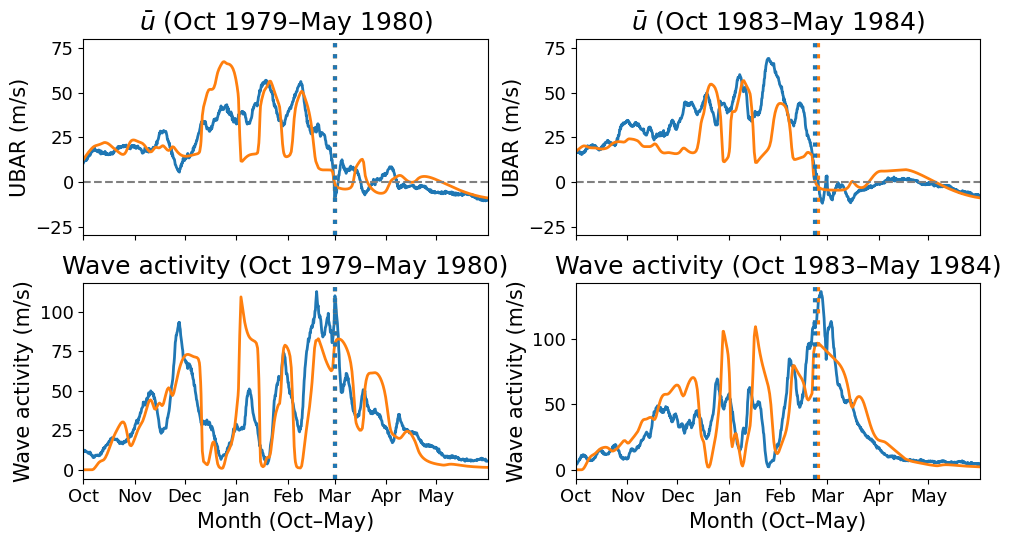

In [50]:
import numpy as np
import matplotlib.pyplot as plot
from scipy.interpolate import interp1d

# =========================
# 0) 
# =========================
years_to_plot = [1980, 1984]  # [2009, 2018]
target_len = 992
x_new = np.linspace(0, 1, target_len)

# =========================
# 1)  winter block index (iyr)
#    1999 -> winter block: 1998-10..1999-05 => iyr = (1999-1)-1979
# =========================
indices_to_plot = [(y - 1) - 1979 for y in years_to_plot]  # 0-based winter-block index

# =========================
# 2)  events + date_2d   winter block YYYY  onset indices
# =========================
def build_season_year_onset_index(events, date_2d, dmax=992):
    """
    return dict: key=(iy, calendar_year) -> sorted list of j indices (0..dmax-1)
     calendar_year  onset  YYYY 1998-12  1999 
    """
    date_2d = np.asarray(date_2d)
    assert date_2d.shape[1] == dmax, f"date_2d second dim={date_2d.shape[1]} != dmax={dmax}"

    out = {}
    for (s, e) in events:
        s = int(s)
        iy, j = divmod(s, dmax)
        dstr = str(date_2d[iy, j])   # 'YYYY-MM-DD...'
        yy = int(dstr[0:4])          # calendar year from onset date

        out.setdefault((iy, yy), []).append(j)

    for k in out:
        out[k] = sorted(out[k])
    return out

#  date  (years, 992)  events_*  time axis
#  ERA5  1D  date date_2d
season_year_era = build_season_year_onset_index(events_era, date_2d=date, dmax=target_len)
season_year_mod = build_season_year_onset_index(events_mod, date_2d=date, dmax=target_len)

# =========================
# 3)  x  ticks/labels and positions
# =========================
months = ["Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May"]
#  index calendar 
#  (10=31, 11=30, 12=31, 1=31, 2=28, 3=31, 4=30, 5=31) 243*4=972, 20
days_in_month = [31, 30, 31, 31, 28, 31, 30, 31]
cum_days = np.cumsum([0] + days_in_month)  # 0, 31, 61, ...
ticks = []
labels = []
for i, m in enumerate(months):
    ticks.append(cum_days[i]*4)
    labels.append(m)
# tickslabels992
if ticks[-1] > target_len:
    ticks = np.linspace(0, target_len - 1, len(months), dtype=int).tolist()

# =========================
# 4) 
# =========================
BIGFONT = 18
MIDFONT = 15
SMFONT = 13

# ====== : ubara(fawa) ======
fig, axes = plot.subplots(2, 2, figsize=(10, 6), sharex=True)

for col, (cal_year, iyr) in enumerate(zip(years_to_plot, indices_to_plot)):
    start_year = 1979 + iyr

    # ------  ubar ------
    axu = axes[0, col]
    orig_len_ubar = ubar_eachyear.shape[2]
    x_orig_ubar = np.linspace(0, 1, orig_len_ubar)
    ubar_interp = interp1d(x_orig_ubar, ubar_eachyear[110, iyr, :], kind='linear')(x_new)
    # ERAmodel
    axu.plot(ubar_eachyr[64, iyr, :], label='ERA5', linewidth=2)
    axu.plot(ubar_interp, label='1D model', linewidth=2)
    axu.axhline(0, linestyle='--', color='gray')
    axu.set_ylim(-30, 80)
    axu.set_title(f'$\\bar{{u}}$ (Oct {cal_year-1}–May {cal_year})', fontsize=BIGFONT)

    # ---- onset index  ----
    mod_onsets = season_year_mod.get((iyr, cal_year), [])
    era_onsets = season_year_era.get((iyr, cal_year), [])
    # ERA
    for ssw_idx in era_onsets:
        axu.axvline(ssw_idx, color='C1', linestyle=':', alpha=1, linewidth=3)
    for ssw_idx in mod_onsets:
        axu.axvline(ssw_idx, color='C0', linestyle=':', alpha=1, linewidth=3)

    # ------  fawa ------
    axa = axes[1, col]
    axa.set_xlim(0, 972)
    orig_len_fawa = fawa_eachyear.shape[2]
    x_orig_fawa = np.linspace(0, 1, orig_len_fawa)
    fawa_interp = interp1d(x_orig_fawa, fawa_eachyear[110, iyr, :], kind='linear')(x_new)
    # ERAmodel
    axa.plot(fawa_eachyr[64, iyr, :], label='ERA5', linewidth=2)
    axa.plot(fawa_interp, label='1D model', linewidth=2)
    axa.set_title(f'Wave activity (Oct {cal_year-1}–May {cal_year})', fontsize=BIGFONT)
    # ERA
    for ssw_idx in era_onsets:
        axa.axvline(ssw_idx, color='C1', linestyle=':', alpha=1, linewidth=3)
    for ssw_idx in mod_onsets:
        axa.axvline(ssw_idx, color='C0', linestyle=':', alpha=1, linewidth=3)

# Y
for ax in axes[0, :]:
    ax.set_ylabel('UBAR (m/s)', fontsize=MIDFONT)
for ax in axes[1, :]:
    ax.set_ylabel('Wave activity (m/s)', fontsize=MIDFONT)

# x: 
for ax in axes[1, :]:
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, fontsize=SMFONT)
    ax.set_xlabel('Month (Oct–May)', fontsize=MIDFONT)

# # x
# for ax in axes[0, :]:
#     ax.set_xticks([])
#     ax.set_xticklabels([])

# 
for axrow in axes:
    for ax in axrow:
        ax.tick_params(axis='both', which='major', labelsize=SMFONT)

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
#fig.suptitle('UBAR and Wave Activity (SSW events marked)', fontsize=BIGFONT)
plt.savefig('output/UBAR_and_Wave_Activity_SSW_events_marked.png', dpi=600,bbox_inches='tight')
plot.show()


In [51]:
# # Plot the mean over axis=1 for fawa, ubar, and uref (both _eachyear and _eachyr)
# # For *_eachyear, interpolate the mean as well

# x = np.arange(0,992,1)/4

# # FAWA
# fawa_eachyear_mean = np.mean(fawa_eachyear[110, :, :], axis=0)
# interp_func_fawa = interp1d(x_orig_fawa, fawa_eachyear_mean, kind='linear')
# fawa_eachyear_mean_interp = interp_func_fawa(x_new)
# fawa_eachyr_mean = np.mean(fawa_eachyr[64, :, :], axis=0)

# plot.figure()
# plot.plot(x,fawa_eachyear_mean_interp, label='urad only')
# plot.plot(x,fawa_eachyr_mean, label='ERA5')
# plot.xticks(ticks=[0,31,61,92,123,152,183,213], labels=['Oct',' Nov', 'Dec',' Jan',' Feb', 'Mar', 'Apr',' May'])
# plot.legend()
# plot.title('Mean FAWA at 10 hPa')
# plot.show()

# # UBAR
# ubar_eachyear_mean = np.mean(ubar_eachyear[110, :, :], axis=0)
# interp_func_ubar = interp1d(x_orig_ubar, ubar_eachyear_mean, kind='linear')
# ubar_eachyear_mean_interp = interp_func_ubar(x_new)
# ubar_eachyr_mean = np.mean(ubar_eachyr[64, :, :], axis=0)

# plot.figure()
# plot.plot(x,ubar_eachyear_mean_interp, label='urad only')
# plot.plot(x,ubar_eachyr_mean, label='ERA5')
# plot.xticks(ticks=[0,31,61,92,123,152,183,213], labels=['Oct',' Nov', 'Dec',' Jan',' Feb', 'Mar', 'Apr',' May'])
# plot.legend()
# plot.title('Mean UBAR at 10 hPa')
# plot.show()

# # UREF
# uref_eachyear_mean = np.mean(uref_eachyear[110, :, :], axis=0)
# interp_func_uref = interp1d(x_orig_uref, uref_eachyear_mean, kind='linear')
# uref_eachyear_mean_interp = interp_func_uref(x_new)
# uref_eachyr_mean = np.mean(uref_eachyr[64, :, :], axis=0)

# plot.figure()
# plot.plot(x,uref_eachyear_mean_interp, label='urad only')
# plot.plot(x,uref_eachyr_mean, label='ERA5')
# plot.xticks(ticks=[0,31,61,92,123,152,183,213], labels=['Oct',' Nov', 'Dec',' Jan',' Feb', 'Mar', 'Apr',' May'])
# plot.legend()
# plot.title('Mean UREF at 10 hPa')
# plot.show()

In [52]:
# import numpy as np
# import matplotlib.pyplot as plot
# from scipy.interpolate import interp1d

# # 
# x = np.arange(0, 992, 1) / 4

# # 
# N_fawa = fawa_eachyear.shape[1]
# N_ubar = ubar_eachyear.shape[1]
# N_uref = uref_eachyear.shape[1]

# ci_factor = 2.576 #np.sqrt(N_fawa) #2.576  # 99% CI


# # figure
# fig, axes = plot.subplots(1, 3, figsize=(12,3), sharey=True)

# # ==== FAWA ====
# fawa_mean = np.mean(fawa_eachyear[110, :, :], axis=0)
# fawa_std = np.std(fawa_eachyear[110, :, :], axis=0)
# fawa_ci = ci_factor * fawa_std / np.sqrt(N_fawa)
# interp_fawa_mean = interp1d(x_orig_fawa, fawa_mean, kind='linear')
# interp_fawa_ci = interp1d(x_orig_fawa, fawa_ci, kind='linear')
# fawa_mean_interp = interp_fawa_mean(x_new)
# fawa_ci_interp = interp_fawa_ci(x_new)
# fawa_era5_mean = np.mean(fawa_eachyr[64, :, :], axis=0)

# axes[0].plot(x, fawa_mean_interp, label='1D model', color='C0')
# axes[0].fill_between(x, fawa_mean_interp - fawa_ci_interp, fawa_mean_interp + fawa_ci_interp, color='C0', alpha=0.3)
# axes[0].plot(x, fawa_era5_mean, label='ERA5 reanalysis', color='C1')
# axes[0].set_xticks([0, 31, 61, 92, 123, 152, 183, 213])
# axes[0].set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May'])
# axes[0].legend()
# axes[0].set_title('Wave activity')

# # ==== UBAR ====
# ubar_mean = np.mean(ubar_eachyear[110, :, :], axis=0)
# ubar_std = np.std(ubar_eachyear[110, :, :], axis=0)
# ubar_ci = ci_factor * ubar_std / np.sqrt(N_ubar)
# interp_ubar_mean = interp1d(x_orig_ubar, ubar_mean, kind='linear')
# interp_ubar_ci = interp1d(x_orig_ubar, ubar_ci, kind='linear')
# ubar_mean_interp = interp_ubar_mean(x_new)
# ubar_ci_interp = interp_ubar_ci(x_new)
# ubar_era5_mean = np.mean(ubar_eachyr[64, :, :], axis=0)

# axes[1].plot(x, ubar_mean_interp, label='1D model', color='C0')
# axes[1].fill_between(x, ubar_mean_interp - ubar_ci_interp, ubar_mean_interp + ubar_ci_interp, color='C0', alpha=0.3)
# axes[1].plot(x, ubar_era5_mean, label='ERA5 reanalysis', color='C1')
# axes[1].set_xticks([0, 31, 61, 92, 123, 152, 183, 213])
# axes[1].set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May'])
# axes[1].legend()
# axes[1].set_title('Zonal-mean zonal wind')

# # ==== UREF ====
# uref_mean = np.mean(uref_eachyear[110, :, :], axis=0)
# uref_std = np.std(uref_eachyear[110, :, :], axis=0)
# uref_ci = ci_factor * uref_std / np.sqrt(N_uref)
# interp_uref_mean = interp1d(x_orig_uref, uref_mean, kind='linear')
# interp_uref_ci = interp1d(x_orig_uref, uref_ci, kind='linear')
# uref_mean_interp = interp_uref_mean(x_new)
# uref_ci_interp = interp_uref_ci(x_new)
# uref_era5_mean = np.mean(uref_eachyr[64, :, :], axis=0)

# axes[2].plot(x, uref_mean_interp, label='1D model', color='C0')
# axes[2].fill_between(x, uref_mean_interp - uref_ci_interp, uref_mean_interp + uref_ci_interp, color='C0', alpha=0.3)
# axes[2].plot(x, uref_era5_mean, label='ERA5 reanalysis', color='C1')
# axes[2].set_xticks([0, 31, 61, 92, 123, 152, 183, 213])
# axes[2].set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May'])
# axes[2].legend()
# axes[2].set_title('Reference wind')

# fig.suptitle('1979 - 2021 Climatology at 10 hPa with 99% Confidence Interval', fontsize=12)

# # 
# plot.tight_layout()
# plot.show()


In [53]:
# # Plot the distributions of fawa, ubar, and uref for both *_eachyear and *_eachyr
# # Each variable gets its own subplot, all on the same figure

# import matplotlib.pyplot as plt
# import seaborn as sns

# st_m = int(61/243*320)
# ed_m = int(151/243*320)

# st = int(61/243*992)
# ed = int(151/243*992)

# # Flatten the arrays for distribution plotting
# fawa_eachyear_flat = fawa_eachyear[110, :, :].flatten()
# fawa_eachyr_flat = fawa_eachyr[64, :, :].flatten()
# ubar_eachyear_flat = ubar_eachyear[110, :, :].flatten()
# ubar_eachyr_flat = ubar_eachyr[64, :, :].flatten()
# uref_eachyear_flat = uref_eachyear[110, :, :].flatten()
# uref_eachyr_flat = uref_eachyr[64, :, :].flatten()


# # fawa_eachyear_flat = fawa_eachyear[220, :, st_m:ed_m].flatten()
# # fawa_eachyr_flat = fawa_eachyr[64, :, st:ed].flatten()
# # ubar_eachyear_flat = ubar_eachyear[220, :, st_m:ed_m].flatten()
# # ubar_eachyr_flat = ubar_eachyr[64, :, st:ed].flatten()
# # uref_eachyear_flat = uref_eachyear[220, :, st_m:ed_m].flatten()
# # uref_eachyr_flat = uref_eachyr[64, :, st:ed].flatten()


# fig, axes = plt.subplots(3, 1, figsize=(5,7), sharex=True)

# # FAWA
# sns.kdeplot(fawa_eachyear_flat, label='FAWA urad only', fill=True, alpha=0.4, color='tab:blue', ax=axes[0])
# sns.kdeplot(fawa_eachyr_flat, label='FAWA ERA5', fill=True, alpha=0.4, color='tab:cyan', ax=axes[0])
# axes[0].legend()
# axes[0].set_title('Distribution of FAWA at 10 hPa')
# axes[0].set_ylabel('Density')
# #axes[0].set_xlim(-30, 180)

# # UBAR
# sns.kdeplot(ubar_eachyear_flat, label='UBAR urad only', fill=True, alpha=0.4, color='tab:orange', ax=axes[1])
# sns.kdeplot(ubar_eachyr_flat, label='UBAR ERA5', fill=True, alpha=0.4, color='tab:olive', ax=axes[1])
# axes[1].legend()
# axes[1].set_title('Distribution of UBAR at 10 hPa')
# axes[1].set_ylabel('Density')

# # UREF
# sns.kdeplot(uref_eachyear_flat, label='UREF urad only', fill=True, alpha=0.4, color='tab:green', ax=axes[2])
# sns.kdeplot(uref_eachyr_flat, label='UREF ERA5', fill=True, alpha=0.4, color='tab:purple', ax=axes[2])
# axes[2].legend()
# axes[2].set_title('Distribution of UREF at 10 hPa')
# axes[2].set_xlabel('Value')
# axes[2].set_ylabel('Density')

# plt.tight_layout()
# plt.show()


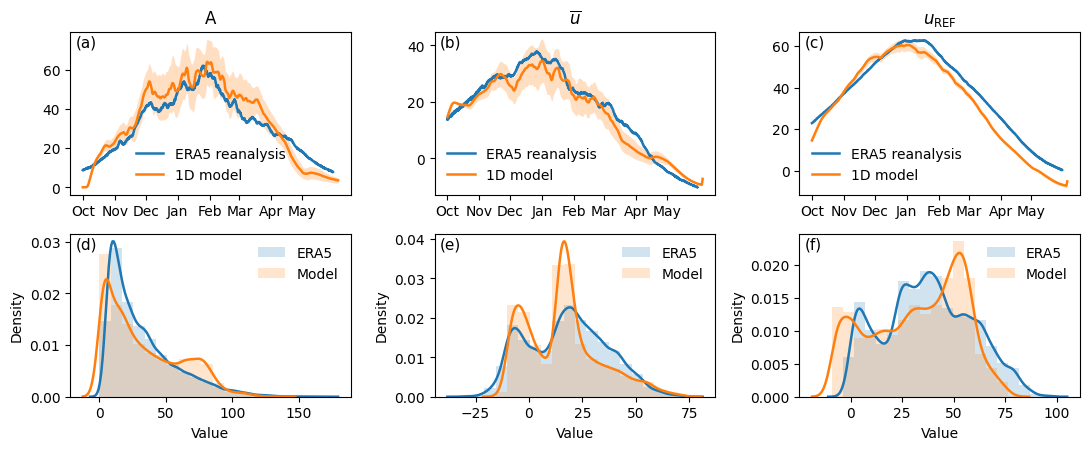

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# ———  import seaborn ———
try:
    import seaborn as sns
    HAS_SNS = True
except Exception:
    HAS_SNS = False

from scipy.interpolate import interp1d
import os

# ======================
# 0) 
# ======================
# ERA5  1/4 0..991 -> 0..247.75 Oct~May
x = np.arange(0, 992, 1) / 4

#  x_new x
try:
    x_new
except NameError:
    x_new = x

#  x
for _name in ["x_orig_fawa", "x_orig_ubar", "x_orig_uref"]:
    if _name not in globals():
        globals()[_name] = x

#  CI
N_fawa = fawa_eachyear.shape[1]
N_ubar = ubar_eachyear.shape[1]
N_uref = uref_eachyear.shape[1]

ci_factor = 2.576  # 99% CI

# ======================
# 1)  2×3 
# ======================
fig, axes = plt.subplots(2, 3, figsize=(11, 4.8))
top_axes = axes[0]   # +CI
bot_axes = axes[1]   #  KDE/

# ----------------------
# +CI ERA5 Model
# ----------------------
def plot_clim_with_ci(ax, mean_raw, std_raw, n_years, x_orig, era5_mean, title):
    ci = ci_factor * std_raw / np.sqrt(n_years)

    if len(x_orig) != len(mean_raw):
        raise ValueError("x_orig  mean_raw ")
    f_mean = interp1d(x_orig, mean_raw, kind='linear', fill_value="extrapolate")
    f_ci   = interp1d(x_orig, ci,       kind='linear', fill_value="extrapolate")
    mean_i = f_mean(x_new)
    ci_i   = f_ci(x_new)

    # ERA5 -> Model
    era5_line,  = ax.plot(x, era5_mean, label='ERA5 reanalysis',  lw=1.8)
    model_line, = ax.plot(x, mean_i,     label='1D model',      lw=1.8)
    ax.fill_between(x, mean_i - ci_i, mean_i + ci_i, color='C1', alpha=0.25, linewidth=0)

    ax.set_xticks([0, 31, 61, 92, 123, 152, 183, 213])
    ax.set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May'])
    ax.set_title(title)

    # ERA5 -> Model
    ax.legend([era5_line, model_line], ['ERA5 reanalysis', '1D model'], frameon=False)

# ======================
# 2) FAWA / UBAR / UREF  + 99% CI
# ======================
# —— FAWA ——
fawa_mean = np.mean(fawa_eachyear[110, :, :], axis=0)
fawa_std  = np.std (fawa_eachyear[110, :, :], axis=0)
fawa_era5_mean = np.mean(fawa_eachyr[64, :, :], axis=0)
plot_clim_with_ci(top_axes[0], fawa_mean, fawa_std, N_fawa, x_orig_fawa, fawa_era5_mean, 'A')

# —— UBAR ——
ubar_mean = np.mean(ubar_eachyear[110, :, :], axis=0)
ubar_std  = np.std (ubar_eachyear[110, :, :], axis=0)
ubar_era5_mean = np.mean(ubar_eachyr[64, :, :], axis=0)
plot_clim_with_ci(top_axes[1], ubar_mean, ubar_std, N_ubar, x_orig_ubar, ubar_era5_mean, r'$\overline{u}$')

# —— UREF ——
uref_mean = np.mean(uref_eachyear[110, :, :], axis=0)
uref_std  = np.std (uref_eachyear[110, :, :], axis=0)
uref_era5_mean = np.mean(uref_eachyr[64, :, :], axis=0)
plot_clim_with_ci(top_axes[2], uref_mean, uref_std, N_uref, x_orig_uref, uref_era5_mean, r'$u_{\mathrm{REF}}$')

# ======================
# 3)  ERA5 Model
# ======================
#  st/st_m~ed/ed_m 
fawa_model_flat = fawa_eachyear[110, :, :].flatten()
fawa_era5_flat  = fawa_eachyr  [64,  :, :].flatten()
ubar_model_flat = ubar_eachyear[110, :, :].flatten()
ubar_era5_flat  = ubar_eachyr  [64,  :, :].flatten()
uref_model_flat = uref_eachyear[110, :, :].flatten()
uref_era5_flat  = uref_eachyr  [64,  :, :].flatten()

def kde_or_hist(ax, era5_arr, model_arr, title='', xlabel=False, ylabel=False,
                bins=20, alpha_hist=0.2, lw_kde=1.8):
    """ histogram  KDE  bins"""
    era5_arr  = np.asarray(era5_arr).ravel()
    model_arr = np.asarray(model_arr).ravel()

    #  matplotlib 
    cycle_colors = plt.rcParams.get('axes.prop_cycle').by_key().get('color', ['C0','C1'])
    c_era5  = cycle_colors[0]
    c_model = cycle_colors[1]

    #  bins
    data_min = np.nanmin([np.nanmin(era5_arr), np.nanmin(model_arr)])
    data_max = np.nanmax([np.nanmax(era5_arr), np.nanmax(model_arr)])
    bin_edges = np.linspace(data_min, data_max, bins + 1)

    # density=True  KDE 
    ax.hist(era5_arr,  bins=bin_edges, density=True, alpha=alpha_hist,
            color=c_era5,  label='ERA5')
    ax.hist(model_arr, bins=bin_edges, density=True, alpha=alpha_hist,
            color=c_model, label='Model')

    # KDEKDE  legend
    if HAS_SNS:
        sns.kdeplot(era5_arr,  ax=ax, lw=lw_kde, fill=False, color=c_era5,  label='_nolegend_')
        sns.kdeplot(model_arr, ax=ax, lw=lw_kde, fill=False, color=c_model, label='_nolegend_')

    ax.set_title(title)
    if ylabel:
        ax.set_ylabel('Density')
    if xlabel:
        ax.set_xlabel('Value')
    ax.legend(frameon=False)


kde_or_hist(bot_axes[0], fawa_era5_flat,  fawa_model_flat, title='', xlabel=True, ylabel=True)
kde_or_hist(bot_axes[1], ubar_era5_flat,  ubar_model_flat, title='', xlabel=True, ylabel=False)
kde_or_hist(bot_axes[2], uref_era5_flat,  uref_model_flat, title='', xlabel=True, ylabel=False)

#  fig, axes = plt.subplots(...) 
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for ax, lab in zip(axes.ravel(), labels):
    ax.text(0.02, 0.98, lab, transform=ax.transAxes,
            ha='left', va='top', fontsize=11)
            # 
            # bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5)


# ======================
# 4)  & 
# ======================
# fig.suptitle('1979–2021 Climatology at 10 hPa (Top, with 99% CI) and Distributions (Bottom)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])

os.makedirs('output', exist_ok=True)
plt.savefig('output/validation.png', dpi=600, bbox_inches='tight')
plt.show()


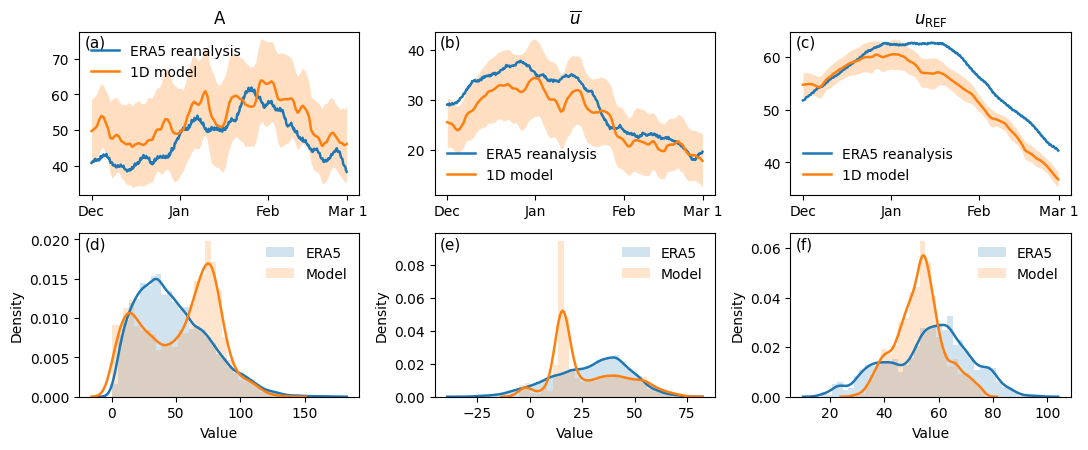

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# ———  import seaborn ———
try:
    import seaborn as sns
    HAS_SNS = True
except Exception:
    HAS_SNS = False

from scipy.interpolate import interp1d
import os

# ======================
# 0) 
# ======================
# ERA56 -> 992  Oct1(0d) ~ May  247.75d
x = np.arange(0, 992, 1) / 4.0  #  Oct 1 
T_days = x.max()                # 247.75
# DJF  Oct1  0
DEC1 =  30 + 31 #30                # 61
MAR1 = DEC1 + 31 + 31 + 28   # DEC1 + 31 + 31 + 28    # 151

#  x_orig_* None
x_orig_fawa = globals().get("x_orig_fawa", None)
x_orig_ubar = globals().get("x_orig_ubar", None)
x_orig_uref = globals().get("x_orig_uref", None)

# ==========  + (yrs,time) DJF  ==========
def _auto_time_coord(n_time, x_orig_like):
    """
     time Oct1  n_time
    
    1) · ~ 0..~248 -> 
    2)  0..n_time-1          ->  0..T_days
    3)  0..1                ->  T_days
    min..max -> 0..T_days
    """
    if x_orig_like is None:
        # 
        idx = np.linspace(0, 1, n_time)
        return idx * T_days

    x_arr = np.asarray(x_orig_like, dtype=float)
    if x_arr.size != n_time:
        # 
        idx = np.linspace(0, 1, n_time)
        return idx * T_days

    # 
    x_min, x_max = float(np.nanmin(x_arr)), float(np.nanmax(x_arr))
    span = x_max - x_min + 1e-12

    # 1)  0..~248
    if x_max >= 200 and x_max <= 400 and x_min > -5:
        #  0..~248 
        #  0  [0, x_max-x_min]
        x_days = x_arr - x_min
        #  ERA5 
        x_days = (x_days / (x_days.max() + 1e-12)) * T_days
        return x_days

    # 2)  0..1
    if x_min >= -1e-6 and x_max <= 1.0 + 1e-6:
        return (x_arr - x_min) / span * T_days

    # 3)  0..n_time-1
    if x_min >= -1e-6 and abs(x_max - (n_time - 1)) < 1e-6:
        return (x_arr - x_min) / span * T_days

    #  0..T_days
    return (x_arr - x_min) / span * T_days


def _djf_mask_from_days(x_days):
    """Oct1  DJF(Dec1~Mar1) """
    return (x_days >= DEC1) & (x_days < MAR1)


def _subseries_DJF(year_time_array, x_orig_like=None):
    """
    year_time_array  (years, time)
         x_orig_like        time /
    
      arr_DJF: (years, time_djf)
      x_sub :  (time_djf,) —— Oct1 /
    """
    n_time = year_time_array.shape[1]
    x_days = _auto_time_coord(n_time, x_orig_like)
    mask = _djf_mask_from_days(x_days)

    #  FalseDEC1/T_days .. MAR1/T_days
    if not np.any(mask):
        frac = np.linspace(0, 1, n_time)
        lo, hi = DEC1 / T_days, MAR1 / T_days
        mask = (frac >= lo) & (frac < hi)

    arr_DJF = year_time_array[:, mask]
    x_sub = x_days[mask]
    return arr_DJF, x_sub


# ========== ERA5  DJF  ==========
mask_era = _djf_mask_from_days(x)
x_win = x[mask_era]               # DJF  ERA5 Oct1 
x_new = x_win - DEC1              #  =>  Dec1 0~90

# ======================
#  CI
# ======================
# (level, years, time)
N_fawa = fawa_eachyear.shape[1]
N_ubar = ubar_eachyear.shape[1]
N_uref = uref_eachyear.shape[1]
ci_factor = 2.576  # 99% CI

# ======================
# 1)  2×3 
# ======================
fig, axes = plt.subplots(2, 3, figsize=(11, 4.8))
top_axes = axes[0]   # +CI
bot_axes = axes[1]   #  KDE/

# ----------------------
# +CI ERA5 Model
# ----------------------
def plot_clim_with_ci(ax, mean_raw, std_raw, n_years, x_days_sub, era5_mean_sub, title):
    """
    mean_raw, std_raw:  DJF  (time_subset,)/
    x_days_sub       : Oct1 
    era5_mean_sub    : ERA5 DJF  (time_subset,)
    """
    if len(x_days_sub) != len(mean_raw):
        raise ValueError("x_days_sub  mean_raw ")

    ci = ci_factor * std_raw / np.sqrt(n_years)

    #  model  DJF  (DEC1 + x_new)  ERA5  DJF 
    f_mean = interp1d(x_days_sub, mean_raw, kind='linear', fill_value="extrapolate", assume_sorted=False)
    f_ci   = interp1d(x_days_sub, ci,       kind='linear', fill_value="extrapolate", assume_sorted=False)
    mean_i = f_mean(DEC1 + x_new)
    ci_i   = f_ci  (DEC1 + x_new)

    # ERA5 -> Model
    era5_line,  = ax.plot(x_new, era5_mean_sub, label='ERA5 reanalysis',  lw=1.8)
    model_line, = ax.plot(x_new, mean_i,        label='1D model',         lw=1.8)
    ax.fill_between(x_new, mean_i - ci_i, mean_i + ci_i, color='C1', alpha=0.25, linewidth=0)

    # DJF  Dec1 
    ax.set_xticks([0, 31, 62, 90])  # Dec1, Jan1, Feb1, Mar1
    ax.set_xticklabels(['Dec', 'Jan', 'Feb', 'Mar 1'])
    ax.set_title(title)
    ax.legend([era5_line, model_line], ['ERA5 reanalysis', '1D model'], frameon=False)

# ======================
# 2) FAWA / UBAR / UREF  + 99% CI DJF 
# ======================
# —— FAWA ——
fawa_model = fawa_eachyear[110, :, :]         # (years, time_model)
fawa_model_DJF, x_days_fawa = _subseries_DJF(fawa_model, x_orig_fawa)
fawa_mean = np.mean(fawa_model_DJF, axis=0)
fawa_std  = np.std (fawa_model_DJF, axis=0)

fawa_era5 = fawa_eachyr[64, :, :]             # (years, time_era=992)
fawa_era5_DJF = fawa_era5[:, mask_era]
fawa_era5_mean = np.mean(fawa_era5_DJF, axis=0)

plot_clim_with_ci(
    top_axes[0],
    mean_raw=fawa_mean,
    std_raw=fawa_std,
    n_years=N_fawa,
    x_days_sub=x_days_fawa,
    era5_mean_sub=fawa_era5_mean,
    title='A'
)

# —— UBAR ——
ubar_model = ubar_eachyear[110, :, :]
ubar_model_DJF, x_days_ubar = _subseries_DJF(ubar_model, x_orig_ubar)
ubar_mean = np.mean(ubar_model_DJF, axis=0)
ubar_std  = np.std (ubar_model_DJF, axis=0)

ubar_era5 = ubar_eachyr[64, :, :]
ubar_era5_DJF = ubar_era5[:, mask_era]
ubar_era5_mean = np.mean(ubar_era5_DJF, axis=0)

plot_clim_with_ci(
    top_axes[1],
    mean_raw=ubar_mean,
    std_raw=ubar_std,
    n_years=N_ubar,
    x_days_sub=x_days_ubar,
    era5_mean_sub=ubar_era5_mean,
    title=r'$\overline{u}$'
)

# —— UREF ——
uref_model = uref_eachyear[110, :, :]
uref_model_DJF, x_days_uref = _subseries_DJF(uref_model, x_orig_uref)
uref_mean = np.mean(uref_model_DJF, axis=0)
uref_std  = np.std (uref_model_DJF, axis=0)

uref_era5 = uref_eachyr[64, :, :]
uref_era5_DJF = uref_era5[:, mask_era]
uref_era5_mean = np.mean(uref_era5_DJF, axis=0)

plot_clim_with_ci(
    top_axes[2],
    mean_raw=uref_mean,
    std_raw=uref_std,
    n_years=N_uref,
    x_days_sub=x_days_uref,
    era5_mean_sub=uref_era5_mean,
    title=r'$u_{\mathrm{REF}}$'
)

# ======================
# 3)  DJF  ERA5 Model
# ======================
def kde_or_hist(ax, era5_arr, model_arr, title='', xlabel=False, ylabel=False,
                bins=40, alpha_hist=0.2, lw_kde=1.8):
    """ histogram  KDE  bins"""
    era5_arr  = np.asarray(era5_arr).ravel()
    model_arr = np.asarray(model_arr).ravel()

    #  matplotlib 
    cycle_colors = plt.rcParams.get('axes.prop_cycle').by_key().get('color', ['C0','C1'])
    c_era5  = cycle_colors[0]
    c_model = cycle_colors[1]

    #  bins
    data_min = np.nanmin([np.nanmin(era5_arr), np.nanmin(model_arr)])
    data_max = np.nanmax([np.nanmax(era5_arr), np.nanmax(model_arr)])
    bin_edges = np.linspace(data_min, data_max, bins + 1)

    # density=True  KDE 
    ax.hist(era5_arr,  bins=bin_edges, density=True, alpha=alpha_hist,
            color=c_era5,  label='ERA5')
    ax.hist(model_arr, bins=bin_edges, density=True, alpha=alpha_hist,
            color=c_model, label='Model')

    # KDEKDE  legend
    if HAS_SNS:
        sns.kdeplot(era5_arr,  ax=ax, lw=lw_kde, fill=False, color=c_era5,  label='_nolegend_')
        sns.kdeplot(model_arr, ax=ax, lw=lw_kde, fill=False, color=c_model, label='_nolegend_')

    ax.set_title(title)
    if ylabel:
        ax.set_ylabel('Density')
    if xlabel:
        ax.set_xlabel('Value')
    ax.legend(frameon=False)

fawa_model_flat = fawa_model_DJF.ravel()
fawa_era5_flat  = fawa_era5_DJF.ravel()
ubar_model_flat = ubar_model_DJF.ravel()
ubar_era5_flat  = ubar_era5_DJF.ravel()
uref_model_flat = uref_model_DJF.ravel()
uref_era5_flat  = uref_era5_DJF.ravel()

kde_or_hist(bot_axes[0], fawa_era5_flat,  fawa_model_flat, title='', xlabel=True, ylabel=True)
kde_or_hist(bot_axes[1], ubar_era5_flat,  ubar_model_flat, title='', xlabel=True, ylabel=False)
kde_or_hist(bot_axes[2], uref_era5_flat,  uref_model_flat, title='', xlabel=True, ylabel=False)

# 
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for ax, lab in zip(axes.ravel(), labels):
    ax.text(0.02, 0.98, lab, transform=ax.transAxes,
            ha='left', va='top', fontsize=11)

# ======================
# 4)  & 
# ======================
# fig.suptitle('DJF (Dec–Feb) Climatology at 10 hPa (Top, with 99% CI) and Distributions (Bottom)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])

os.makedirs('output', exist_ok=True)
plt.savefig('output/validation_DJF.png', dpi=600, bbox_inches='tight')
plt.show()


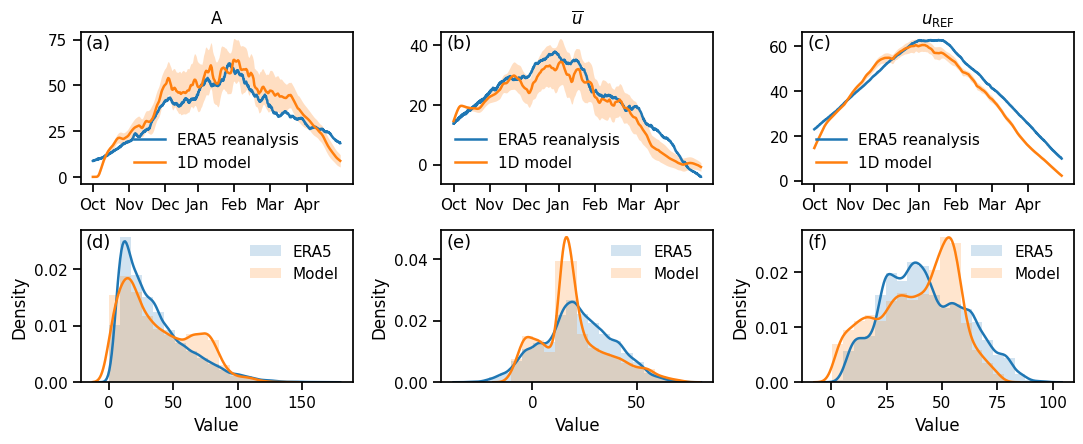

[INFO] ERA5 DJF points: 848 of 992
[INFO] FAWA model time len: 320 DJF points: 273
[INFO] UBAR model time len: 320 DJF points: 273
[INFO] UREF model time len: 320 DJF points: 273
[INFO] x_days_fawa range: 0.0 -> 211.24764890261005
[INFO] x_days_ubar  range: 0.0 -> 211.24764890261005
[INFO] x_days_uref  range: 0.0 -> 211.24764890261005


In [56]:
import numpy as np
import matplotlib.pyplot as plt

# 
plt.rcParams.update({
    'font.size': 16,          # 
    'axes.titlesize': 10,     # 
    'axes.labelsize': 10,     # 
    'xtick.labelsize': 10,    # x 
    'ytick.labelsize': 10,    # y 
    'legend.fontsize': 10,    # 
})

# ———  import seaborn ———
try:
    import seaborn as sns
    HAS_SNS = True
    sns.set_context("notebook", font_scale=1)  # seaborn
except Exception:
    HAS_SNS = False

from scipy.interpolate import interp1d
import os

# ======================
# 0) 
# ======================
# ERA56 -> 992  Oct1(0d) ~ May  247.75d
x = np.arange(0, 992, 1) / 4.0  #  Oct 1 
T_days = x.max()                # 247.75
# DJF  Oct1  0
# DEC1 = 31 + 30               # 61
# MAR1 = DEC1 + 31 + 31 + 28    # 151

DEC1 = 0               # 61
MAR1 = 31 + 30 + 31 + 31 + 28 + 31 + 30   # 151

#  x_orig_* None
x_orig_fawa = globals().get("x_orig_fawa", None)
x_orig_ubar = globals().get("x_orig_ubar", None)
x_orig_uref = globals().get("x_orig_uref", None)

# ==========  + (yrs,time) DJF  ==========
def _auto_time_coord(n_time, x_orig_like):
    """
     time Oct1  n_time
    
    1) · ~ 0..~248 -> 
    2)  0..n_time-1          ->  0..T_days
    3)  0..1                ->  T_days
    min..max -> 0..T_days
    """
    if x_orig_like is None:
        # 
        idx = np.linspace(0, 1, n_time)
        return idx * T_days

    x_arr = np.asarray(x_orig_like, dtype=float)
    if x_arr.size != n_time:
        # 
        idx = np.linspace(0, 1, n_time)
        return idx * T_days

    # 
    x_min, x_max = float(np.nanmin(x_arr)), float(np.nanmax(x_arr))
    span = x_max - x_min + 1e-12

    # 1)  0..~248
    if x_max >= 200 and x_max <= 400 and x_min > -5:
        #  0..~248 
        #  0  [0, x_max-x_min]
        x_days = x_arr - x_min
        #  ERA5 
        x_days = (x_days / (x_days.max() + 1e-12)) * T_days
        return x_days

    # 2)  0..1
    if x_min >= -1e-6 and x_max <= 1.0 + 1e-6:
        return (x_arr - x_min) / span * T_days

    # 3)  0..n_time-1
    if x_min >= -1e-6 and abs(x_max - (n_time - 1)) < 1e-6:
        return (x_arr - x_min) / span * T_days

    #  0..T_days
    return (x_arr - x_min) / span * T_days


def _djf_mask_from_days(x_days):
    """Oct1  DJF(Dec1~Mar1) """
    return (x_days >= DEC1) & (x_days < MAR1)


def _subseries_DJF(year_time_array, x_orig_like=None):
    """
    year_time_array  (years, time)
         x_orig_like        time /
    
      arr_DJF: (years, time_djf)
      x_sub :  (time_djf,) —— Oct1 /
    """
    n_time = year_time_array.shape[1]
    x_days = _auto_time_coord(n_time, x_orig_like)
    mask = _djf_mask_from_days(x_days)

    #  FalseDEC1/T_days .. MAR1/T_days
    if not np.any(mask):
        frac = np.linspace(0, 1, n_time)
        lo, hi = DEC1 / T_days, MAR1 / T_days
        mask = (frac >= lo) & (frac < hi)

    arr_DJF = year_time_array[:, mask]
    x_sub = x_days[mask]
    return arr_DJF, x_sub


# ========== ERA5  DJF  ==========
mask_era = _djf_mask_from_days(x)
x_win = x[mask_era]               # DJF  ERA5 Oct1 
x_new = x_win - DEC1              #  =>  Dec1 0~90

# ======================
#  CI
# ======================
# (level, years, time)
N_fawa = fawa_eachyear.shape[1]
N_ubar = ubar_eachyear.shape[1]
N_uref = uref_eachyear.shape[1]
ci_factor = 2.576  # 99% CI

# ======================
# 1)  2×3 
# ======================
fig, axes = plt.subplots(2, 3, figsize=(11, 4.8))
top_axes = axes[0]   # +CI
bot_axes = axes[1]   #  KDE/

# ----------------------
# +CI ERA5 Model
# ----------------------
def plot_clim_with_ci(ax, mean_raw, std_raw, n_years, x_days_sub, era5_mean_sub, title):
    """
    mean_raw, std_raw:  DJF  (time_subset,)/
    x_days_sub       : Oct1 
    era5_mean_sub    : ERA5 DJF  (time_subset,)
    """
    if len(x_days_sub) != len(mean_raw):
        raise ValueError("x_days_sub  mean_raw ")

    ci = ci_factor * std_raw / np.sqrt(n_years)

    #  model  DJF  (DEC1 + x_new)  ERA5  DJF 
    f_mean = interp1d(x_days_sub, mean_raw, kind='linear', fill_value="extrapolate", assume_sorted=False)
    f_ci   = interp1d(x_days_sub, ci,       kind='linear', fill_value="extrapolate", assume_sorted=False)
    mean_i = f_mean(DEC1 + x_new)
    ci_i   = f_ci  (DEC1 + x_new)

    # ERA5 -> Model
    era5_line,  = ax.plot(x_new, era5_mean_sub, label='ERA5 reanalysis',  lw=1.8)
    model_line, = ax.plot(x_new, mean_i,        label='1D model',         lw=1.8)
    ax.fill_between(x_new, mean_i - ci_i, mean_i + ci_i, color='C1', alpha=0.25, linewidth=0)

    # DJF  Dec1 
    ax.set_xticks([0, 31, 62, 90, 121, 152, 183])  # Dec1, Jan1, Feb1, Mar1
    # ax.set_xticklabels(['Dec', 'Jan', 'Feb', 'Mar 1'])
    ax.set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr'])
    ax.set_title(title)
    ax.legend([era5_line, model_line], ['ERA5 reanalysis', '1D model'], frameon=False)

# ======================
# 2) FAWA / UBAR / UREF  + 99% CI DJF 
# ======================
# —— FAWA ——
fawa_model = fawa_eachyear[110, :, :]         # (years, time_model)
fawa_model_DJF, x_days_fawa = _subseries_DJF(fawa_model, x_orig_fawa)
fawa_mean = np.nanmean(fawa_model_DJF, axis=0)
fawa_std  = np.nanstd (fawa_model_DJF, axis=0)

fawa_era5 = fawa_eachyr[64, :, :]             # (years, time_era=992)
fawa_era5_DJF = fawa_era5[:, mask_era]
fawa_era5_mean = np.nanmean(fawa_era5_DJF, axis=0)

plot_clim_with_ci(
    top_axes[0],
    mean_raw=fawa_mean,
    std_raw=fawa_std,
    n_years=N_fawa,
    x_days_sub=x_days_fawa,
    era5_mean_sub=fawa_era5_mean,
    title='A'
)

# —— UBAR ——
ubar_model = ubar_eachyear[110, :, :]
ubar_model_DJF, x_days_ubar = _subseries_DJF(ubar_model, x_orig_ubar)
ubar_mean = np.nanmean(ubar_model_DJF, axis=0)
ubar_std  = np.nanstd (ubar_model_DJF, axis=0)

ubar_era5 = ubar_eachyr[64, :, :]
ubar_era5_DJF = ubar_era5[:, mask_era]
ubar_era5_mean = np.nanmean(ubar_era5_DJF, axis=0)

plot_clim_with_ci(
    top_axes[1],
    mean_raw=ubar_mean,
    std_raw=ubar_std,
    n_years=N_ubar,
    x_days_sub=x_days_ubar,
    era5_mean_sub=ubar_era5_mean,
    title=r'$\overline{u}$'
)

# —— UREF ——
uref_model = uref_eachyear[110, :, :]
uref_model_DJF, x_days_uref = _subseries_DJF(uref_model, x_orig_uref)
uref_mean = np.nanmean(uref_model_DJF, axis=0)
uref_std  = np.nanstd (uref_model_DJF, axis=0)

uref_era5 = uref_eachyr[64, :, :]
uref_era5_DJF = uref_era5[:, mask_era]
uref_era5_mean = np.nanmean(uref_era5_DJF, axis=0)

plot_clim_with_ci(
    top_axes[2],
    mean_raw=uref_mean,
    std_raw=uref_std,
    n_years=N_uref,
    x_days_sub=x_days_uref,
    era5_mean_sub=uref_era5_mean,
    title=r'$u_{\mathrm{REF}}$'
)

# ======================
# 3)  DJF  ERA5 Model
# ======================
def kde_or_hist(ax, era5_arr, model_arr, title='', xlabel=False, ylabel=False,
                bins=20, alpha_hist=0.2, lw_kde=1.8):
    """ histogram  KDE  bins"""
    era5_arr  = np.asarray(era5_arr).ravel()
    model_arr = np.asarray(model_arr).ravel()

    #  matplotlib 
    cycle_colors = plt.rcParams.get('axes.prop_cycle').by_key().get('color', ['C0','C1'])
    c_era5  = cycle_colors[0]
    c_model = cycle_colors[1]

    #  bins
    data_min = np.nanmin([np.nanmin(era5_arr), np.nanmin(model_arr)])
    data_max = np.nanmax([np.nanmax(era5_arr), np.nanmax(model_arr)])
    bin_edges = np.linspace(data_min, data_max, bins + 1)

    # density=True  KDE 
    ax.hist(era5_arr,  bins=bin_edges, density=True, alpha=alpha_hist,
            color=c_era5,  label='ERA5')
    ax.hist(model_arr, bins=bin_edges, density=True, alpha=alpha_hist,
            color=c_model, label='Model')

    # KDEKDE  legend
    if HAS_SNS:
        sns.kdeplot(era5_arr,  ax=ax, lw=lw_kde, fill=False, color=c_era5,  label='_nolegend_')
        sns.kdeplot(model_arr, ax=ax, lw=lw_kde, fill=False, color=c_model, label='_nolegend_')

    ax.set_title(title)
    if ylabel:
        ax.set_ylabel('Density')
    if xlabel:
        ax.set_xlabel('Value')
    ax.legend(frameon=False)



fawa_model_flat = fawa_model_DJF.ravel()
fawa_era5_flat  = fawa_era5_DJF.ravel()
ubar_model_flat = ubar_model_DJF.ravel()
ubar_era5_flat  = ubar_era5_DJF.ravel()
uref_model_flat = uref_model_DJF.ravel()
uref_era5_flat  = uref_era5_DJF.ravel()

kde_or_hist(bot_axes[0], fawa_era5_flat,  fawa_model_flat, title='', xlabel=True, ylabel=True)
kde_or_hist(bot_axes[1], ubar_era5_flat,  ubar_model_flat, title='', xlabel=True, ylabel=False)
kde_or_hist(bot_axes[2], uref_era5_flat,  uref_model_flat, title='', xlabel=True, ylabel=False)

# 
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for ax, lab in zip(axes.ravel(), labels):
    ax.text(0.02, 0.98, lab, transform=ax.transAxes,
            ha='left', va='top', fontsize=13)  # 16

# ======================
# 4)  & 
# ======================
# fig.suptitle('DJF (Dec–Feb) Climatology at 10 hPa (Top, with 99% CI) and Distributions (Bottom)', fontsize=17)
plt.tight_layout(rect=[0, 0, 1, 0.96])

os.makedirs('output', exist_ok=True)
plt.savefig('output/validation_DJF.png', dpi=600, bbox_inches='tight')
plt.show()

# —— ——
print("[INFO] ERA5 DJF points:", mask_era.sum(), "of", x.size)
print("[INFO] FAWA model time len:", fawa_model.shape[1], "DJF points:", fawa_model_DJF.shape[1])
print("[INFO] UBAR model time len:", ubar_model.shape[1], "DJF points:", ubar_model_DJF.shape[1])
print("[INFO] UREF model time len:", uref_model.shape[1], "DJF points:", uref_model_DJF.shape[1])
print("[INFO] x_days_fawa range:", float(x_days_fawa.min()), "->", float(x_days_fawa.max()))
print("[INFO] x_days_ubar  range:", float(x_days_ubar.min()),  "->", float(x_days_ubar.max()))
print("[INFO] x_days_uref  range:", float(x_days_uref.min()),  "->", float(x_days_uref.max()))


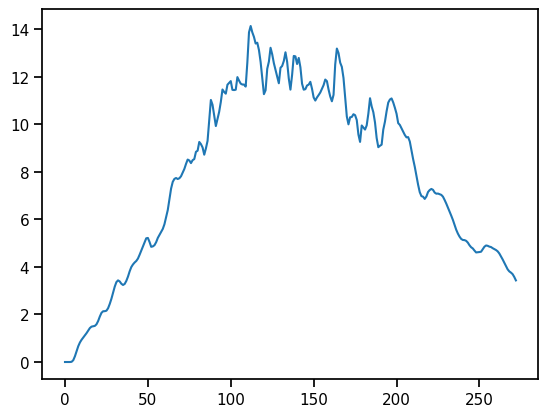

In [57]:
plot.plot(2.56*fawa_std/np.sqrt(42))

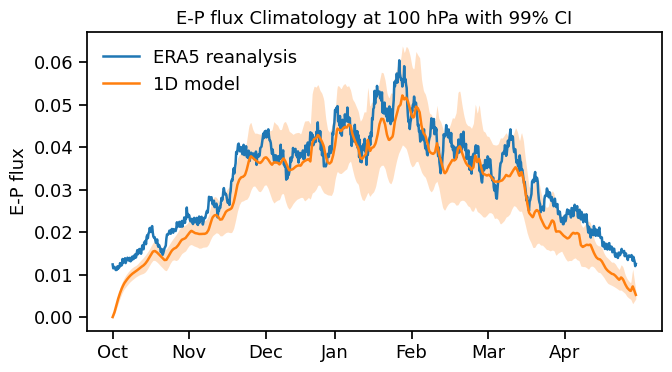

[INFO] ERA5 DJF points: 848 of 992
[INFO] FAWA model time len: 320 DJF points: 273
[INFO] x_days_fawa range: 0.0 -> 211.24764890261005


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import os

# 
plt.rcParams.update({
    'font.size': 16,          # 
    'axes.titlesize': 13,     # 
    'axes.labelsize': 13,     # 
    'xtick.labelsize': 13,    # x 
    'ytick.labelsize': 13,    # y 
    'legend.fontsize': 13,    # 
})

# ======================
# 0) 
# ======================
x = np.arange(0, 992, 1) / 4.0  #  Oct 1 
T_days = x.max()                # 247.75

DEC1 = 0
MAR1 = 31 + 30 + 31 + 31 + 28 + 31 + 30

x_orig_fawa = globals().get("x_orig_fawa", None)

def _auto_time_coord(n_time, x_orig_like):
    if x_orig_like is None:
        idx = np.linspace(0, 1, n_time)
        return idx * T_days
    x_arr = np.asarray(x_orig_like, dtype=float)
    if x_arr.size != n_time:
        idx = np.linspace(0, 1, n_time)
        return idx * T_days
    x_min, x_max = float(np.nanmin(x_arr)), float(np.nanmax(x_arr))
    span = x_max - x_min + 1e-12
    if x_max >= 200 and x_max <= 400 and x_min > -5:
        x_days = x_arr - x_min
        x_days = (x_days / (x_days.max() + 1e-12)) * T_days
        return x_days
    if x_min >= -1e-6 and x_max <= 1.0 + 1e-6:
        return (x_arr - x_min) / span * T_days
    if x_min >= -1e-6 and abs(x_max - (n_time - 1)) < 1e-6:
        return (x_arr - x_min) / span * T_days
    return (x_arr - x_min) / span * T_days

def _djf_mask_from_days(x_days):
    return (x_days >= DEC1) & (x_days < MAR1)

def _subseries_DJF(year_time_array, x_orig_like=None):
    n_time = year_time_array.shape[1]
    x_days = _auto_time_coord(n_time, x_orig_like)
    mask = _djf_mask_from_days(x_days)
    if not np.any(mask):
        frac = np.linspace(0, 1, n_time)
        lo, hi = DEC1 / T_days, MAR1 / T_days
        mask = (frac >= lo) & (frac < hi)
    arr_DJF = year_time_array[:, mask]
    x_sub = x_days[mask]
    return arr_DJF, x_sub

# ========== ERA5  DJF  ==========
mask_era = _djf_mask_from_days(x)
x_win = x[mask_era]
x_new = x_win - DEC1

#  CI
N_fawa = fawa_eachyear.shape[1]
ci_factor = 2.576  # 99% CI

# ========== FAWA ==========
fig, ax = plt.subplots(1, 1, figsize=(7,4))

def plot_clim_with_ci(ax, mean_raw, std_raw, n_years, x_days_sub, era5_mean_sub, title):
    if len(x_days_sub) != len(mean_raw):
        raise ValueError("x_days_sub  mean_raw ")
    ci = ci_factor * std_raw / np.sqrt(n_years)
    f_mean = interp1d(x_days_sub, mean_raw, kind='linear', fill_value="extrapolate", assume_sorted=False)
    f_ci   = interp1d(x_days_sub, ci,       kind='linear', fill_value="extrapolate", assume_sorted=False)
    mean_i = f_mean(DEC1 + x_new)
    ci_i   = f_ci  (DEC1 + x_new)
    era5_line,  = ax.plot(x_new, era5_mean_sub, label='ERA5 reanalysis',  lw=1.8)
    model_line, = ax.plot(x_new, mean_i,        label='1D model',         lw=1.8)
    ax.fill_between(x_new, mean_i - ci_i, mean_i + ci_i, color='C1', alpha=0.25, linewidth=0)
    ax.set_xticks([0, 31, 62, 90, 121, 152, 183])
    ax.set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr'])
    ax.set_title(title)
    ax.set_ylabel('E-P flux')
    # ax.set_xlabel('Days since Dec 1')
    ax.legend(frameon=False)

# —— FAWA ——
fawa_model = fz_eachyear[32, :, :]
fawa_model_DJF, x_days_fawa = _subseries_DJF(fawa_model, x_orig_fawa)
fawa_mean = np.mean(fawa_model_DJF, axis=0)
fawa_std  = np.std (fawa_model_DJF, axis=0)

fawa_era5 = epz_eachyr[32, :, :]
fawa_era5_DJF = fawa_era5[:, mask_era]
fawa_era5_mean = np.mean(fawa_era5_DJF, axis=0)

plot_clim_with_ci(
    ax,
    mean_raw=fawa_mean,
    std_raw=fawa_std,
    n_years=N_fawa,
    x_days_sub=x_days_fawa,
    era5_mean_sub=fawa_era5_mean,
    title='E-P flux Climatology at 100 hPa with 99% CI'
)

plt.tight_layout()

os.makedirs('output', exist_ok=True)
# plt.savefig('output/validation_DJF_fawa_only.png', dpi=600, bbox_inches='tight')
plt.show()

print("[INFO] ERA5 DJF points:", mask_era.sum(), "of", x.size)
print("[INFO] FAWA model time len:", fawa_model.shape[1], "DJF points:", fawa_model_DJF.shape[1])
print("[INFO] x_days_fawa range:", float(x_days_fawa.min()), "->", float(x_days_fawa.max()))


In [59]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. model EPz from parameterization
# ============================================================

delta_u = 16.0
u_star  = 9.0
Ccoef   = 3e-3
Hscale  = 7000.0   # m

z_model_m = h1d.copy()   # shape (501,), meters
expfac_model = np.exp(-z_model_m[:, None, None] / Hscale)

sigma_model = delta_u / (1.0 + np.exp(ubar_eachyear - u_star))
epz_model_eachyear = fz_eachyear # Ccoef * expfac_model * (ubar_eachyear + sigma_model) * (fawa_eachyear - sigma_model)

print("model EPz shape:", epz_model_eachyear.shape)   # (501, 42, 320)
print("ERA5 EPz shape :", epz_eachyr.shape)           # (97, 42, 992)

model EPz shape: (501, 42, 320)
ERA5 EPz shape : (97, 42, 992)


/tmp/ipykernel_3248528/931961222.py:16: RuntimeWarning: overflow encountered in exp
  sigma_model = delta_u / (1.0 + np.exp(ubar_eachyear - u_star))


In [60]:
# ============================================================
# 2. compress ERA5 time dimension: 992 -> 320
# ============================================================

def compress_time_to_target_mean(v_zyt, target_len=320):
    """
    v_zyt: array, shape (nz, ny, nt_src)
    return: array, shape (nz, ny, target_len)

    
    -  nt_src  [0,1)
    -  target_len  [0,1)  bin 
    -  bin 
    """
    v_zyt = np.asarray(v_zyt, dtype=float)
    nz, ny, nt_src = v_zyt.shape

    out = np.full((nz, ny, target_len), np.nan, dtype=float)

    # 
    t_src = (np.arange(nt_src) + 0.5) / nt_src
    #  bin 
    edges = np.linspace(0.0, 1.0, target_len + 1)

    for j in range(target_len):
        mask = (t_src >= edges[j]) & (t_src < edges[j + 1])

        #  bin 
        if j == target_len - 1:
            mask = (t_src >= edges[j]) & (t_src <= edges[j + 1])

        if np.any(mask):
            out[:, :, j] = np.nanmean(v_zyt[:, :, mask], axis=2)

    return out

In [61]:
ubar_era_320 = compress_time_to_target_mean(ubar_eachyr, target_len=320)
fawa_era_320 = compress_time_to_target_mean(fawa_eachyr, target_len=320)
uref_era_320 = compress_time_to_target_mean(uref_eachyr, target_len=320)
epz_era_320  = compress_time_to_target_mean(epz_eachyr,  target_len=320)

print("ubar_era_320:", ubar_era_320.shape)
print("epz_era_320 :", epz_era_320.shape)

/tmp/ipykernel_3248528/1788763980.py:33: RuntimeWarning: Mean of empty slice
  out[:, :, j] = np.nanmean(v_zyt[:, :, mask], axis=2)


ubar_era_320: (97, 42, 320)
epz_era_320 : (97, 42, 320)


In [62]:
# ============================================================
# 3. climatology in z-t, both on 320-grid
# ============================================================

xx_320 = np.arange(320)

#  40:240  Nov-Mar  Apr 
t_slice = slice(40, 240)
t_plot = xx_320[t_slice]

z_era_km = height / 1000.0
z_mod_km = hhh

zmin, zmax = 16.0, 48.0
era_z_mask = (z_era_km >= zmin) & (z_era_km <= zmax)
mod_z_mask = (z_mod_km >= zmin) & (z_mod_km <= zmax)

z_era_plot = z_era_km[era_z_mask]
z_mod_plot = z_mod_km[mod_z_mask]

def clim_on_320(field3d, zmask):
    # field3d shape = (z, year, 320)
    f_clim = np.nanmean(field3d, axis=1)   # (z, 320)
    return f_clim[zmask, t_slice]

epz_era_2d   = clim_on_320(epz_era_320, era_z_mask)
epz_model_2d = clim_on_320(epz_model_eachyear, mod_z_mask)

print(epz_era_2d.shape, epz_model_2d.shape)

(65, 200) (160, 200)


/tmp/ipykernel_3248528/2752868423.py:23: RuntimeWarning: Mean of empty slice
  f_clim = np.nanmean(field3d, axis=1)   # (z, 320)


In [63]:
epz_era_320.shape

(97, 42, 320)

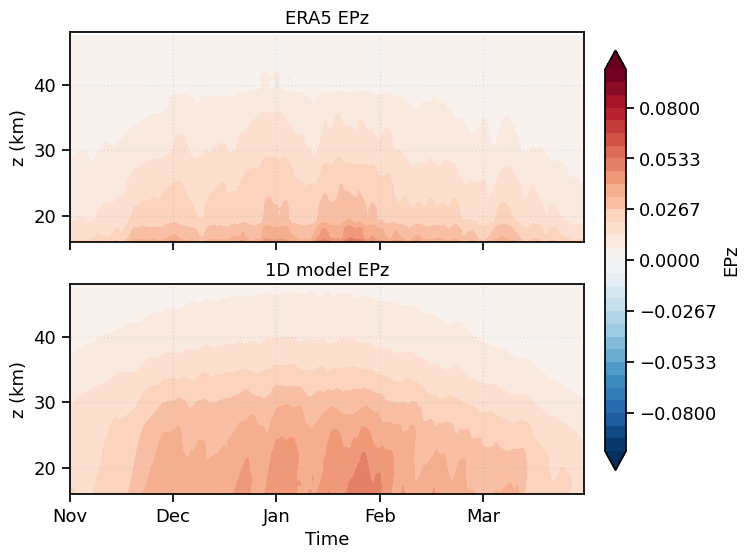

In [64]:
# ============================================================
# 4. plot ERA5 vs model EPz
# ============================================================

Te, Ze = np.meshgrid(t_plot, z_era_plot)
Tm, Zm = np.meshgrid(t_plot, z_mod_plot)

xticks = [40, 80, 120, 160, 200]
xticklabels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']

# vabs = max(np.nanmax(np.abs(epz_era_2d)),
#            np.nanmax(np.abs(epz_model_2d)))
vabs = 0.1 #float(np.ceil(vabs / 0.01) * 0.01)
levels_epz = np.linspace(-vabs, vabs, 31)

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
fig.subplots_adjust(right=0.86)

cf0 = axes[0].contourf(
    Te, Ze, epz_era_2d,
    levels=levels_epz, extend='both', cmap='RdBu_r'
)
axes[0].set_title('ERA5 EPz')
axes[0].set_ylabel('z (km)')
axes[0].set_ylim(zmin, zmax)
axes[0].grid(True, linestyle=':', alpha=0.3)

cf1 = axes[1].contourf(
    Tm, Zm, epz_model_2d,
    levels=levels_epz, extend='both', cmap='RdBu_r'
)
axes[1].set_title('1D model EPz')
axes[1].set_ylabel('z (km)')
axes[1].set_xlabel('Time')
axes[1].set_ylim(zmin, zmax)
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(xticklabels)
axes[1].grid(True, linestyle=':', alpha=0.3)

cax = fig.add_axes([0.89, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(cf1, cax=cax)
cbar.set_label('EPz')

plt.show()

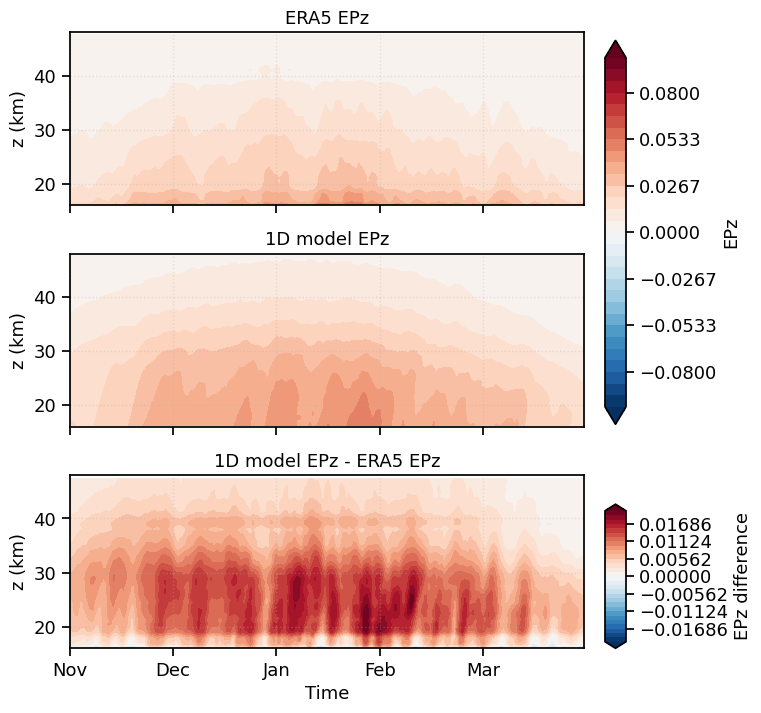

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# helper: interpolate one 2D field in vertical
# ============================================================
def interp_vertical_2d(field_zt, z_src, z_tgt):
    """
    field_zt: (nz_src, nt)
    z_src   : (nz_src,)
    z_tgt   : (nz_tgt,)
    return  : (nz_tgt, nt)
    """
    field_zt = np.asarray(field_zt, dtype=float)
    z_src = np.asarray(z_src, dtype=float)
    z_tgt = np.asarray(z_tgt, dtype=float)

    nz_src, nt = field_zt.shape
    out = np.full((len(z_tgt), nt), np.nan, dtype=float)

    for it in range(nt):
        out[:, it] = np.interp(z_tgt, z_src, field_zt[:, it])

    return out


# ============================================================
# 4. plot ERA5 / model / difference for EPz
# ============================================================

Te, Ze = np.meshgrid(t_plot, z_era_plot)
Tm, Zm = np.meshgrid(t_plot, z_mod_plot)

xticks = [40, 80, 120, 160, 200]
xticklabels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']

# main EPz color scale
vabs = 0.1
levels_epz = np.linspace(-vabs, vabs, 31)

# interpolate ERA5 to model z-grid for difference
epz_era_on_modelz_2d = interp_vertical_2d(
    epz_era_2d,
    z_era_plot,
    z_mod_plot
)

epz_diff_2d = epz_model_2d - epz_era_on_modelz_2d

# difference color scale
vabs_diff = np.nanmax(np.abs(epz_diff_2d))
#  vabs_diff = 0.05
levels_diff = np.linspace(-vabs_diff, vabs_diff, 31)

fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)
fig.subplots_adjust(right=0.86, hspace=0.28)

# ---------------- ERA5 ----------------
cf0 = axes[0].contourf(
    Te, Ze, epz_era_2d,
    levels=levels_epz, extend='both', cmap='RdBu_r'
)
axes[0].set_title('ERA5 EPz')
axes[0].set_ylabel('z (km)')
axes[0].set_ylim(zmin, zmax)
axes[0].grid(True, linestyle=':', alpha=0.3)

# ---------------- model ----------------
cf1 = axes[1].contourf(
    Tm, Zm, epz_model_2d,
    levels=levels_epz, extend='both', cmap='RdBu_r'
)
axes[1].set_title('1D model EPz')
axes[1].set_ylabel('z (km)')
axes[1].set_ylim(zmin, zmax)
axes[1].grid(True, linestyle=':', alpha=0.3)

# ---------------- difference ----------------
cf2 = axes[2].contourf(
    Tm, Zm, epz_diff_2d,
    levels=levels_diff, extend='both', cmap='RdBu_r'
)
axes[2].set_title('1D model EPz - ERA5 EPz')
axes[2].set_ylabel('z (km)')
axes[2].set_xlabel('Time')
axes[2].set_ylim(zmin, zmax)
axes[2].set_xticks(xticks)
axes[2].set_xticklabels(xticklabels)
axes[2].grid(True, linestyle=':', alpha=0.3)

# colorbar for top two
cax1 = fig.add_axes([0.89, 0.39, 0.03, 0.48])
cbar1 = fig.colorbar(cf1, cax=cax1)
cbar1.set_label('EPz')

# colorbar for difference
cax2 = fig.add_axes([0.89, 0.11, 0.03, 0.18])
cbar2 = fig.colorbar(cf2, cax=cax2)
cbar2.set_label('EPz difference')

plt.show()

In [66]:
# import numpy as np
# import matplotlib.pyplot as plt

# def vertical_derivative_2d(field_zt, z_m):
#     """
#     field_zt : shape (nz, nt)
#     z_m      : shape (nz,), vertical coordinate in meters
#     return   : d(field)/dz, shape (nz, nt)
#     """
#     field_zt = np.asarray(field_zt, dtype=float)
#     z_m = np.asarray(z_m, dtype=float)
#     return np.gradient(field_zt, z_m, axis=0)

# def clim_on_320(field3d, zmask):
#     """
#     field3d shape = (z, year, 320)
#     return climatology on selected z and t_slice:
#         shape = (nz_masked, nt_plot)
#     """
#     f_clim = np.nanmean(field3d, axis=1)   # (z, 320)
#     return f_clim[zmask, t_slice]

# # ============================================================
# # 1. vertical coordinates in meters
# # ============================================================

# z_era_m = height.copy()   # ERA5, shape (97,), meters
# z_mod_m = h1d.copy()      # model, shape (501,), meters

# print(z_era_m[:5], z_era_m[-5:])
# print(z_mod_m[:5], z_mod_m[-5:])

# # ============================================================
# # 2. first get Fz climatology, then take vertical derivative
# # ============================================================

# # ---- ERA5: first compress 992 -> 320 for Fz itself ----
# epz_era_320 = compress_time_to_target_mean(epz_eachyr, target_len=320)

# # ---- climatology Fz on plotting domain ----
# epz_era_2d = clim_on_320(epz_era_320, era_z_mask)          # shape (nz_era_mask, nt_plot)
# fz_mod_2d  = clim_on_320(epz_model_eachyear, mod_z_mask)   # shape (nz_mod_mask, nt_plot)

# print("epz_era_2d shape:", epz_era_2d.shape)
# print("fz_mod_2d shape :", fz_mod_2d.shape)

# # ---- corresponding z on the masked plotting domain ----
# z_era_plot_km = (height / 1000.0)[era_z_mask]
# z_mod_plot_km = hhh[mod_z_mask]

# z_era_plot_m = height[era_z_mask]
# z_mod_plot_m = h1d[mod_z_mask]

# print("z_era_plot_m shape:", z_era_plot_m.shape)
# print("z_mod_plot_m shape:", z_mod_plot_m.shape)

# # ============================================================
# # 3. dFz/dz from climatological Fz
# # ============================================================

# epzdiv_era_2d   = vertical_derivative_2d(epz_era_2d, z_era_plot_m)
# epzdiv_model_2d = vertical_derivative_2d(fz_mod_2d,  z_mod_plot_m)

# print("epzdiv_era_2d shape   :", epzdiv_era_2d.shape)
# print("epzdiv_model_2d shape :", epzdiv_model_2d.shape)

# print("ERA5 dFz/dz min/max :", np.nanmin(epzdiv_era_2d), np.nanmax(epzdiv_era_2d))
# print("Model dFz/dz min/max:", np.nanmin(epzdiv_model_2d), np.nanmax(epzdiv_model_2d))

# # ============================================================
# # 4. plot ERA5 vs model dFz/dz
# # ============================================================

# Te, Ze = np.meshgrid(t_plot, z_era_plot_km)
# Tm, Zm = np.meshgrid(t_plot, z_mod_plot_km)

# xticks = [40, 80, 120, 160, 200]
# xticklabels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']

# vabs_div = 5e-6
# levels_div = np.linspace(-vabs_div, vabs_div, 21)

# fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
# fig.subplots_adjust(right=0.86)

# cf0 = axes[0].contourf(
#     Te, Ze, epzdiv_era_2d,
#     levels=levels_div, extend='both', cmap='RdBu_r'
# )
# axes[0].set_title(r'ERA5 $\partial F_z / \partial z$ (from climatological $F_z$)')
# axes[0].set_ylabel('z (km)')
# axes[0].set_ylim(zmin, zmax)
# axes[0].grid(True, linestyle=':', alpha=0.3)

# cf1 = axes[1].contourf(
#     Tm, Zm, epzdiv_model_2d,
#     levels=levels_div, extend='both', cmap='RdBu_r'
# )
# axes[1].set_title(r'1D model $\partial F_z / \partial z$ (from climatological $F_z$)')
# axes[1].set_ylabel('z (km)')
# axes[1].set_xlabel('Time')
# axes[1].set_ylim(zmin, zmax)
# axes[1].set_xticks(xticks)
# axes[1].set_xticklabels(xticklabels)
# axes[1].grid(True, linestyle=':', alpha=0.3)

# cax = fig.add_axes([0.89, 0.15, 0.03, 0.7])
# cbar = fig.colorbar(cf1, cax=cax)
# cbar.set_label(r'$\partial F_z / \partial z$')

# plt.show()

[   0.  500. 1000. 1500. 2000.] [46000. 46500. 47000. 47500. 48000.]
[10000. 10200. 10400. 10600. 10800.] [109200. 109400. 109600. 109800. 110000.]
epzdiv_era_eachyr shape   : (97, 42, 992)
epzdiv_model_eachyear shape: (501, 42, 320)


/tmp/ipykernel_3248528/1788763980.py:33: RuntimeWarning: Mean of empty slice
  out[:, :, j] = np.nanmean(v_zyt[:, :, mask], axis=2)
/tmp/ipykernel_3248528/322574469.py:53: RuntimeWarning: Mean of empty slice
  f_clim = np.nanmean(field3d, axis=1)   # (z, 320)


epzdiv_era_320 shape: (97, 42, 320)
epzdiv_model_eachyear shape: (501, 42, 320)
(65, 200) (160, 200)
ERA5 dFz/dz min/max : -2.1122106850112138e-05 7.36256820941673e-07
Model dFz/dz min/max: -4.872579565493478e-06 7.530049603831555e-06


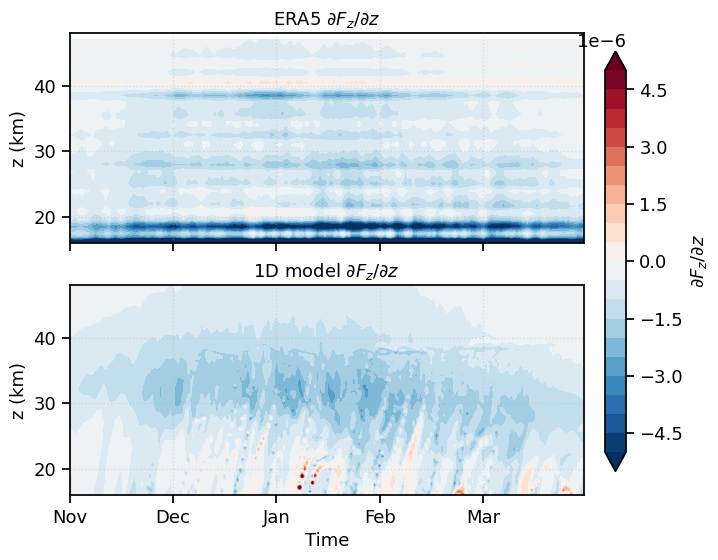

In [67]:
import numpy as np
import matplotlib.pyplot as plt

def vertical_derivative(field_zyt, z_m):
    """
    field_zyt : shape (nz, ny, nt)
    z_m       : shape (nz,), vertical coordinate in meters
    return    : d(field)/dz, same shape as field_zyt
    """
    field_zyt = np.asarray(field_zyt, dtype=float)
    z_m = np.asarray(z_m, dtype=float)
    return np.gradient(field_zyt, z_m, axis=0)

# ============================================================
# 1. vertical coordinates in meters
# ============================================================

z_era_m = height.copy()   # ERA5, shape (97,), already in meters
z_mod_m = h1d.copy()      # model, shape (501,), already in meters

print(z_era_m[:5], z_era_m[-5:])
print(z_mod_m[:5], z_mod_m[-5:])

# ============================================================
# 2. dFz/dz on original grids
# ============================================================

# ERA5 epz_eachyr shape: (97, 42, 992)
epzdiv_era_eachyr = vertical_derivative(epz_eachyr, z_era_m)

# model epz_model_eachyear shape: (501, 42, 320)
epzdiv_model_eachyear = vertical_derivative(epz_model_eachyear, z_mod_m)

print("epzdiv_era_eachyr shape   :", epzdiv_era_eachyr.shape)
print("epzdiv_model_eachyear shape:", epzdiv_model_eachyear.shape)


# ============================================================
# 3. compress ERA5 dFz/dz from 992 -> 320
# ============================================================

epzdiv_era_320 = compress_time_to_target_mean(epzdiv_era_eachyr, target_len=320)

print("epzdiv_era_320 shape:", epzdiv_era_320.shape)
print("epzdiv_model_eachyear shape:", epzdiv_model_eachyear.shape)

# ============================================================
# 4. climatology of dFz/dz on 320-grid
# ============================================================

def clim_on_320(field3d, zmask):
    # field3d shape = (z, year, 320)
    f_clim = np.nanmean(field3d, axis=1)   # (z, 320)
    return f_clim[zmask, t_slice]

epzdiv_era_2d   = clim_on_320(epzdiv_era_320, era_z_mask)
epzdiv_model_2d = clim_on_320(epzdiv_model_eachyear, mod_z_mask)

print(epzdiv_era_2d.shape, epzdiv_model_2d.shape)

print("ERA5 dFz/dz min/max :", np.nanmin(epzdiv_era_2d), np.nanmax(epzdiv_era_2d))
print("Model dFz/dz min/max:", np.nanmin(epzdiv_model_2d), np.nanmax(epzdiv_model_2d))


# ============================================================
# 5. plot ERA5 vs model dFz/dz
# ============================================================

Te, Ze = np.meshgrid(t_plot, z_era_plot)
Tm, Zm = np.meshgrid(t_plot, z_mod_plot)

xticks = [40, 80, 120, 160, 200]
xticklabels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']

# vabs_div = max(np.nanmax(np.abs(epzdiv_era_2d)),
#                np.nanmax(np.abs(epzdiv_model_2d)))

vabs_div = 5e-6

levels_div = np.linspace(-vabs_div, vabs_div, 21)

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
fig.subplots_adjust(right=0.86)

cf0 = axes[0].contourf(
    Te, Ze, epzdiv_era_2d,
    levels=levels_div, extend='both', cmap='RdBu_r'
)
axes[0].set_title(r'ERA5 $\partial F_z / \partial z$')
axes[0].set_ylabel('z (km)')
axes[0].set_ylim(zmin, zmax)
axes[0].grid(True, linestyle=':', alpha=0.3)

cf1 = axes[1].contourf(
    Tm, Zm, epzdiv_model_2d,
    levels=levels_div, extend='both', cmap='RdBu_r'
)
axes[1].set_title(r'1D model $\partial F_z / \partial z$')
axes[1].set_ylabel('z (km)')
axes[1].set_xlabel('Time')
axes[1].set_ylim(zmin, zmax)
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(xticklabels)
axes[1].grid(True, linestyle=':', alpha=0.3)

cax = fig.add_axes([0.89, 0.15, 0.03, 0.7])
cbar = fig.colorbar(cf1, cax=cax)
cbar.set_label(r'$\partial F_z / \partial z$')

plt.show()



epzdiv_era_on_modelz_2d: (160, 200)
epzdiv_model_2d       : (160, 200)


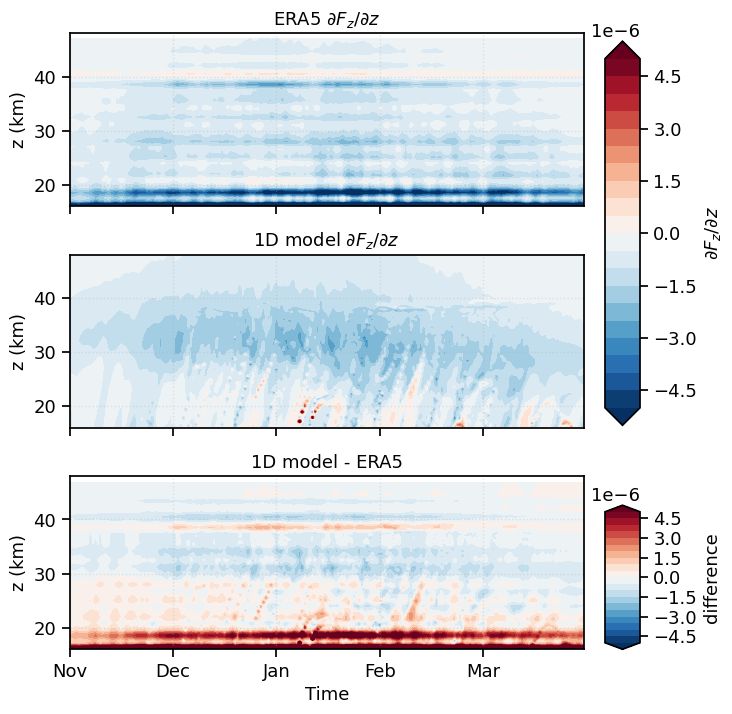

In [68]:
import numpy as np

def interp_vertical_2d(field_zt, z_src, z_tgt):
    """
    field_zt: (nz_src, nt)
    z_src   : (nz_src,)
    z_tgt   : (nz_tgt,)
    return  : (nz_tgt, nt)
    """
    field_zt = np.asarray(field_zt, dtype=float)
    z_src = np.asarray(z_src, dtype=float)
    z_tgt = np.asarray(z_tgt, dtype=float)

    nz_src, nt = field_zt.shape
    out = np.full((len(z_tgt), nt), np.nan, dtype=float)

    for it in range(nt):
        out[:, it] = np.interp(z_tgt, z_src, field_zt[:, it])

    return out

# ERA5 -> model z grid
epzdiv_era_on_modelz_2d = interp_vertical_2d(
    epzdiv_era_2d,
    z_era_plot,
    z_mod_plot
)

print("epzdiv_era_on_modelz_2d:", epzdiv_era_on_modelz_2d.shape)
print("epzdiv_model_2d       :", epzdiv_model_2d.shape)

# ============================================================
# 7. ERA5 / model / difference in one figure
# ============================================================

#  ERA5  model  z 
epzdiv_era_on_modelz_2d = interp_vertical_2d(
    epzdiv_era_2d,
    z_era_plot,
    z_mod_plot
)

epzdiv_diff_2d = epzdiv_model_2d - epzdiv_era_on_modelz_2d

# vabs_div = max(np.nanmax(np.abs(epzdiv_era_2d)),
#                np.nanmax(np.abs(epzdiv_model_2d)))
vabs_div = 5e-6

levels_div = np.linspace(-vabs_div, vabs_div, 21)

vabs_diff = 5e-6 #np.nanmax(np.abs(epzdiv_diff_2d))
levels_diff = np.linspace(-vabs_diff, vabs_diff, 21)

fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)
fig.subplots_adjust(right=0.86, hspace=0.28)

# ERA5 
cf0 = axes[0].contourf(
    Te, Ze, epzdiv_era_2d,
    levels=levels_div, extend='both', cmap='RdBu_r'
)
axes[0].set_title(r'ERA5 $\partial F_z / \partial z$')
axes[0].set_ylabel('z (km)')
axes[0].set_ylim(zmin, zmax)
axes[0].grid(True, linestyle=':', alpha=0.3)

# model 
cf1 = axes[1].contourf(
    Tm, Zm, epzdiv_model_2d,
    levels=levels_div, extend='both', cmap='RdBu_r'
)
axes[1].set_title(r'1D model $\partial F_z / \partial z$')
axes[1].set_ylabel('z (km)')
axes[1].set_ylim(zmin, zmax)
axes[1].grid(True, linestyle=':', alpha=0.3)

#  model z 
cf2 = axes[2].contourf(
    Tm, Zm, epzdiv_diff_2d,
    levels=levels_diff, extend='both', cmap='RdBu_r'
)
axes[2].set_title(r'1D model - ERA5')
axes[2].set_ylabel('z (km)')
axes[2].set_xlabel('Time')
axes[2].set_ylim(zmin, zmax)
axes[2].set_xticks(xticks)
axes[2].set_xticklabels(xticklabels)
axes[2].grid(True, linestyle=':', alpha=0.3)

cax1 = fig.add_axes([0.89, 0.39, 0.05, 0.48])
cbar1 = fig.colorbar(cf1, cax=cax1)
cbar1.set_label(r'$\partial F_z / \partial z$')

cax2 = fig.add_axes([0.89, 0.11, 0.05, 0.18])
cbar2 = fig.colorbar(cf2, cax=cax2)
cbar2.set_label('difference')

plt.show()


ERA5 level near 32 km : 32.0 km, index = 32
Model level near 32 km: 31.956087824351297 km, index = 79


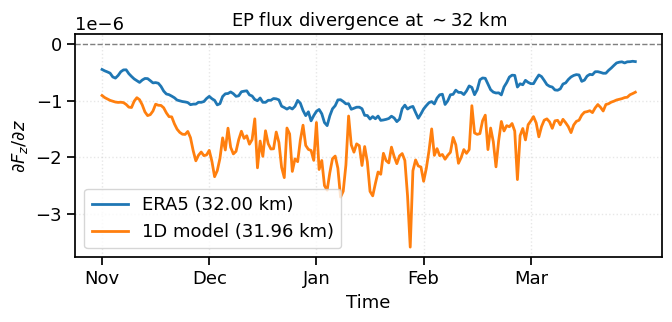

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# divergence line at ~32 km
# ============================================================

z_target = 32.0  # km

#  32 km 
k_era = np.argmin(np.abs(z_era_plot - z_target))
k_mod = np.argmin(np.abs(z_mod_plot - z_target))

print("ERA5 level near 32 km :", z_era_plot[k_era], "km, index =", k_era)
print("Model level near 32 km:", z_mod_plot[k_mod], "km, index =", k_mod)

# 
epzdiv_era_32 = epzdiv_era_2d[k_era, :]
epzdiv_mod_32 = epzdiv_model_2d[k_mod, :]

# 
t_line = t_plot

# ============================================================
# plot
# ============================================================

fig, ax = plt.subplots(figsize=(7, 3.5))

ax.plot(t_line, epzdiv_era_32, label=f'ERA5 ({z_era_plot[k_era]:.2f} km)', linewidth=2)
ax.plot(t_line, epzdiv_mod_32, label=f'1D model ({z_mod_plot[k_mod]:.2f} km)', linewidth=2)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_xticks([40, 80, 120, 160, 200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])

ax.set_xlabel('Time')
ax.set_ylabel(r'$\partial F_z / \partial z$')
ax.set_title(r'EP flux divergence at $\sim$32 km')
ax.grid(True, linestyle=':', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

chosen column = 40 t_plot = 80


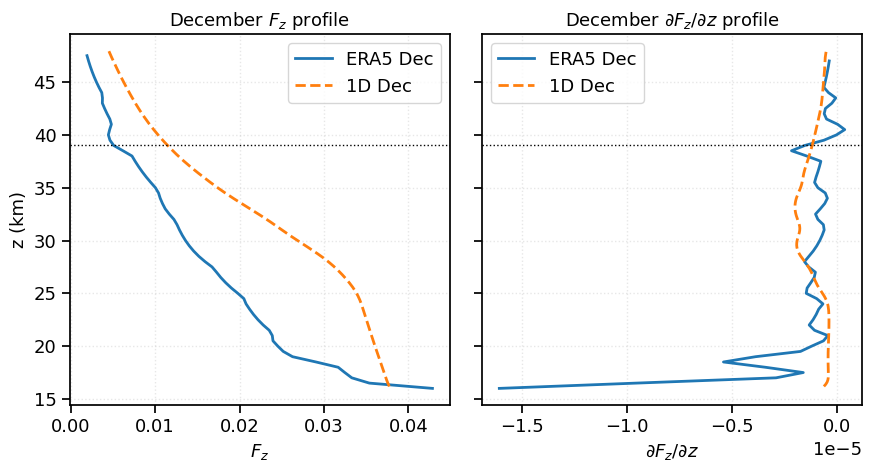

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# choose one December time
# ============================================================
t_dec = 80
c = np.argmin(np.abs(t_plot - t_dec))

# ============================================================
# build z arrays matched to EACH field separately
# ============================================================
z_era_fz_use  = z_era_km[era_z_mask][:epz_era_2d.shape[0]]
z_mod_fz_use  = z_mod_km[mod_z_mask][:epz_model_2d.shape[0]]

z_era_div_use = z_era_km[era_z_mask][:epzdiv_era_2d.shape[0]]
z_mod_div_use = z_mod_km[mod_z_mask][:epzdiv_model_2d.shape[0]]

print("chosen column =", c, "t_plot =", t_plot[c])

# ============================================================
# plot
# ============================================================
zmin_zoom, zmax_zoom = 34.0, 43.0
z_mark = 39.0

fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)

# ---------------- Fz ----------------
ax = axes[0]
ax.plot(epz_era_2d[:, c], z_era_fz_use, label='ERA5 Dec', linewidth=2)
ax.plot(epz_model_2d[:, c],  z_mod_fz_use, '--', label='1D Dec', linewidth=2)

ax.axhline(z_mark, color='k', linestyle=':', linewidth=1)
# ax.set_ylim(zmin_zoom, zmax_zoom)
ax.set_xlabel(r'$F_z$')
ax.set_ylabel('z (km)')
ax.set_title(r'December $F_z$ profile')
ax.grid(True, linestyle=':', alpha=0.3)
ax.legend()

# ---------------- dFz/dz ----------------
ax = axes[1]
ax.plot(epzdiv_era_2d[:, c], z_era_div_use, label='ERA5 Dec', linewidth=2)
ax.plot(epzdiv_model_2d[:, c], z_mod_div_use, '--', label='1D Dec', linewidth=2)

ax.axhline(z_mark, color='k', linestyle=':', linewidth=1)
# ax.set_ylim(zmin_zoom, zmax_zoom)
ax.set_xlabel(r'$\partial F_z / \partial z$')
ax.set_title(r'December $\partial F_z/\partial z$ profile')
ax.grid(True, linestyle=':', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

chosen column = 40 t_plot = 80


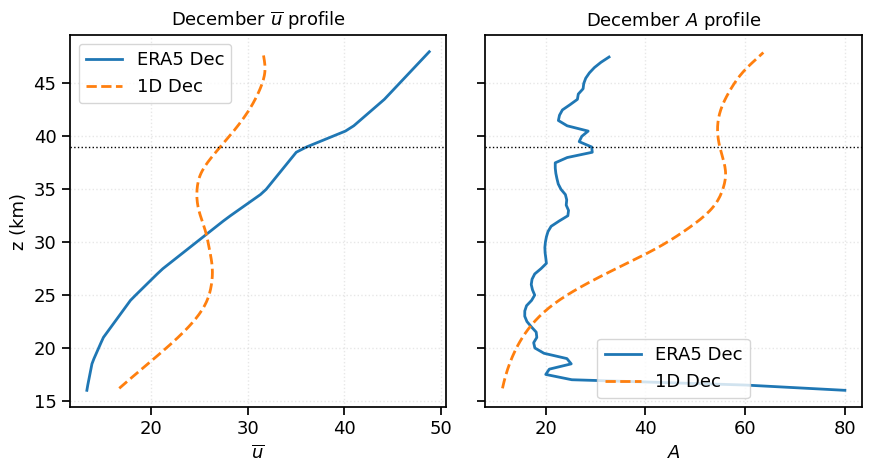

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# choose one December time
# ============================================================
t_dec = 80
c = np.argmin(np.abs(t_plot - t_dec))

# ============================================================
# build z arrays matched to EACH field separately
# ============================================================
z_era_u_use = z_era_km[era_z_mask][:ubar_era_2d.shape[0]]
z_mod_u_use = z_mod_km[mod_z_mask][:ubar_mod_2d.shape[0]]

z_era_a_use = z_era_km[era_z_mask][:fawa_era_2d.shape[0]]
z_mod_a_use = z_mod_km[mod_z_mask][:fawa_mod_2d.shape[0]]

print("chosen column =", c, "t_plot =", t_plot[c])

# ============================================================
# plot
# ============================================================
zmin_zoom, zmax_zoom = 34.0, 43.0
z_mark = 39.0

fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)

# ---------------- ubar ----------------
ax = axes[0]
ax.plot(ubar_era_2d[:, c], z_era_u_use, label='ERA5 Dec', linewidth=2)
ax.plot(ubar_mod_2d[:, c], z_mod_u_use, '--', label='1D Dec', linewidth=2)

ax.axhline(z_mark, color='k', linestyle=':', linewidth=1)
# ax.set_ylim(zmin_zoom, zmax_zoom)
ax.set_xlabel(r'$\overline{u}$')
ax.set_ylabel('z (km)')
ax.set_title(r'December $\overline{u}$ profile')
ax.grid(True, linestyle=':', alpha=0.3)
ax.legend()

# ---------------- fawa ----------------
ax = axes[1]
ax.plot(fawa_era_2d[:, c], z_era_a_use, label='ERA5 Dec', linewidth=2)
ax.plot(fawa_mod_2d[:, c], z_mod_a_use, '--', label='1D Dec', linewidth=2)

ax.axhline(z_mark, color='k', linestyle=':', linewidth=1)
# ax.set_ylim(zmin_zoom, zmax_zoom)
ax.set_xlabel(r'$A$')
ax.set_title(r'December $A$ profile')
ax.grid(True, linestyle=':', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

ERA5 level near 16 km: 16.0 km, index = 32
Oct (5208,) -0.010792246088385582 0.06525304168462753 0.01716241951929011
Nov (5208,) -0.034984003752470016 0.10180024057626724 0.03123543801477583
Dec (5208,) -0.0511600524187088 0.14678703248500824 0.03982980012318605
Jan (5208,) -0.06673043966293335 0.18772710859775543 0.047640242337845876
Feb (5208,) -0.07591653615236282 0.20469309389591217 0.03914577019182879
Mar (5208,) -0.06053667142987251 0.13507845997810364 0.030879103661783355
Apr (5208,) -0.023674920201301575 0.09562534838914871 0.017283015882565374
May (4368,) -0.009772990830242634 0.05843861773610115 0.0070859570934570775


/tmp/ipykernel_3248528/1060336189.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(monthly_data, labels=month_names, showfliers=False)


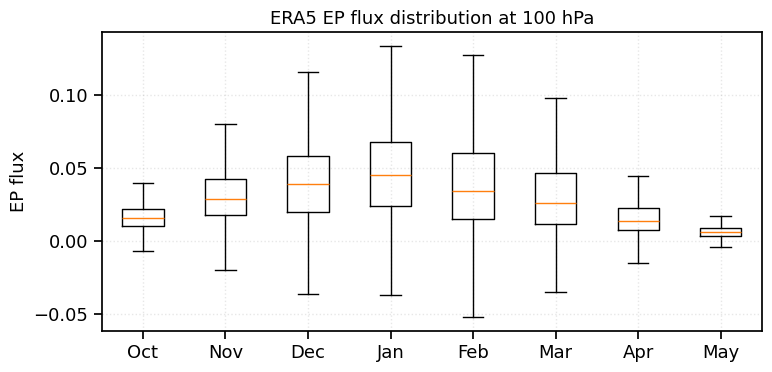

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. choose height level near 16 km
# ============================================================

z_target = 16.0  # km
z_era_km = height / 1000.0
k_era = np.argmin(np.abs(z_era_km - z_target))

print("ERA5 level near 16 km:", z_era_km[k_era], "km, index =", k_era)

# ============================================================
# 2. extract EPz at this level
#    epz_eachyr shape = (97, 42, 992)
# ============================================================

epz_16km = epz_eachyr[k_era, :, :]   # shape (42, 992)

# ============================================================
# 3. split into months
#    992 = 8 months * 124 points/month
# ============================================================

month_names = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']
steps_per_month = 124

monthly_data = []

for i, mon in enumerate(month_names):
    s = i * steps_per_month
    e = (i + 1) * steps_per_month

    # collect all years and all time points in this month
    vals = epz_16km[:, s:e].reshape(-1)

    # remove NaN if any
    vals = vals[np.isfinite(vals)]

    monthly_data.append(vals)
    print(mon, vals.shape, np.nanmin(vals), np.nanmax(vals), np.nanmean(vals))

# ============================================================
# 4. boxplot monthly distribution
# ============================================================

plt.figure(figsize=(8, 4))
plt.boxplot(monthly_data, labels=month_names, showfliers=False)
plt.ylabel('EP flux')
plt.title(f'ERA5 EP flux distribution at 100 hPa')
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

ERA5 level near 16 km: 16.0 km, index = 32
Oct (5208,) -0.010792246088385582 0.06525304168462753 0.01716241951929011
Nov (5208,) -0.034984003752470016 0.10180024057626724 0.03123543801477583
Dec (5208,) -0.0511600524187088 0.14678703248500824 0.03982980012318605
Jan (5208,) -0.06673043966293335 0.18772710859775543 0.047640242337845876
Feb (5208,) -0.07591653615236282 0.20469309389591217 0.03914577019182879
Mar (5208,) -0.06053667142987251 0.13507845997810364 0.030879103661783355
Apr (5208,) -0.023674920201301575 0.09562534838914871 0.017283015882565374
May (4368,) -0.009772990830242634 0.05843861773610115 0.0070859570934570775


/tmp/ipykernel_3248528/3417321360.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(monthly_data, labels=month_names, showfliers=False)


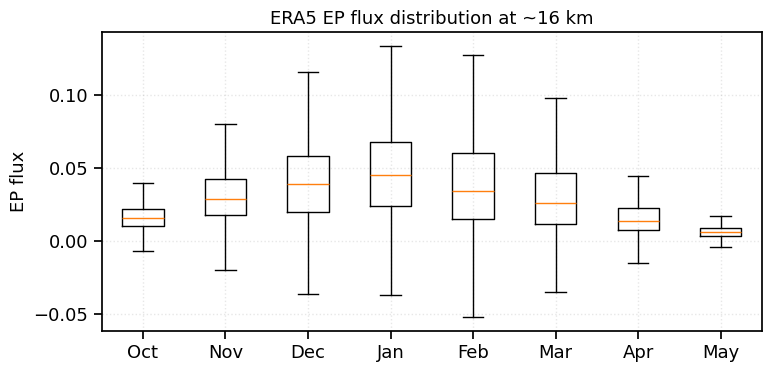

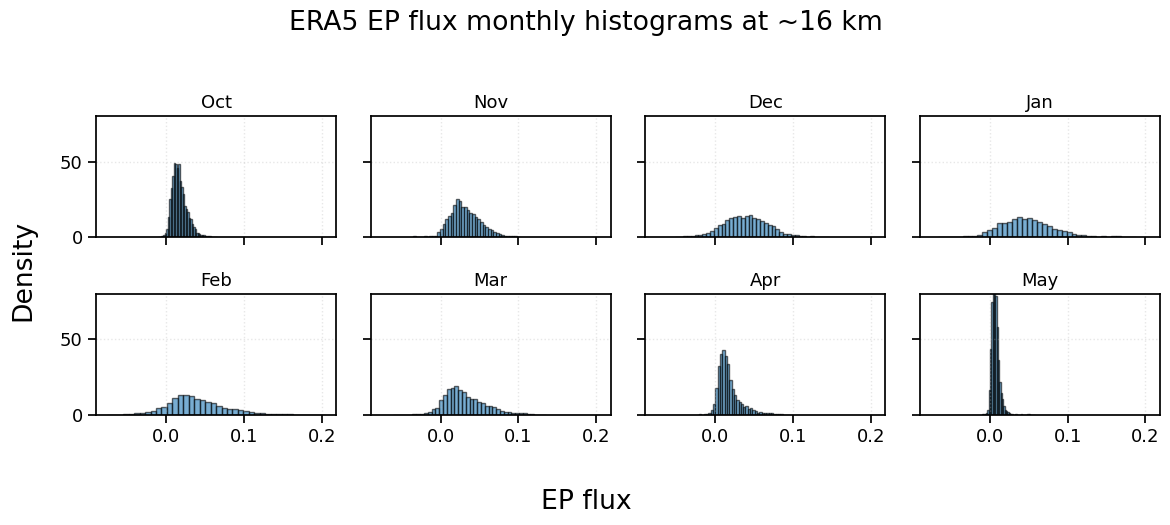

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. choose height level near 16 km
# ============================================================
z_target = 16.0  # km
z_era_km = height / 1000.0
k_era = np.argmin(np.abs(z_era_km - z_target))

print("ERA5 level near 16 km:", z_era_km[k_era], "km, index =", k_era)

# ============================================================
# 2. extract EPz at this level
#    epz_eachyr shape = (97, 42, 992)
# ============================================================
epz_16km = epz_eachyr[k_era, :, :]   # shape (42, 992)

# ============================================================
# 3. split into months
# ============================================================
month_names = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']
steps_per_month = 124

monthly_data = []

for i, mon in enumerate(month_names):
    s = i * steps_per_month
    e = (i + 1) * steps_per_month

    vals = epz_16km[:, s:e].reshape(-1)
    vals = vals[np.isfinite(vals)]

    monthly_data.append(vals)
    print(mon, vals.shape, np.nanmin(vals), np.nanmax(vals), np.nanmean(vals))

# ============================================================
# 4. boxplot monthly distribution
# ============================================================
plt.figure(figsize=(8, 4))
plt.boxplot(monthly_data, labels=month_names, showfliers=False)
plt.ylabel('EP flux')
plt.title('ERA5 EP flux distribution at ~16 km')
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 5. monthly histograms
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(12, 5), sharex=True, sharey=True)
axes = axes.ravel()

for ax, mon, vals in zip(axes, month_names, monthly_data):
    ax.hist(vals, bins=40, density=True, alpha=0.6, edgecolor='k')
    ax.set_title(mon)
    ax.grid(True, linestyle=':', alpha=0.3)

plt.ylim(0,80)
fig.suptitle('ERA5 EP flux monthly histograms at ~16 km', y=1.02)
fig.supxlabel('EP flux')
fig.supylabel('Density')
plt.tight_layout()
plt.show()

In [74]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 0. read forcing
# ============================================================
file_forcing = "/nas/winds-home/smliu01/0.1dmodel_2025/randforc/climatechange/forcing/ctl/forcing_total_1000_ctl.nc"

ds = xr.open_dataset(file_forcing)
forcing_2d = ds["forcing"].values   # shape = (1000, 992)

print("forcing_2d shape =", forcing_2d.shape)
print("mean =", np.nanmean(forcing_2d))
print("std  =", np.nanstd(forcing_2d))
print("min  =", np.nanmin(forcing_2d))
print("max  =", np.nanmax(forcing_2d))

forcing_2d shape = (1000, 992)
mean = 0.028713733
std  = 0.027380807
min  = -0.07638001
max  = 0.20476596


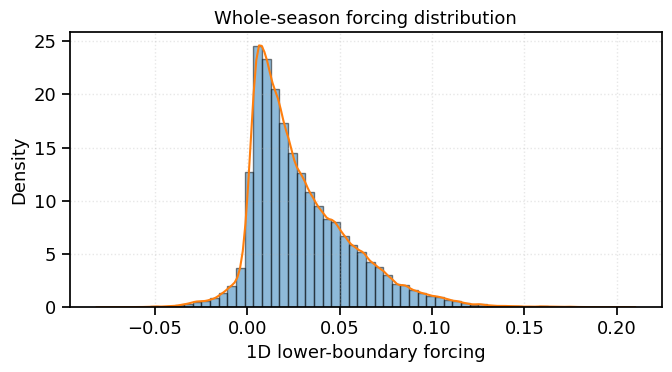

In [75]:
# ============================================================
# 1. whole-season distribution
# ============================================================
vals_all = forcing_2d.reshape(-1)
vals_all = vals_all[np.isfinite(vals_all)]

plt.figure(figsize=(7, 4))
plt.hist(vals_all, bins=60, density=True, alpha=0.5, edgecolor='k')
sns.kdeplot(vals_all, bw_adjust=1.0)
plt.xlabel("1D lower-boundary forcing")
plt.ylabel("Density")
plt.title("Whole-season forcing distribution")
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

In [76]:
# ============================================================
# 2. split into months
# ============================================================
month_names = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']
steps_per_month = 124

monthly_data = []

for i, mon in enumerate(month_names):
    s = i * steps_per_month
    e = (i + 1) * steps_per_month

    vals = forcing_2d[:, s:e].reshape(-1)
    vals = vals[np.isfinite(vals)]

    monthly_data.append(vals)

    print(f"{mon}:")
    print("  N    =", vals.size)
    print("  mean =", np.nanmean(vals))
    print("  std  =", np.nanstd(vals))
    print("  min  =", np.nanmin(vals))
    print("  max  =", np.nanmax(vals))

Oct:
  N    = 124000
  mean = 0.017148705
  std  = 0.021484522
  min  = -0.04320112
  max  = 0.15995231
Nov:
  N    = 124000
  mean = 0.030595213
  std  = 0.026267149
  min  = -0.06643303
  max  = 0.17467192
Dec:
  N    = 124000
  mean = 0.039124995
  std  = 0.026596004
  min  = -0.028117929
  max  = 0.17222257
Jan:
  N    = 124000
  mean = 0.04853726
  std  = 0.0294899
  min  = -0.034637496
  max  = 0.20385127
Feb:
  N    = 124000
  mean = 0.038369376
  std  = 0.02666298
  min  = -0.050848234
  max  = 0.20476596
Mar:
  N    = 124000
  mean = 0.029424004
  std  = 0.02329159
  min  = -0.039406553
  max  = 0.1664935
Apr:
  N    = 124000
  mean = 0.017336247
  std  = 0.020487841
  min  = -0.050177485
  max  = 0.13652183
May:
  N    = 124000
  mean = 0.009174118
  std  = 0.018770209
  min  = -0.07638001
  max  = 0.111480266


/tmp/ipykernel_3248528/3618329851.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(monthly_data, labels=month_names, showfliers=False)


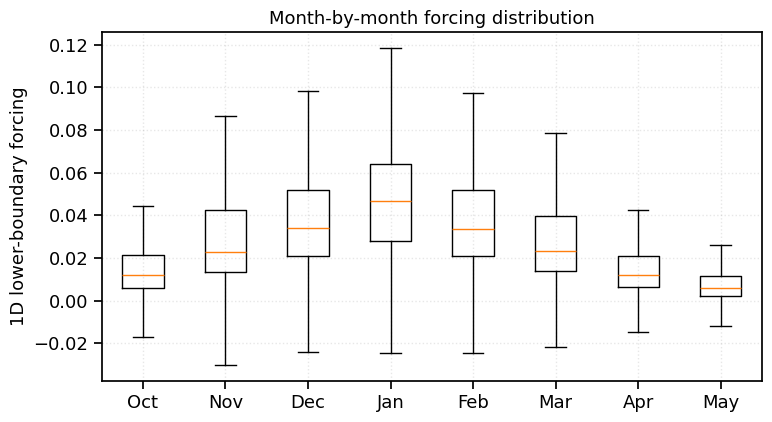

In [77]:
# ============================================================
# 3. monthly boxplot
# ============================================================
plt.figure(figsize=(8, 4.5))
plt.boxplot(monthly_data, labels=month_names, showfliers=False)
plt.ylabel("1D lower-boundary forcing")
plt.title("Month-by-month forcing distribution")
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

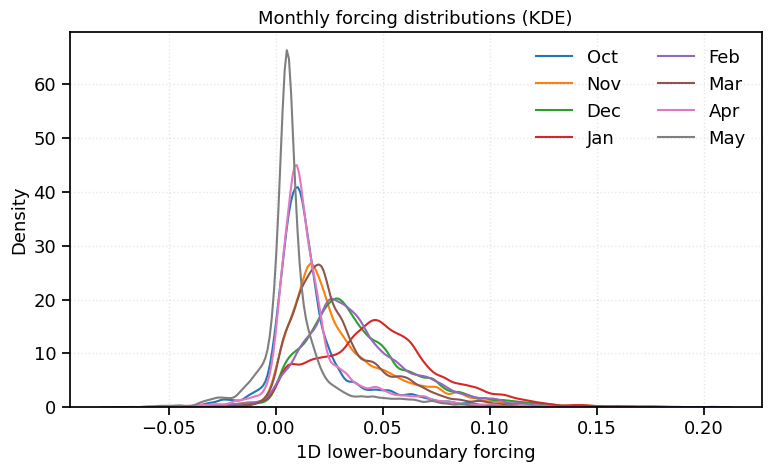

In [78]:
# ============================================================
# 5. monthly KDE
# ============================================================
plt.figure(figsize=(8, 5))

for mon, vals in zip(month_names, monthly_data):
    sns.kdeplot(vals, label=mon, bw_adjust=1.0)

plt.xlabel("1D lower-boundary forcing")
plt.ylabel("Density")
plt.title("Monthly forcing distributions (KDE)")
plt.legend(ncol=2, frameon=False)
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

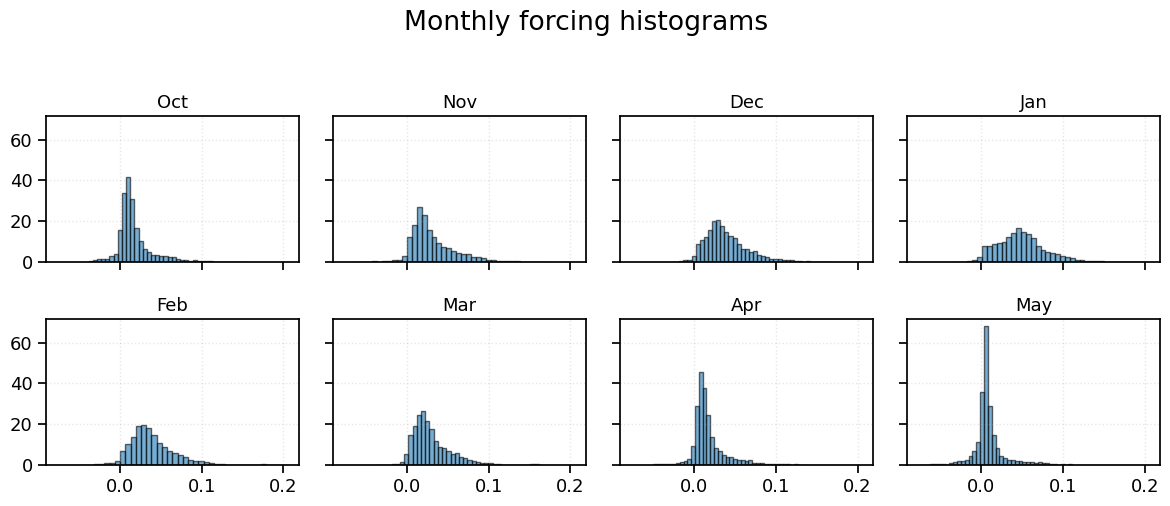

In [79]:
# ============================================================
# 8. separate monthly histograms
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(12, 5), sharex=True, sharey=True)
axes = axes.ravel()

for ax, mon, vals in zip(axes, month_names, monthly_data):
    ax.hist(vals, bins=40, density=True, alpha=0.6, edgecolor='k')
    ax.set_title(mon)
    ax.grid(True, linestyle=':', alpha=0.3)

fig.suptitle("Monthly forcing histograms", y=1.02)
plt.tight_layout()
plt.show()